<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Spotify_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Dataset

# About this dataset

Dataset contains information about 50 Spotify tracks, each identified by a unique track_id and track_name. The data provides various audio features and metadata for each song, including the artist, album, and release_date. The dataset is relatively clean, with no missing values or duplicate entries, as confirmed by df.isnull().sum() and df.duplicated().sum().

From the univariate analysis, we observed the distribution of numerical features like duration_ms (track length), popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence (musical positiveness), and tempo. For instance, popularity varies widely, with some songs having very low popularity (0) and others reaching high scores (96). Features like danceability, energy, and acousticness show a diverse range, indicating a mix of musical styles within the dataset. The duration_ms suggests typical song lengths, averaging around 212,726 ms (approx 3.5 minutes).

Categorical data revealed that Artist 12 has the most tracks (7), followed by Artist 8 and Artist 11 (both with 5 tracks). Similarly, Album 4, Album 18, and Album 15 are the most represented albums. The release_date column shows a daily increment, suggesting a structured collection over a short period (January to February 2010).

The bivariate analysis and correlation matrix provided further insights. For example, the heatmap indicates strong correlations between certain features, such as energy and loudness (positively correlated), and energy and acousticness (negatively correlated), which is expected as more energetic songs often have higher volume and less acoustic sound. The pair plots also visually confirm these relationships. Understanding these relationships can be crucial for tasks like genre classification or predicting song popularity based on its audio characteristics. The dataset offers a rich foundation for exploring how various audio features contribute to a song's overall profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d abdullahmeo/spotify-analysis-and-visualization

# Unziping the downloaded file
!unzip spotify-analysis-and-visualization.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abdullahmeo/spotify-analysis-and-visualization
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/2.31k [00:00<?, ?B/s]
100% 2.31k/2.31k [00:00<00:00, 7.31MB/s]
Archive:  spotify-analysis-and-visualization.zip
  inflating: spotify_analysis_dataset.csv  


In [3]:
df = pd.read_csv('spotify_analysis_dataset.csv')
df.head(11)

,track_id,track_name,artist,album,release_date,duration_ms,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,TRK1000,Song 0,Artist 7,Album 3,2010-01-01,240151,70,0.037,0.349,-2.87,0.522,0.616,0.931,0.947,0.353,110.14
1,TRK1001,Song 1,Artist 4,Album 5,2010-01-02,253767,58,0.610,0.726,-22.87,0.770,0.635,0.858,0.986,0.584,75.90
2,TRK1002,Song 2,Artist 13,Album 19,2010-01-03,244375,85,0.503,0.897,-1.33,0.216,0.045,0.429,0.753,0.078,154.02
3,TRK1003,Song 3,Artist 11,Album 7,2010-01-04,299262,27,0.051,0.887,-1.46,0.623,0.375,0.751,0.376,0.974,132.84
4,TRK1004,Song 4,Artist 8,Album 9,2010-01-05,256330,65,0.279,0.780,-5.88,0.085,0.626,0.755,0.084,0.986,168.12
5,TRK1005,Song 5,Artist 13,Album 7,2010-01-06,159504,41,0.908,0.642,-28.22,0.052,0.503,0.103,0.777,0.698,132.82
6,TRK1006,Song 6,Artist 5,Album 18,2010-01-07,284231,44,0.240,0.084,-24.60,0.531,0.856,0.903,0.558,0.536,179.31
7,TRK1007,Song 7,Artist 7,Album 4,2010-01-08,133986,61,0.145,0.162,-5.95,0.541,0.659,0.505,0.424,0.310,137.27
8,TRK1008,Song 8,Artist 10,Album 14,2010-01-09,181858,56,0.489,0.899,-27.32,0.637,0.163,0.826,0.906,0.814,138.53
9,TRK1009,Song 9,Artist 3,Album 18,2010-01-10,249312,5,0.986,0.606,-33.22,0.726,0.071,0.320,0.111,0.685,182.73


In [4]:
df.tail(11)

,track_id,track_name,artist,album,release_date,duration_ms,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
39,TRK1039,Song 39,Artist 10,Album 16,2010-02-09,242409,95,0.258,0.195,-16.87,0.046,0.735,0.084,0.584,0.769,148.68
40,TRK1040,Song 40,Artist 12,Album 13,2010-02-10,143419,87,0.660,0.722,-38.56,0.041,0.803,0.701,0.901,0.945,93.62
41,TRK1041,Song 41,Artist 12,Album 18,2010-02-11,170015,51,0.817,0.281,-21.38,0.855,0.282,0.073,0.045,0.850,70.62
42,TRK1042,Song 42,Artist 14,Album 15,2010-02-12,242096,61,0.555,0.024,-18.29,0.704,0.177,0.822,0.281,0.247,78.04
43,TRK1043,Song 43,Artist 14,Album 13,2010-02-13,227059,57,0.530,0.645,-28.54,0.474,0.751,0.706,0.950,0.451,77.93
44,TRK1044,Song 44,Artist 14,Album 9,2010-02-14,230687,51,0.242,0.177,-16.37,0.098,0.807,0.081,0.890,0.129,81.27
45,TRK1045,Song 45,Artist 3,Album 15,2010-02-15,207939,11,0.093,0.940,-38.78,0.492,0.991,0.085,0.456,0.954,79.44
46,TRK1046,Song 46,Artist 12,Album 13,2010-02-16,269213,38,0.897,0.954,-38.51,0.473,0.413,0.987,0.620,0.606,149.72
47,TRK1047,Song 47,Artist 7,Album 1,2010-02-17,225878,1,0.900,0.915,-7.10,0.173,0.372,0.374,0.277,0.229,85.46
48,TRK1048,Song 48,Artist 4,Album 7,2010-02-18,284899,2,0.633,0.370,-25.59,0.434,0.776,0.371,0.188,0.672,108.39


In [5]:
df.shape

(50, 16)

In [6]:
df.columns

Index(['track_id', 'track_name', 'artist', 'album', 'release_date',
       'duration_ms', 'popularity', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo'],
      dtype='object')

In [7]:
df.dtypes

,0
track_id,object
track_name,object
artist,object
album,object
release_date,object
duration_ms,int64
popularity,int64
danceability,float64
energy,float64
loudness,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50 non-null     object 
 1   track_name        50 non-null     object 
 2   artist            50 non-null     object 
 3   album             50 non-null     object 
 4   release_date      50 non-null     object 
 5   duration_ms       50 non-null     int64  
 6   popularity        50 non-null     int64  
 7   danceability      50 non-null     float64
 8   energy            50 non-null     float64
 9   loudness          50 non-null     float64
 10  speechiness       50 non-null     float64
 11  acousticness      50 non-null     float64
 12  instrumentalness  50 non-null     float64
 13  liveness          50 non-null     float64
 14  valence           50 non-null     float64
 15  tempo             50 non-null     float64
dtypes: float64(9), int64(2), object(5)
memory usag

In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,50,50,TRK1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,50,50,Song 0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist,50,14,Artist 12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album,50,18,Album 4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,50,50,2010-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,50.0,NaN,NaN,NaN,212726.1,47725.482111,128392.0,170575.25,227562.5,246702.25,299262.0
popularity,50.0,NaN,NaN,NaN,50.32,27.528419,0.0,27.5,55.5,69.75,96.0
danceability,50.0,NaN,NaN,NaN,0.4742,0.29023,0.017,0.2385,0.5075,0.6765,0.986
energy,50.0,NaN,NaN,NaN,0.506,0.299962,0.005,0.23875,0.5725,0.725,0.973
loudness,50.0,NaN,NaN,NaN,-17.696,11.567047,-38.78,-26.265,-17.035,-7.6075,-0.4


In [11]:
df.isnull().sum()

,0
track_id,0
track_name,0
artist,0
album,0
release_date,0
duration_ms,0
popularity,0
danceability,0
energy,0
loudness,0


In [12]:
df.duplicated().sum()

np.int64(0)

### Top Artists by Average Popularity

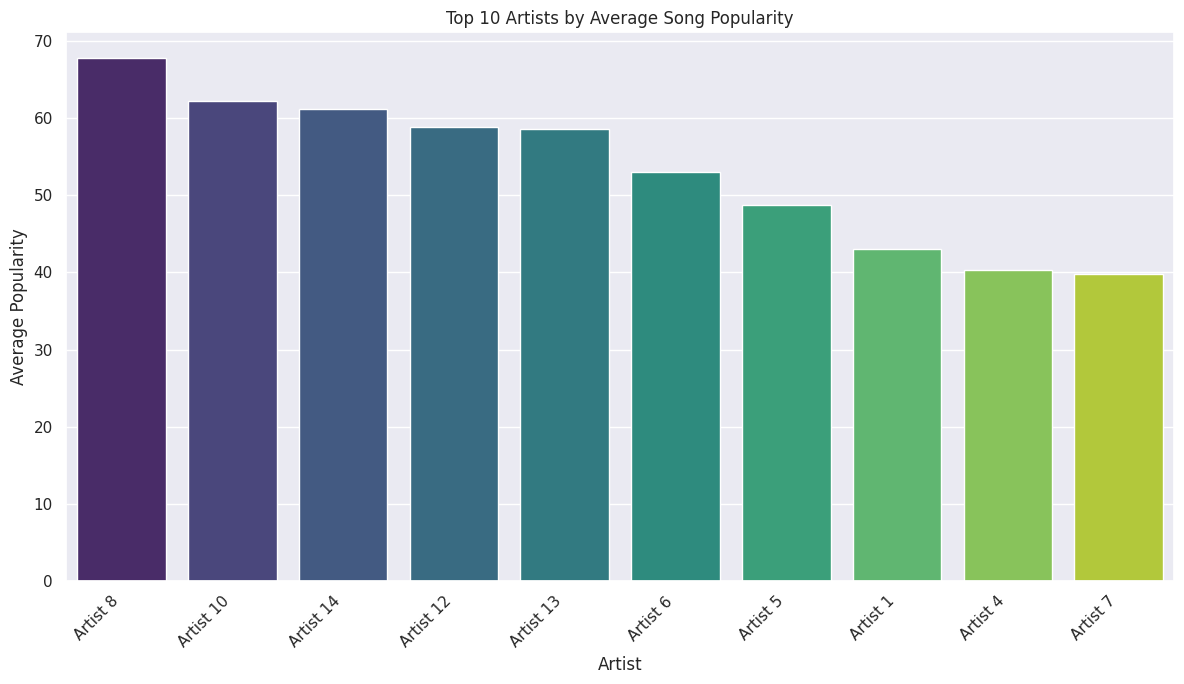

In [17]:
artist_popularity = df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=artist_popularity.index, y=artist_popularity.values, palette='viridis')
plt.title('Top 10 Artists by Average Song Popularity')
plt.xlabel('Artist')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Relationship Between Popularity and Danceability

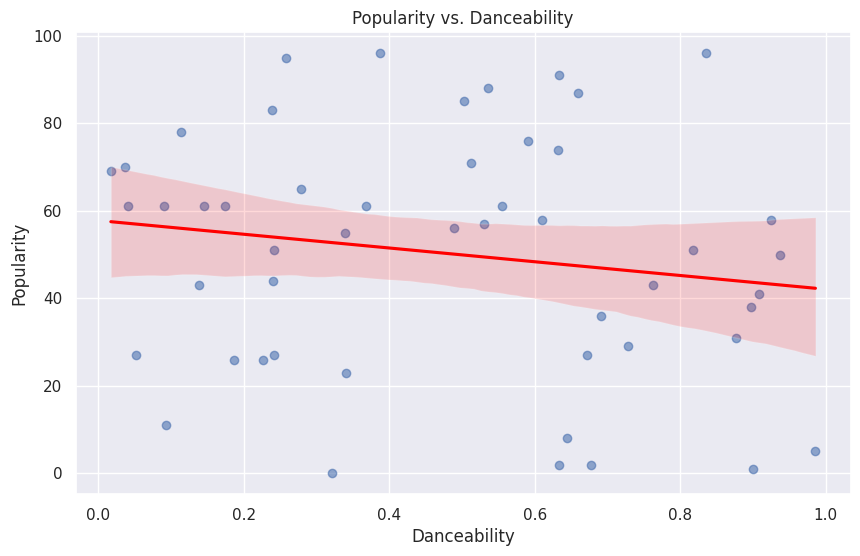

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='danceability', y='popularity', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Popularity vs. Danceability')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.show()

# Univariate Analysis

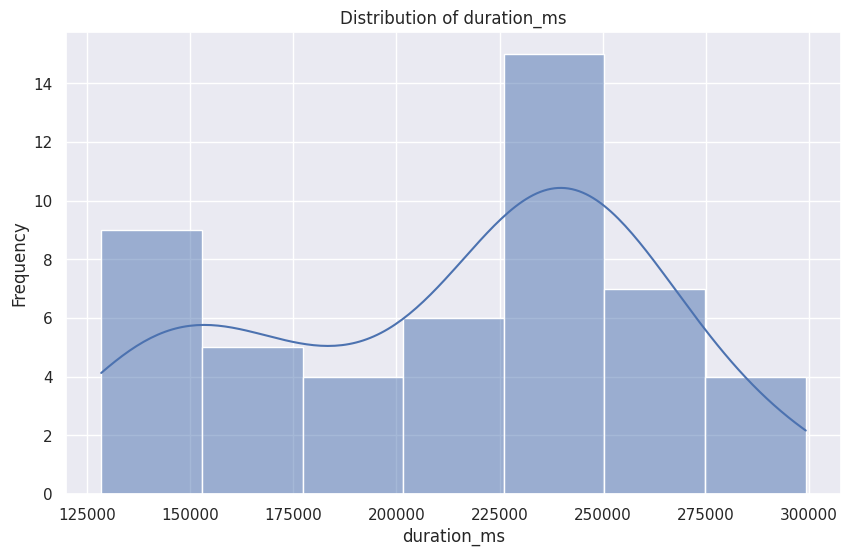

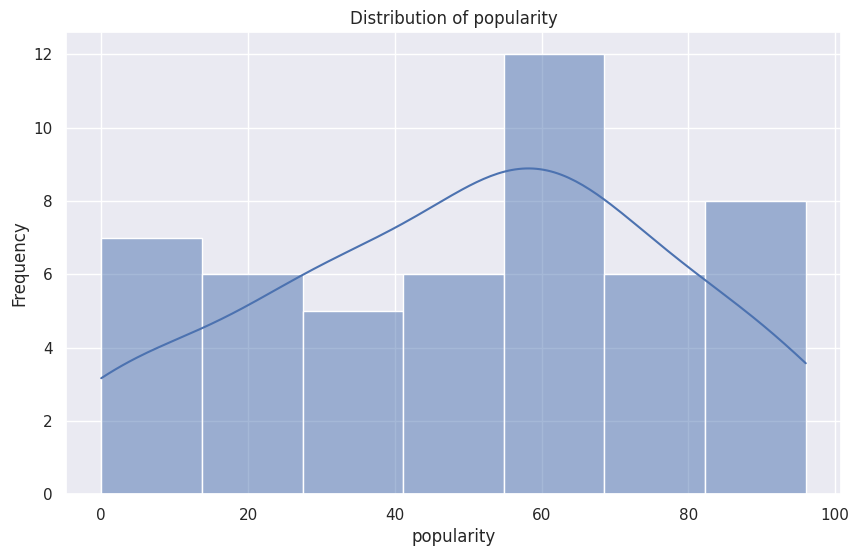

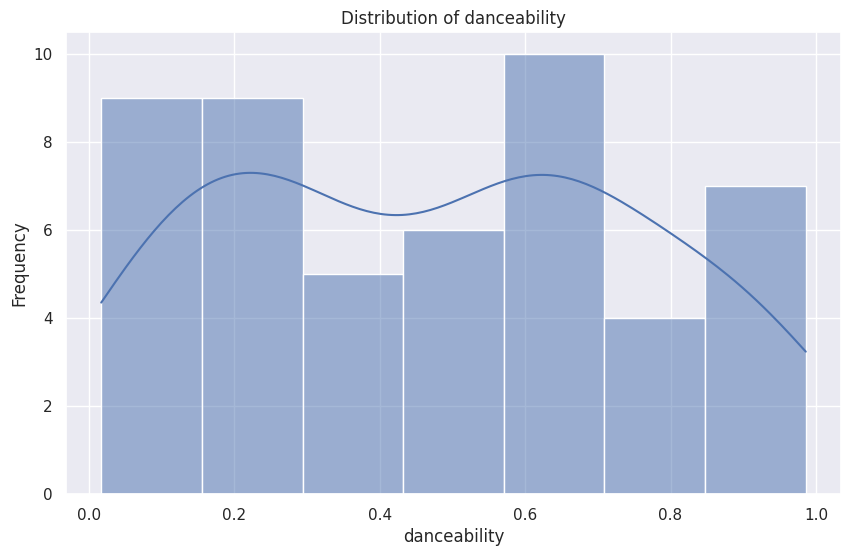

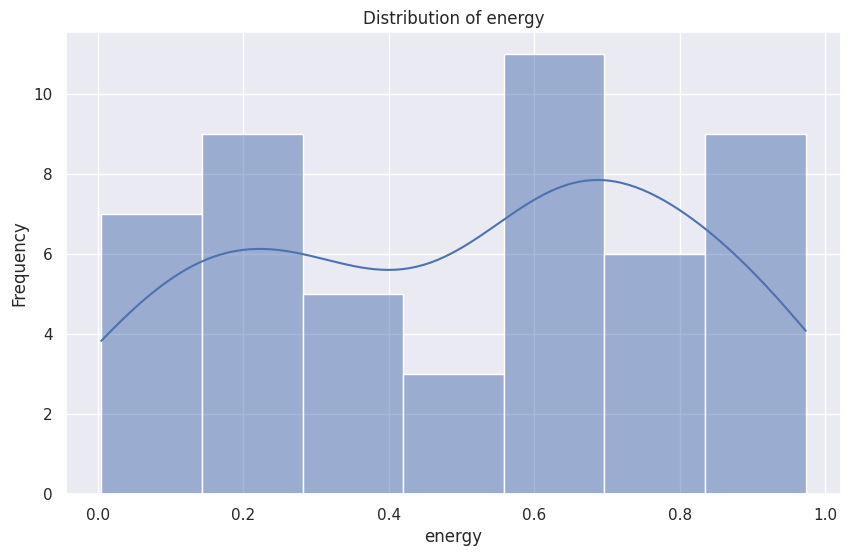

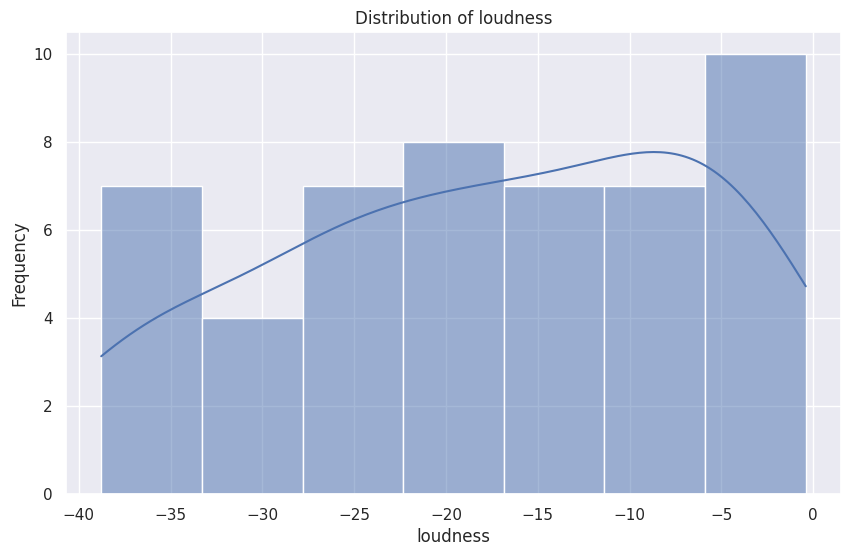

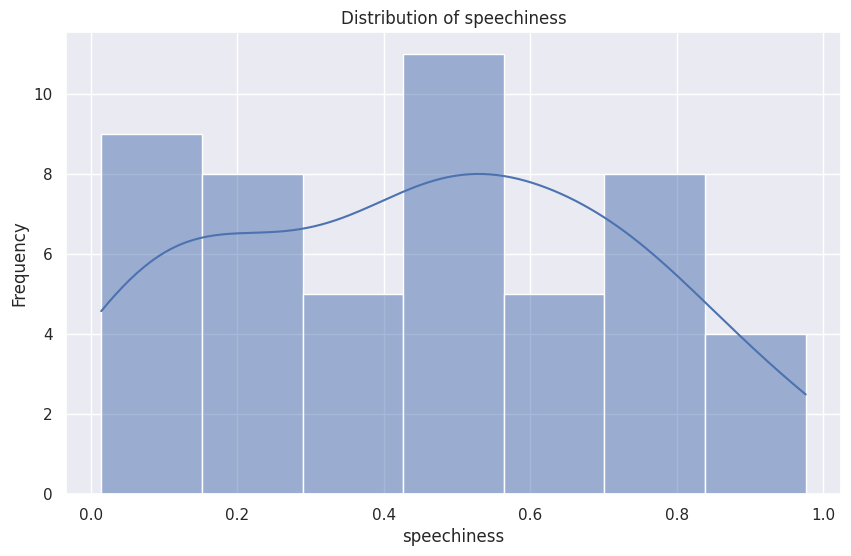

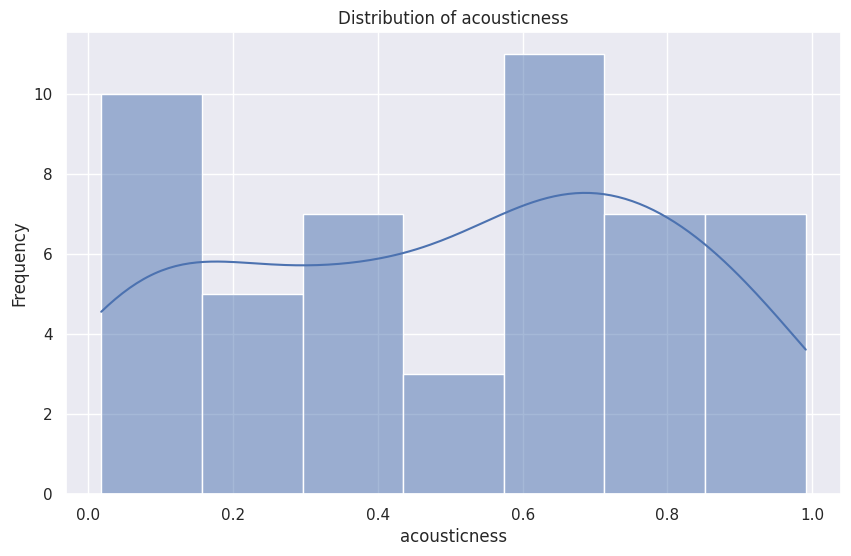

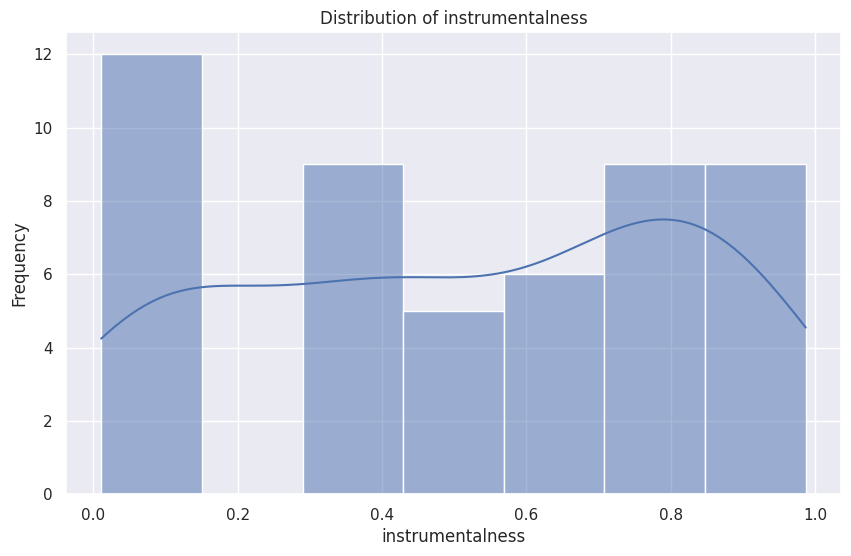

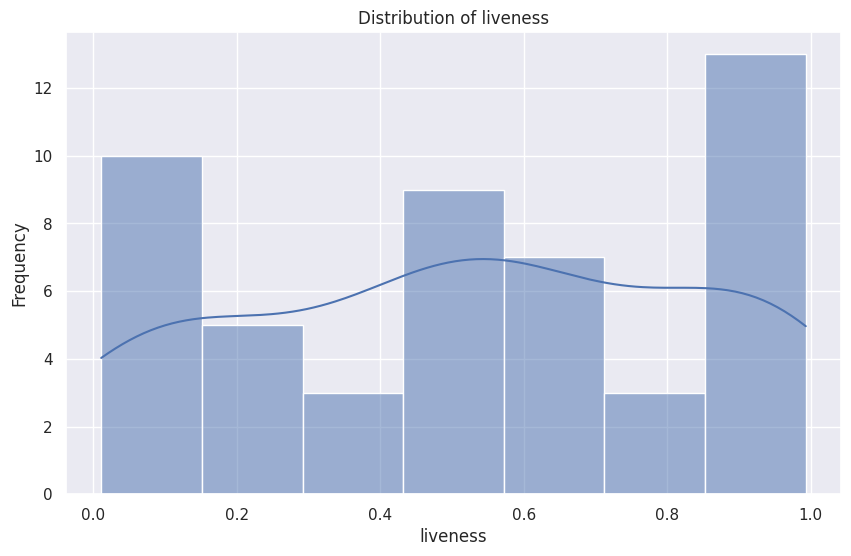

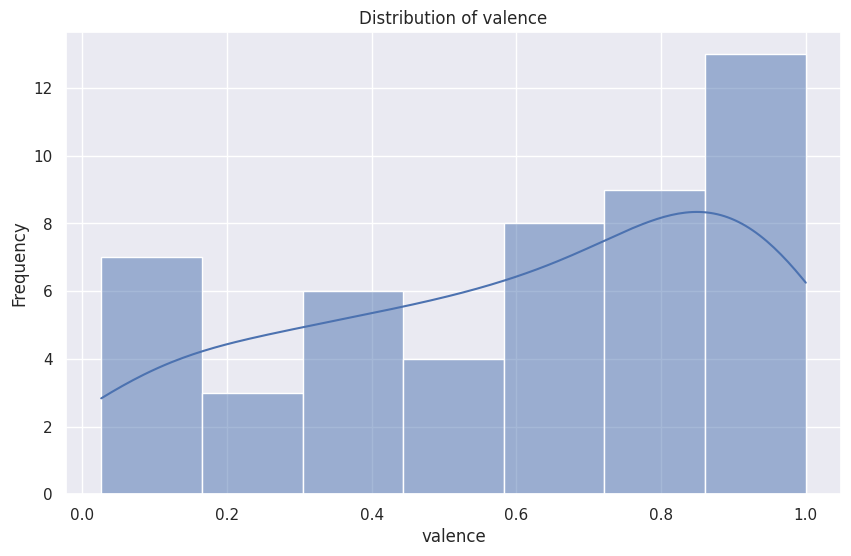

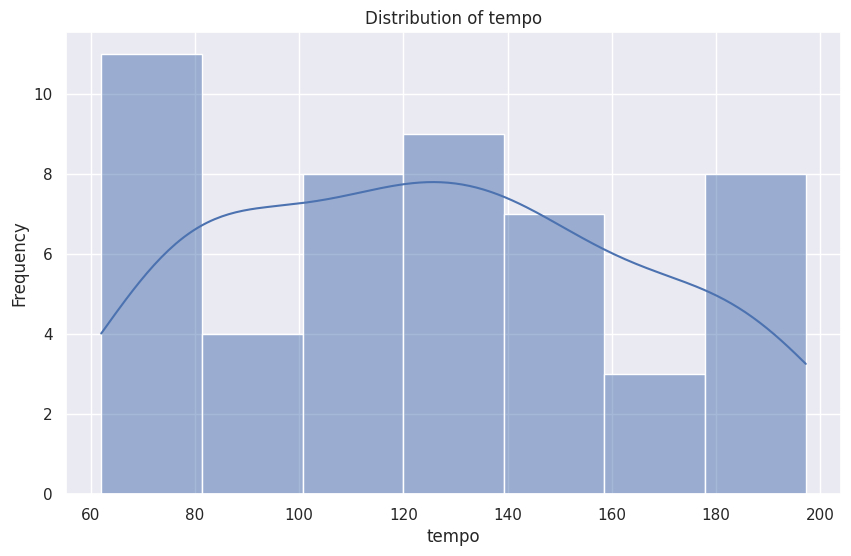

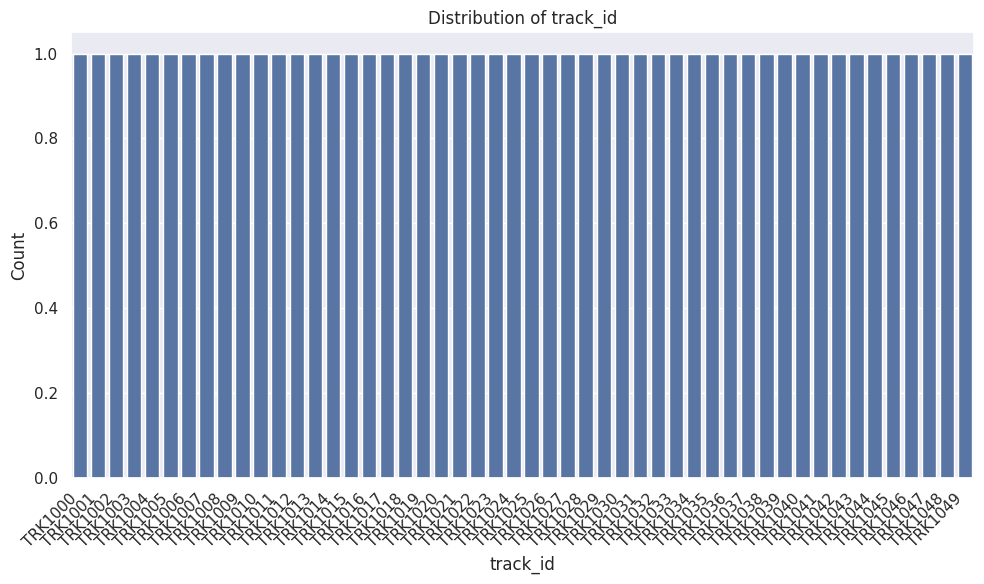

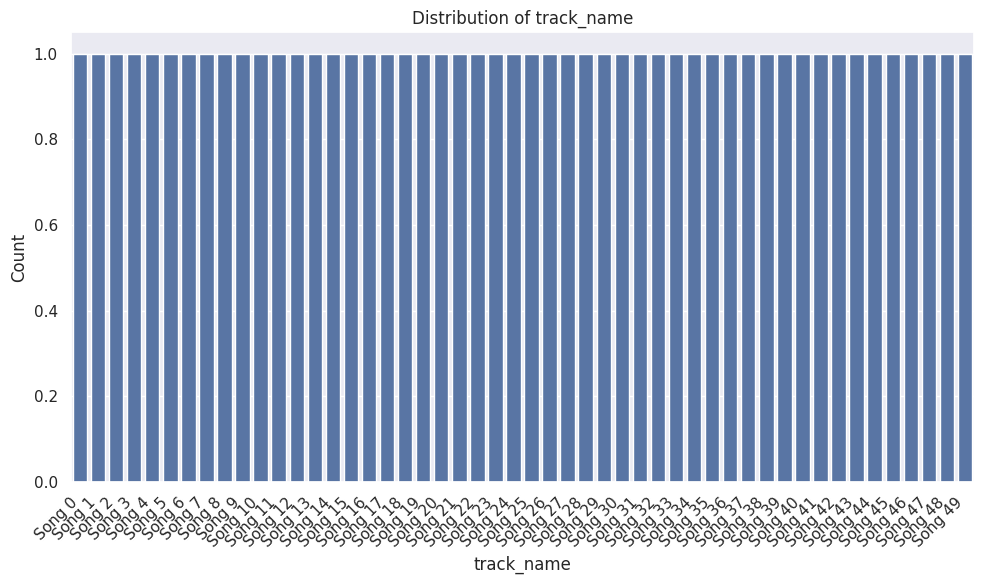

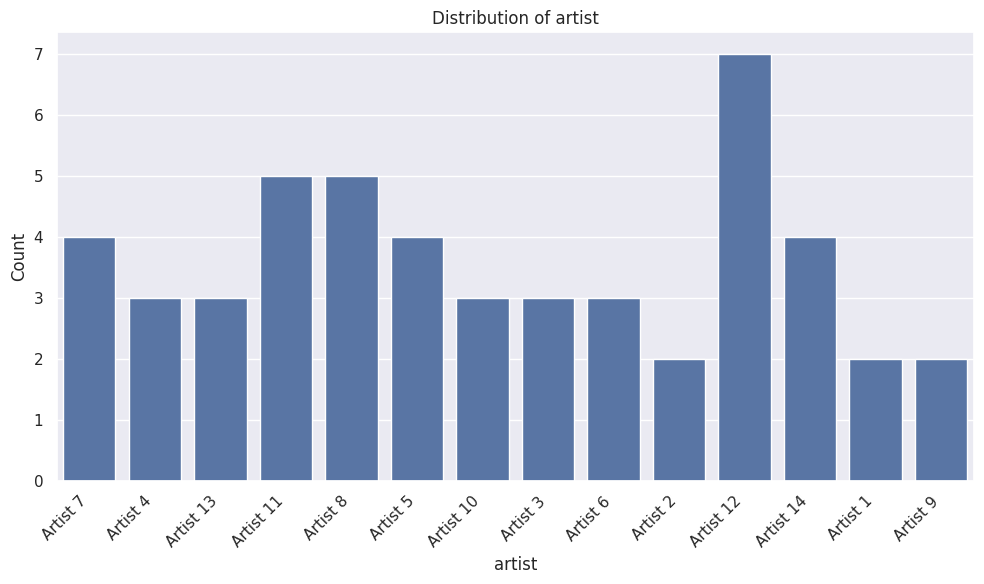

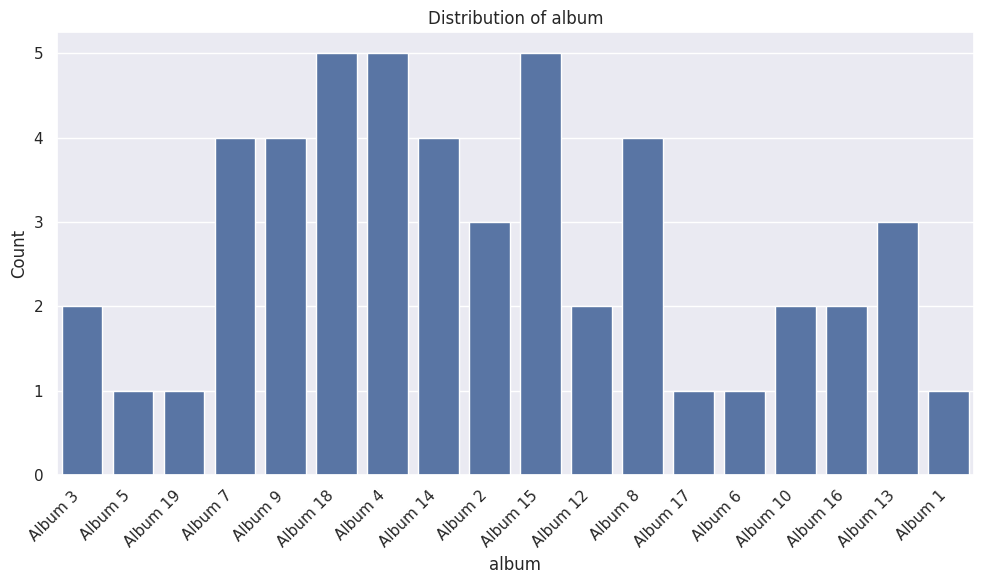

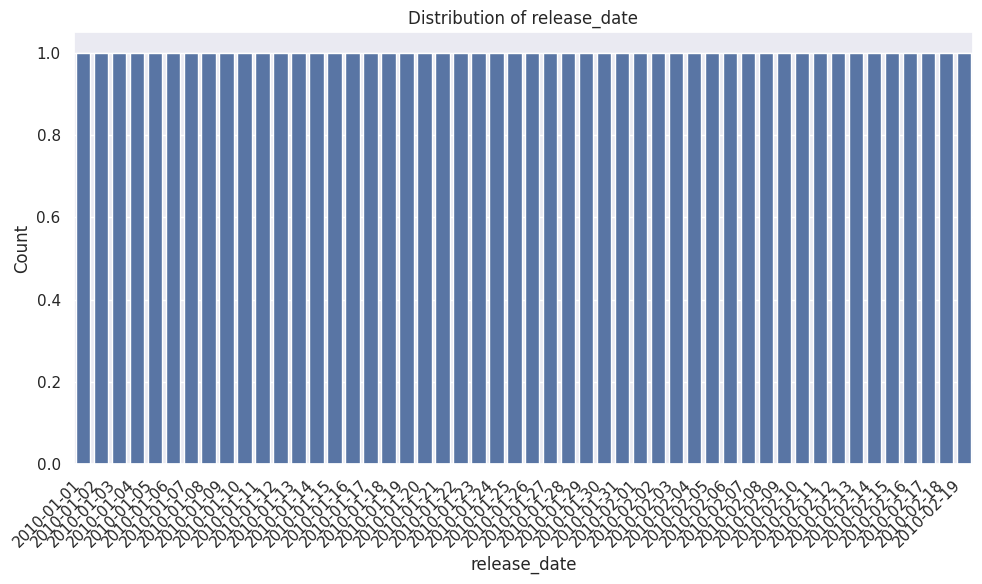

Value counts for track_id:
track_id
TRK1000    1
TRK1001    1
TRK1002    1
TRK1003    1
TRK1004    1
TRK1005    1
TRK1006    1
TRK1007    1
TRK1008    1
TRK1009    1
TRK1010    1
TRK1011    1
TRK1012    1
TRK1013    1
TRK1014    1
TRK1015    1
TRK1016    1
TRK1017    1
TRK1018    1
TRK1019    1
TRK1020    1
TRK1021    1
TRK1022    1
TRK1023    1
TRK1024    1
TRK1025    1
TRK1026    1
TRK1027    1
TRK1028    1
TRK1029    1
TRK1030    1
TRK1031    1
TRK1032    1
TRK1033    1
TRK1034    1
TRK1035    1
TRK1036    1
TRK1037    1
TRK1038    1
TRK1039    1
TRK1040    1
TRK1041    1
TRK1042    1
TRK1043    1
TRK1044    1
TRK1045    1
TRK1046    1
TRK1047    1
TRK1048    1
TRK1049    1
Name: count, dtype: int64

Value counts for track_name:
track_name
Song 0     1
Song 1     1
Song 2     1
Song 3     1
Song 4     1
Song 5     1
Song 6     1
Song 7     1
Song 8     1
Song 9     1
Song 10    1
Song 11    1
Song 12    1
Song 13    1
Song 14    1
Song 15    1
Song 16    1
Song 17    1
Song 18    1


In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

 # Bivariate Analysis

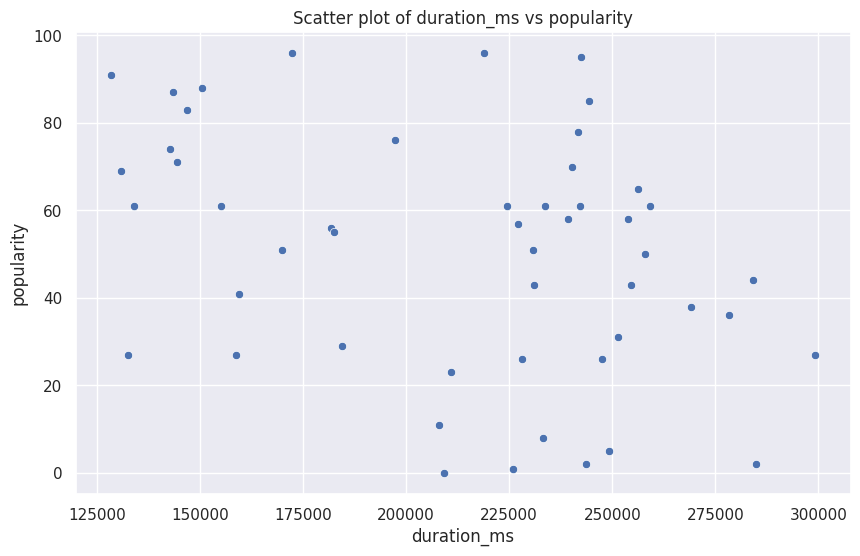

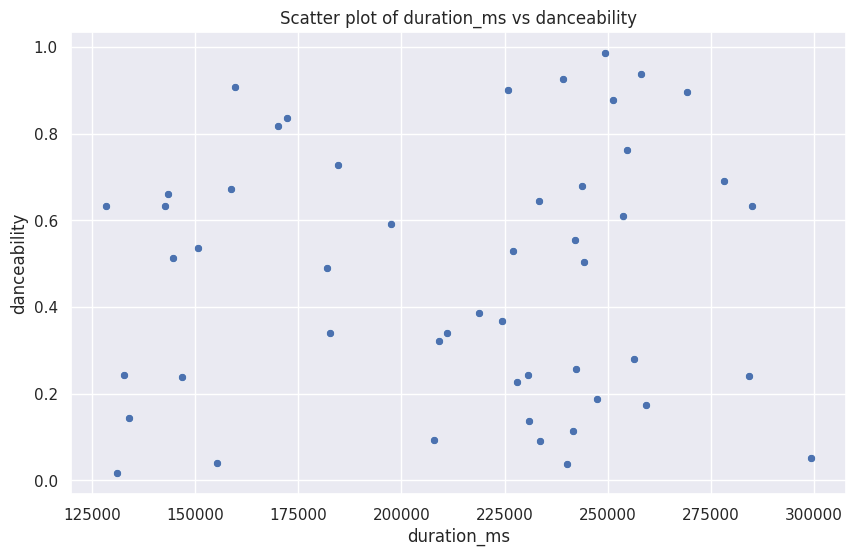

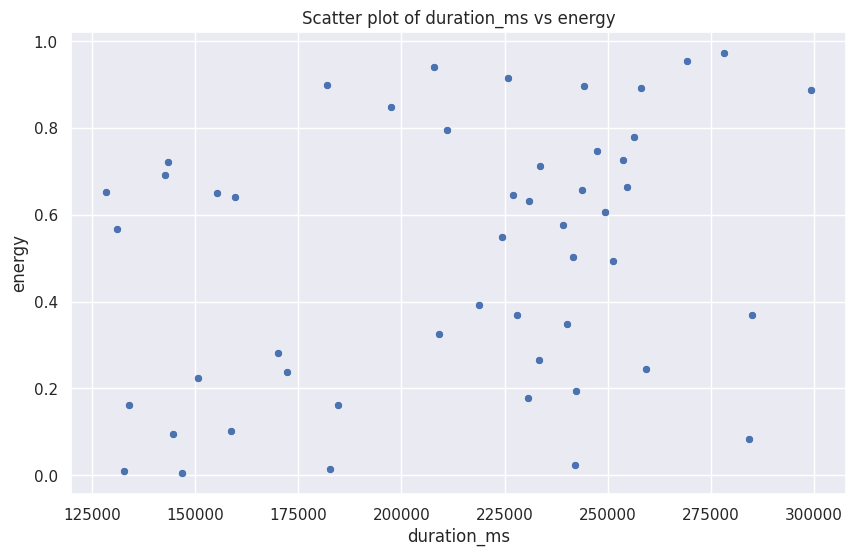

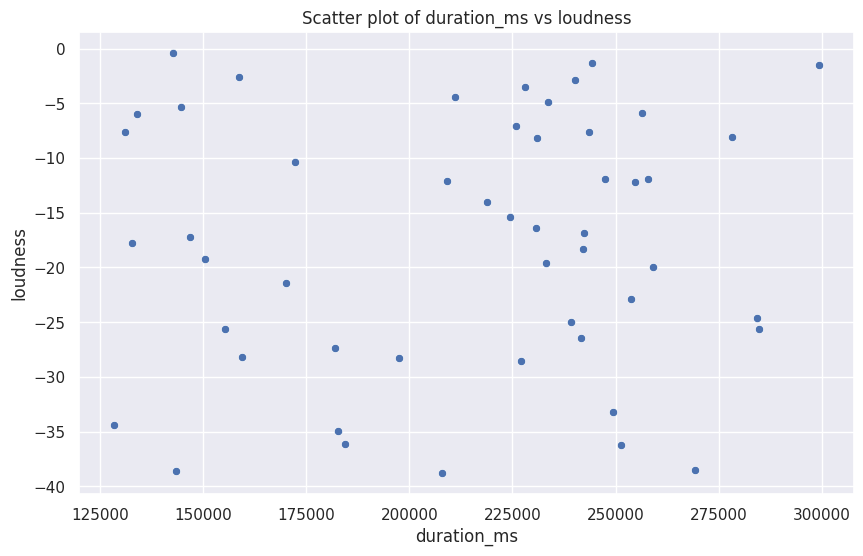

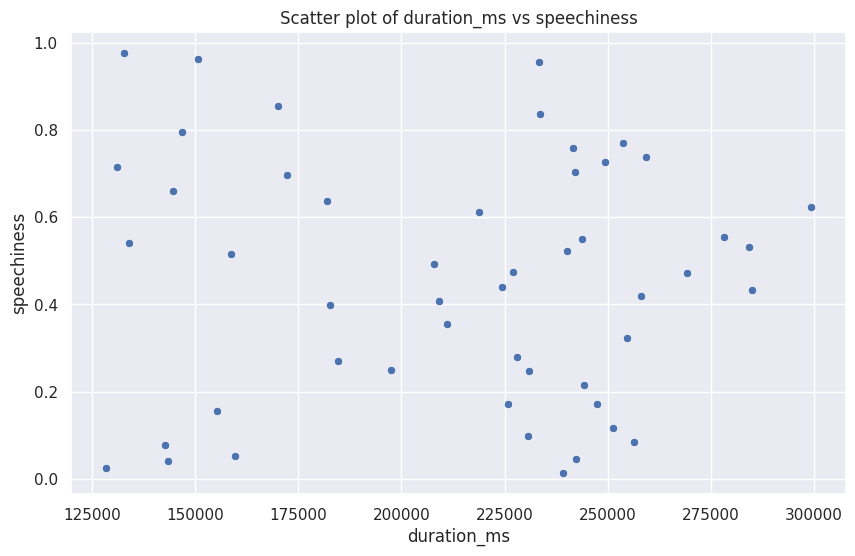

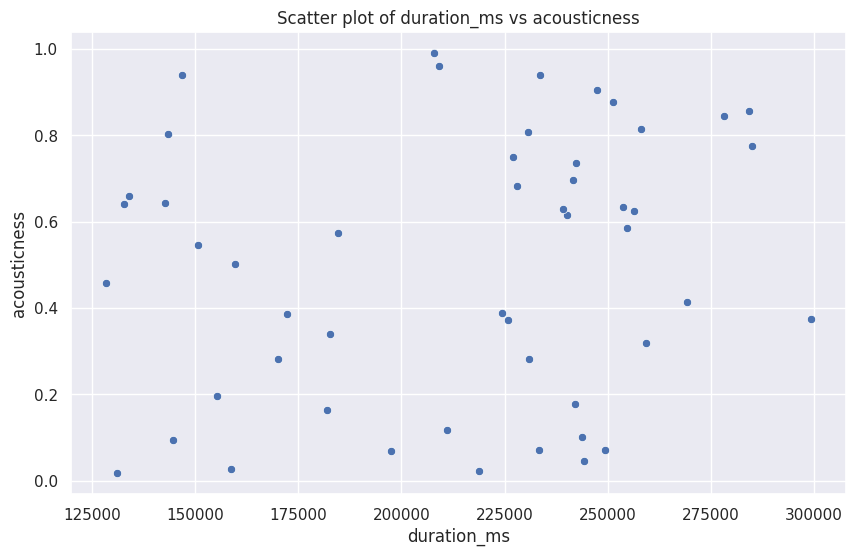

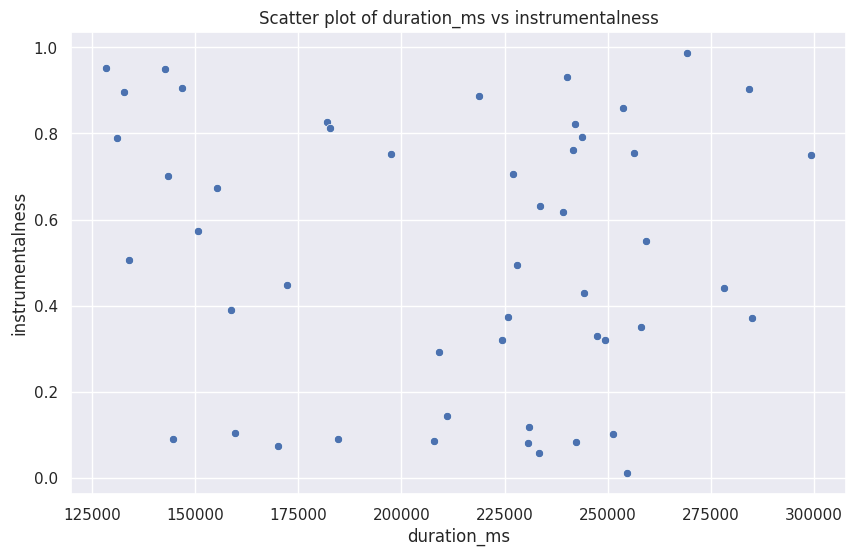

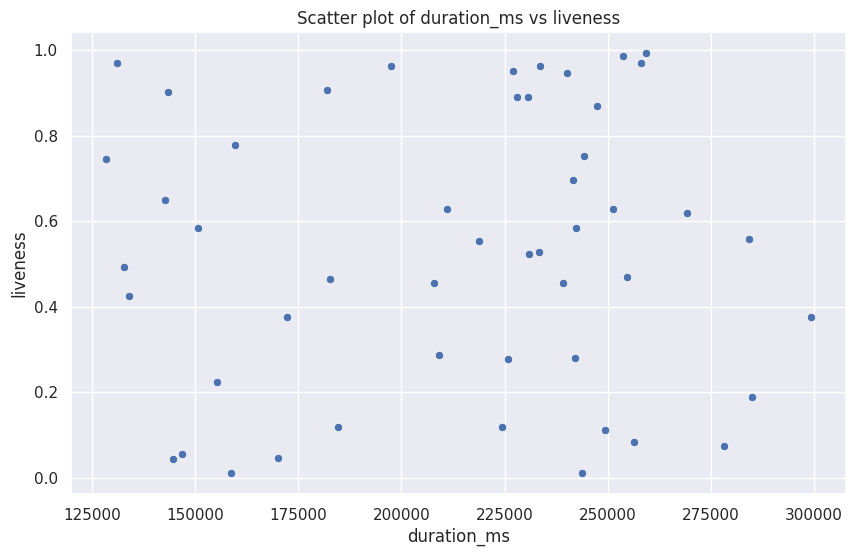

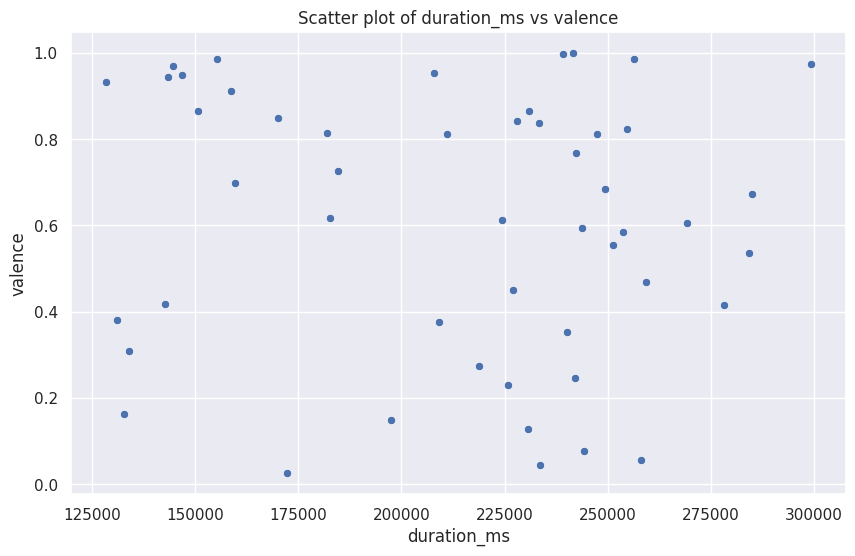

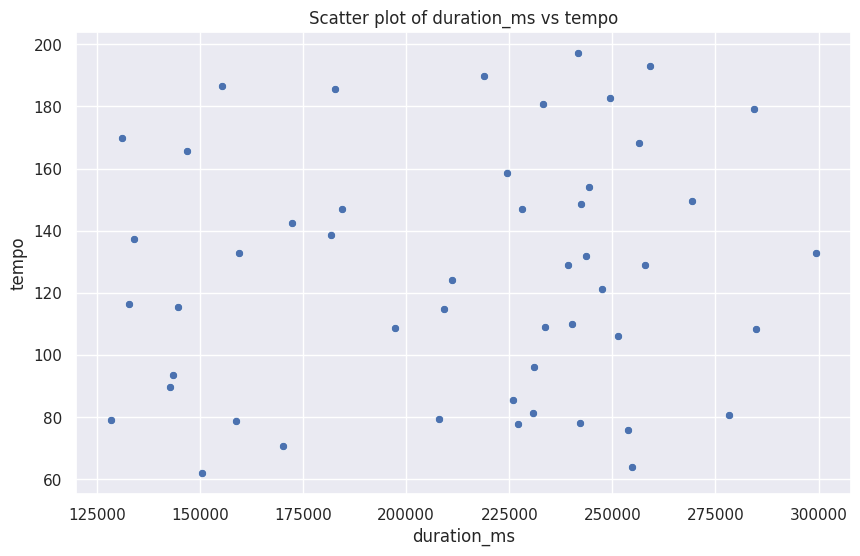

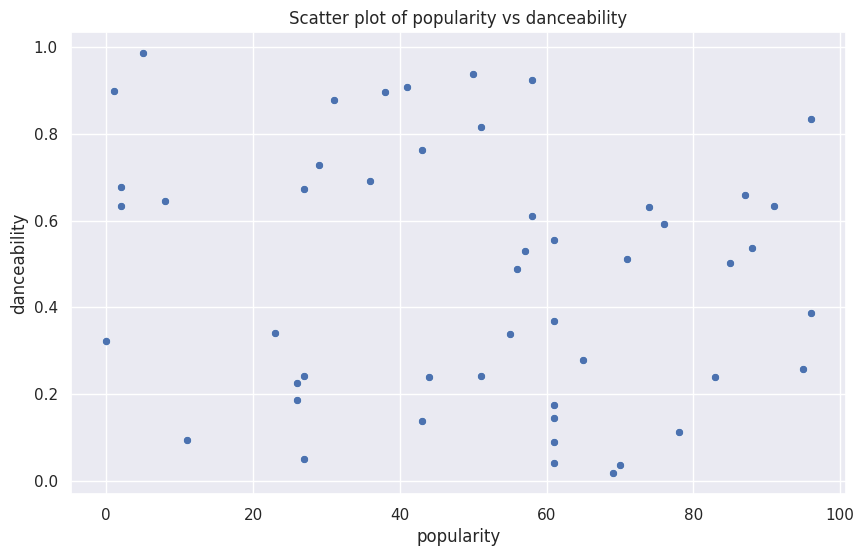

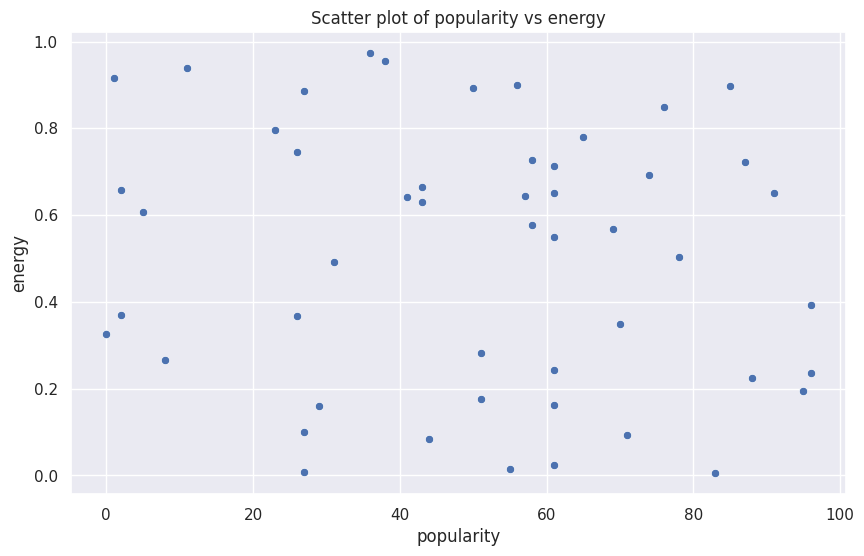

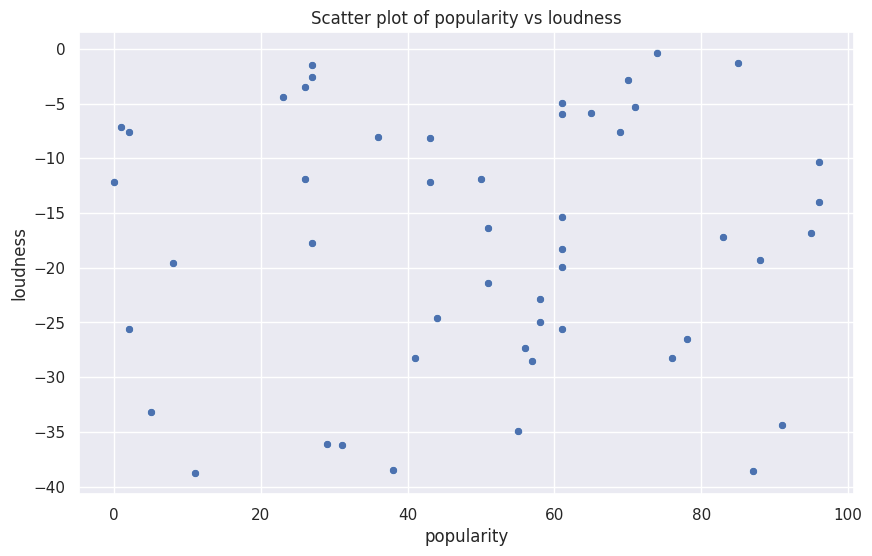

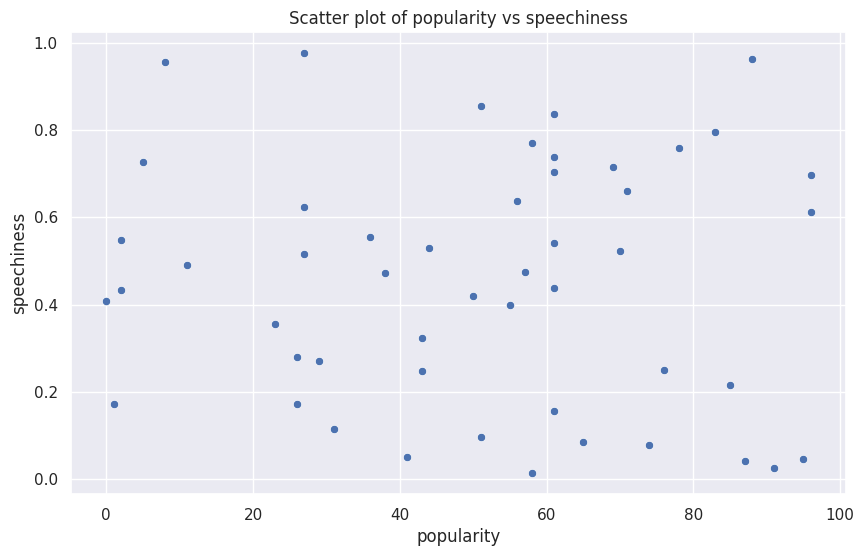

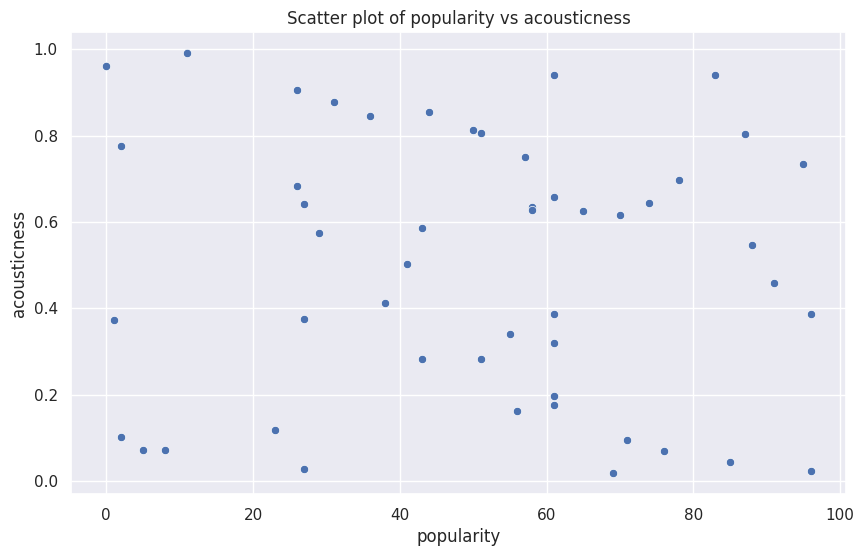

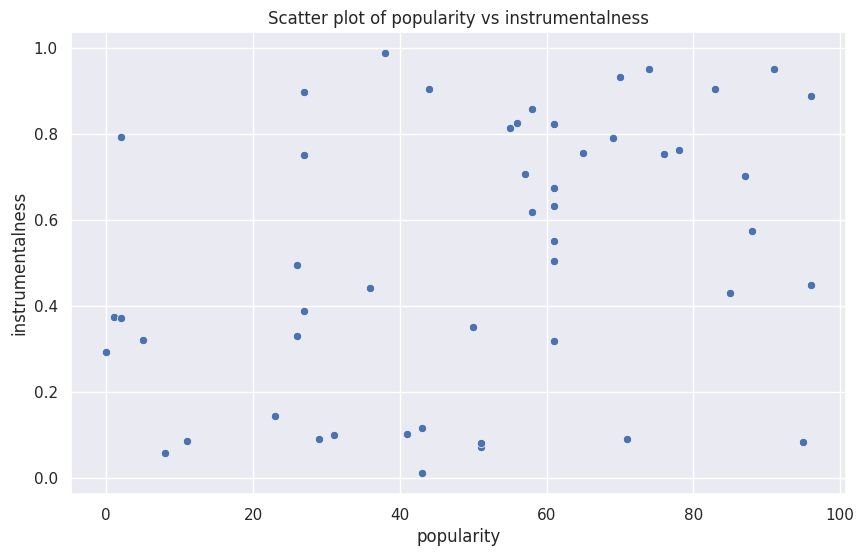

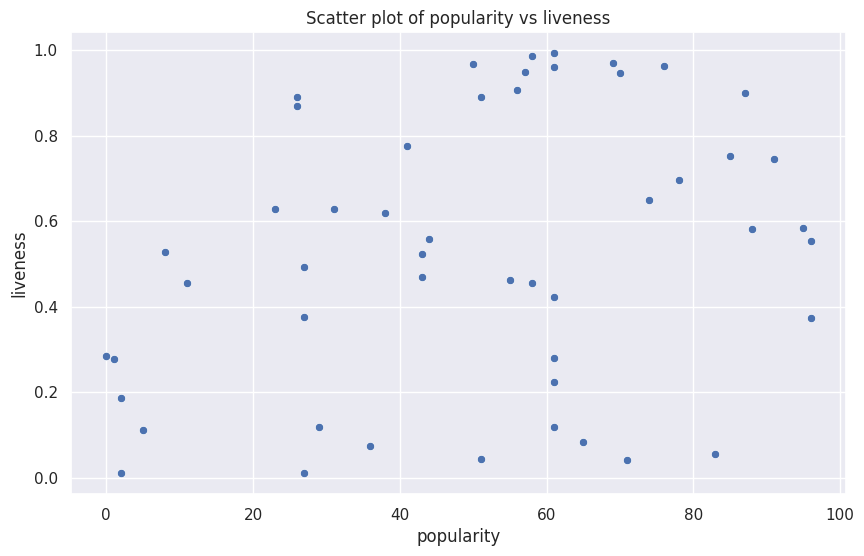

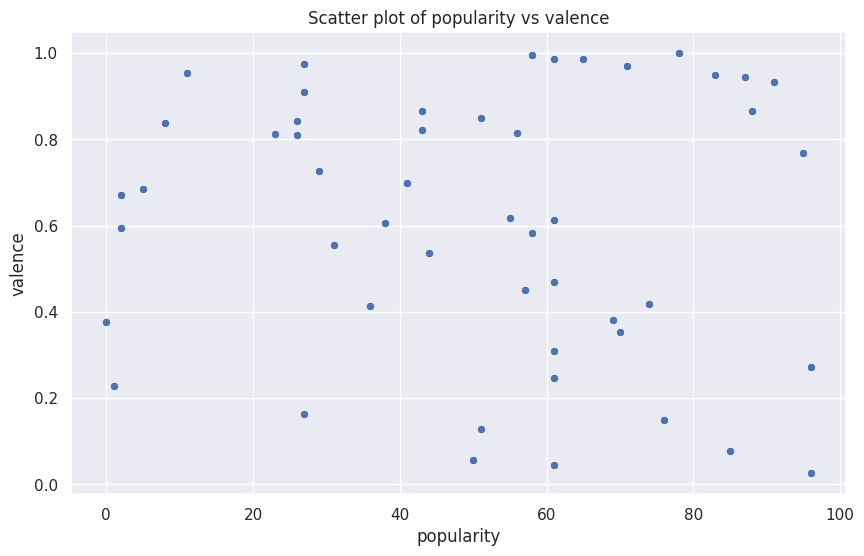

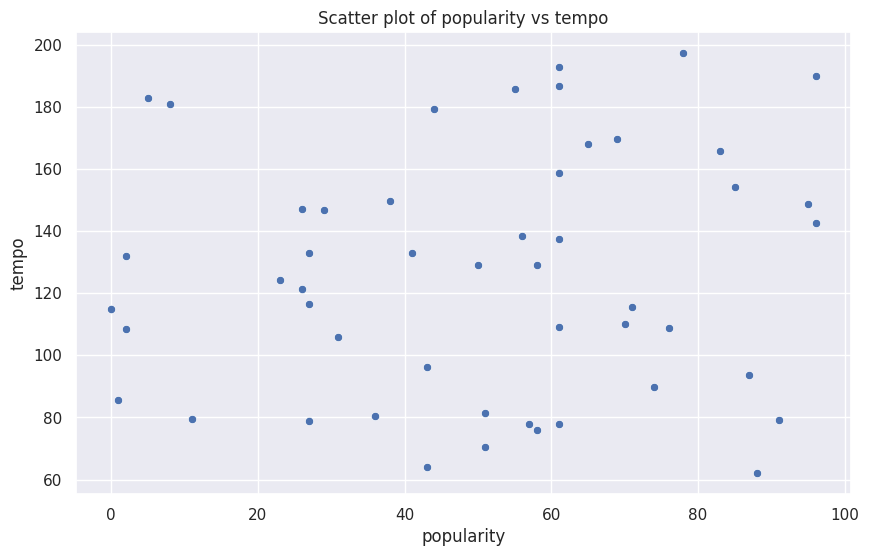

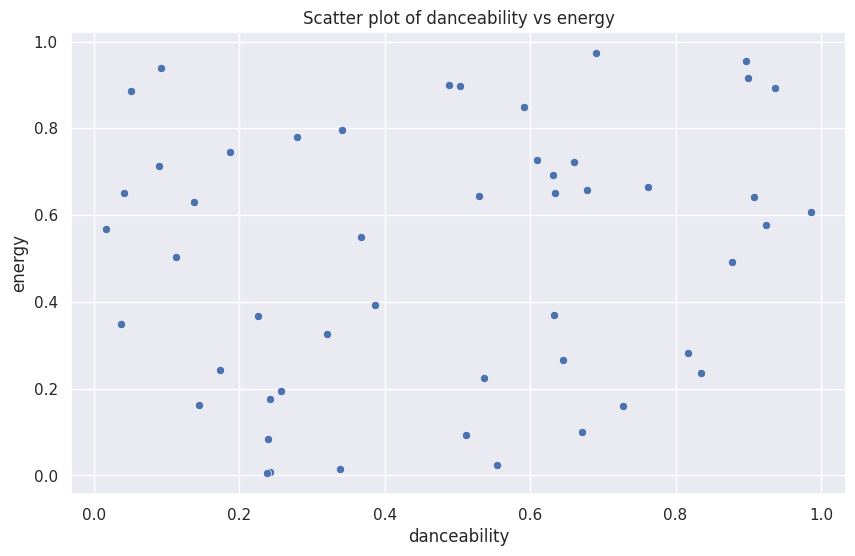

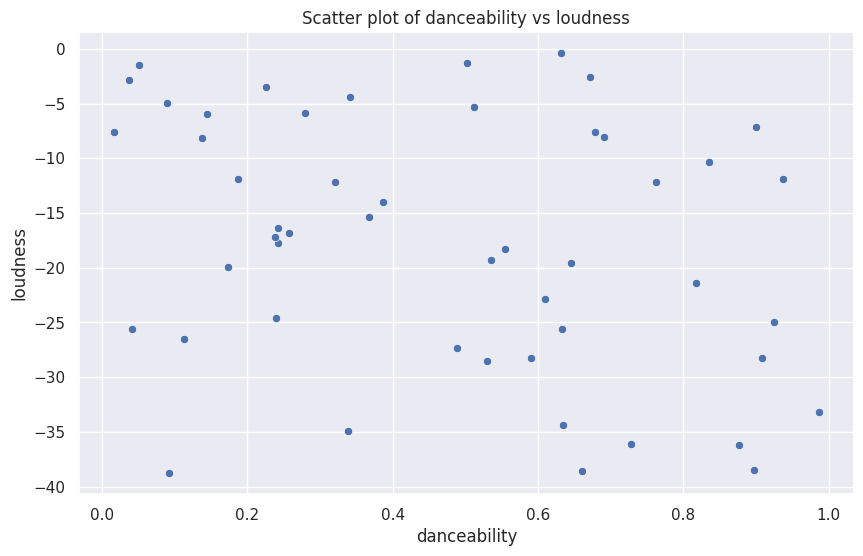

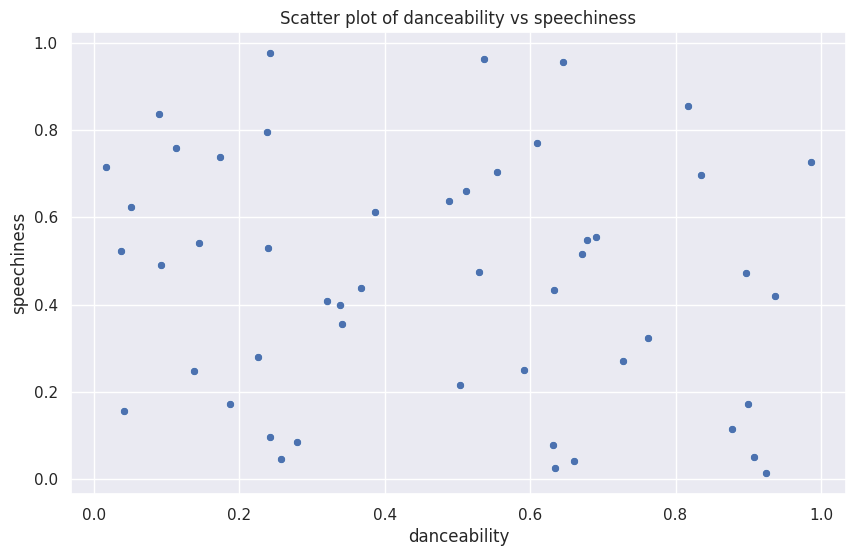

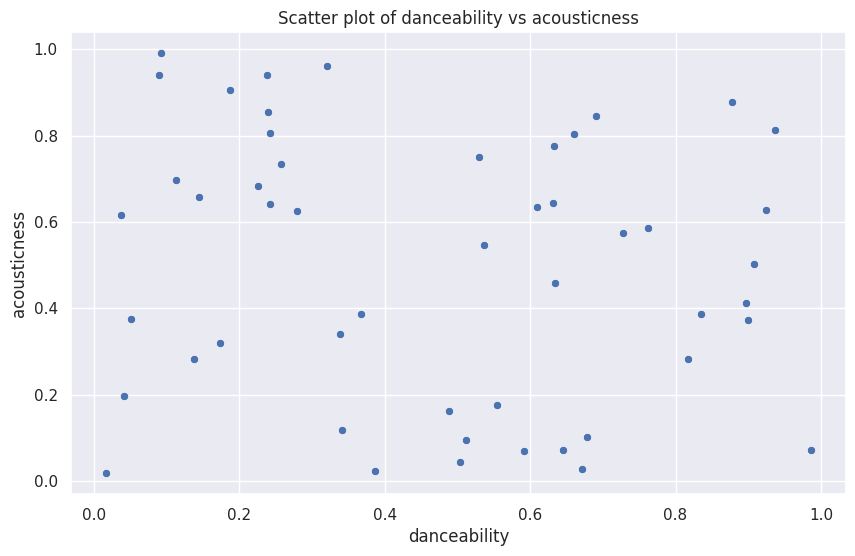

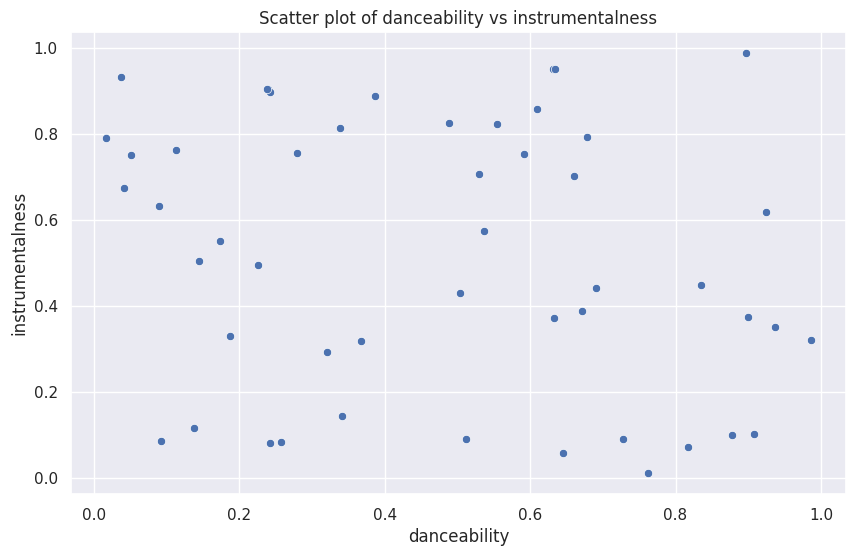

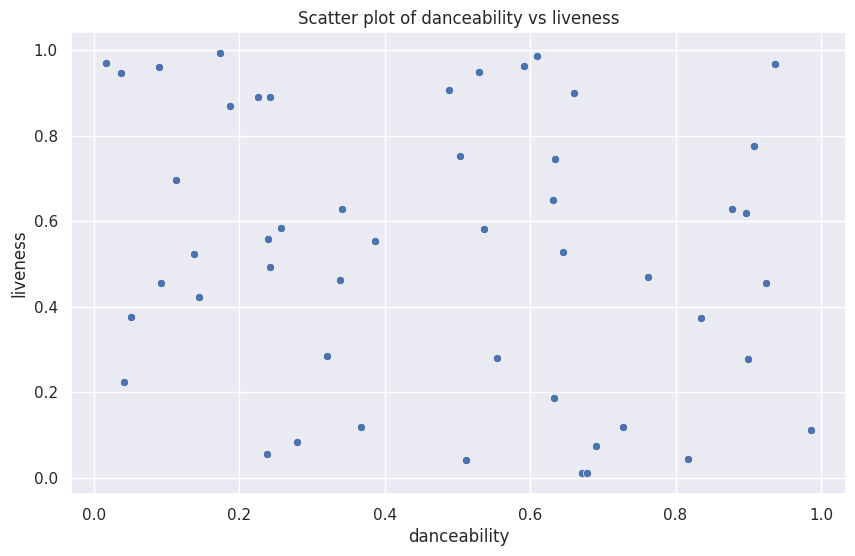

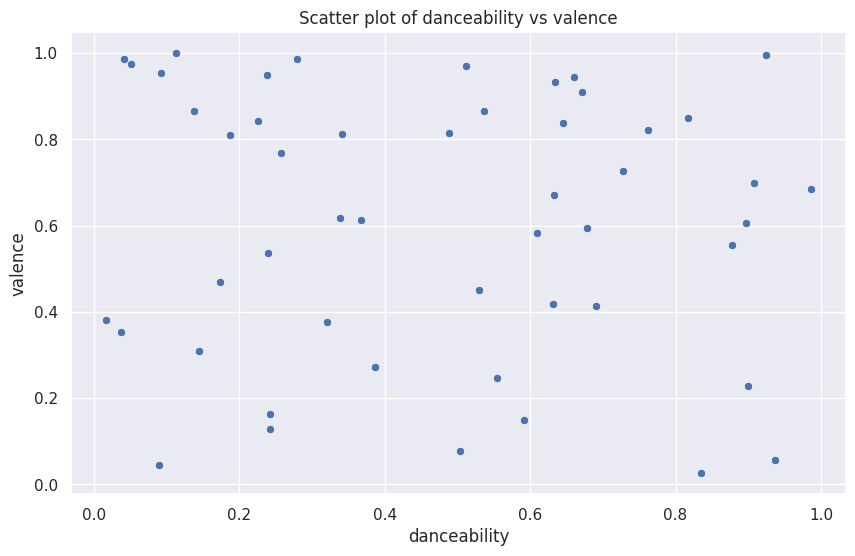

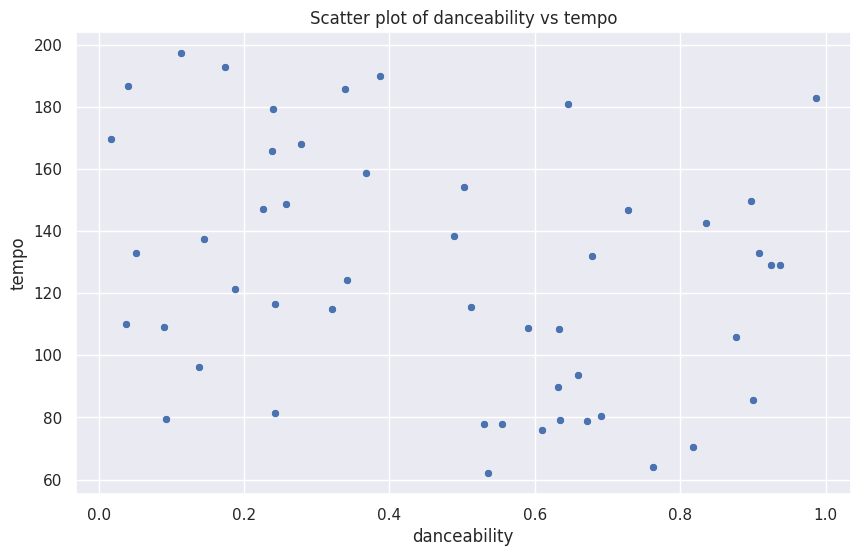

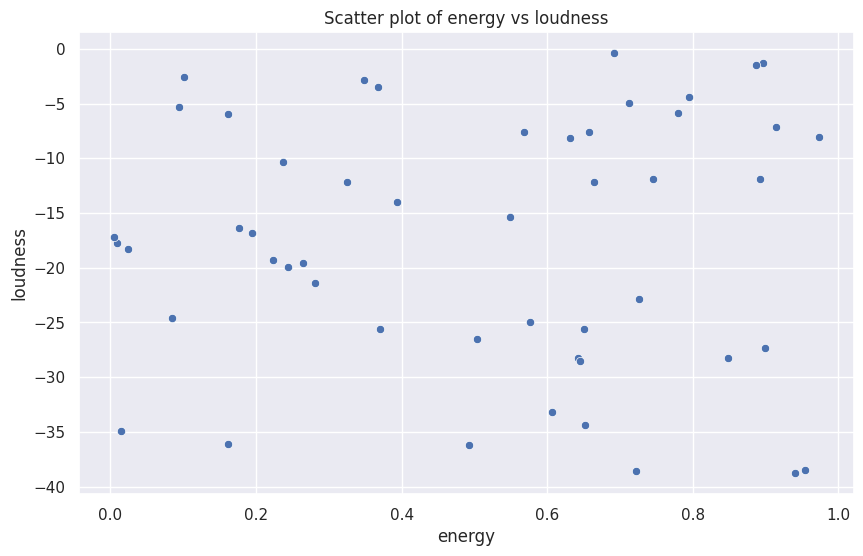

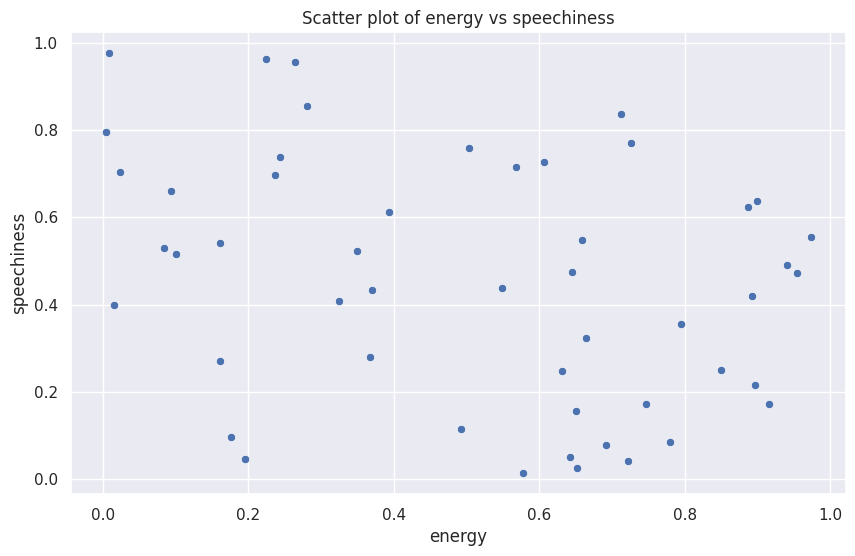

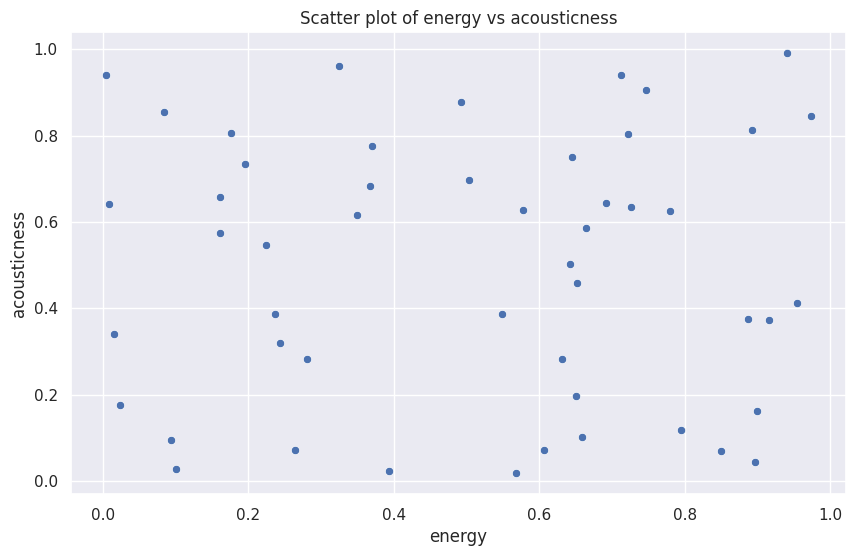

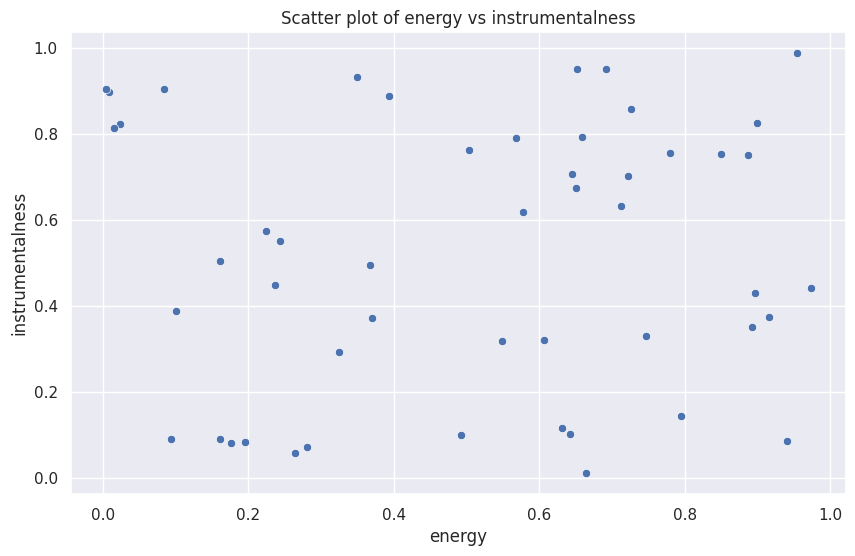

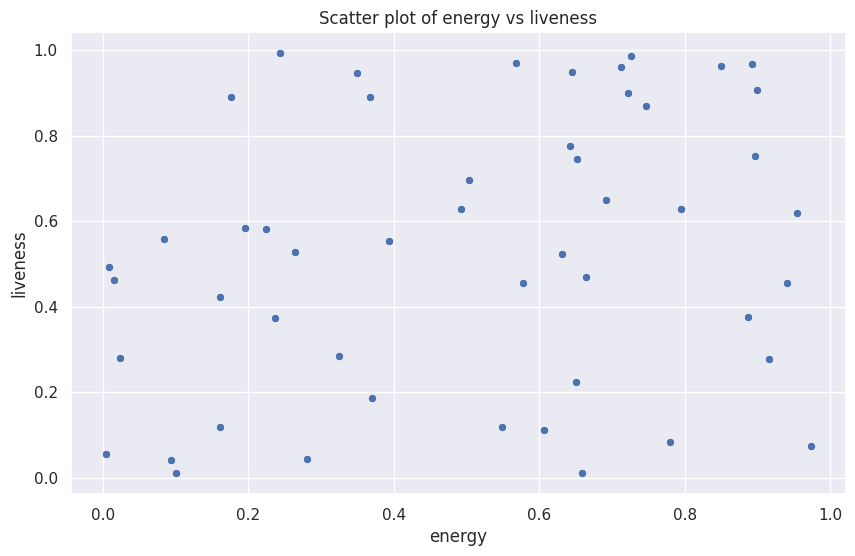

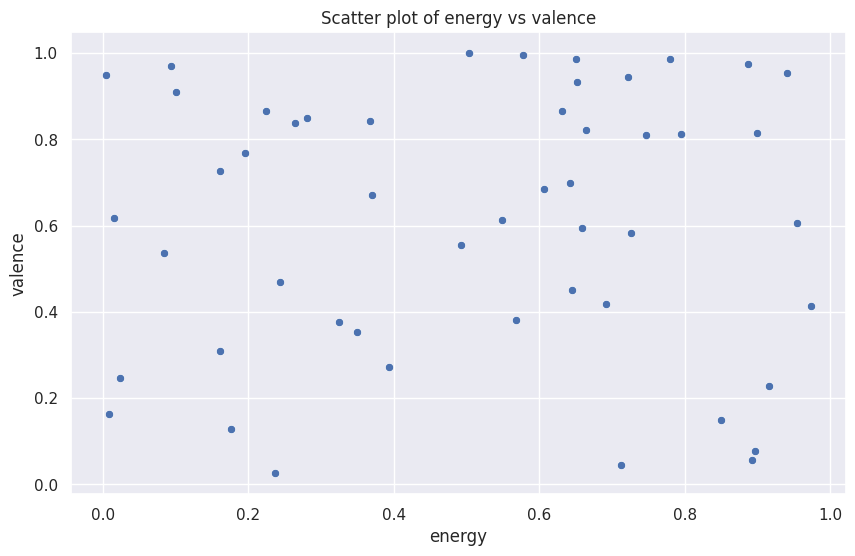

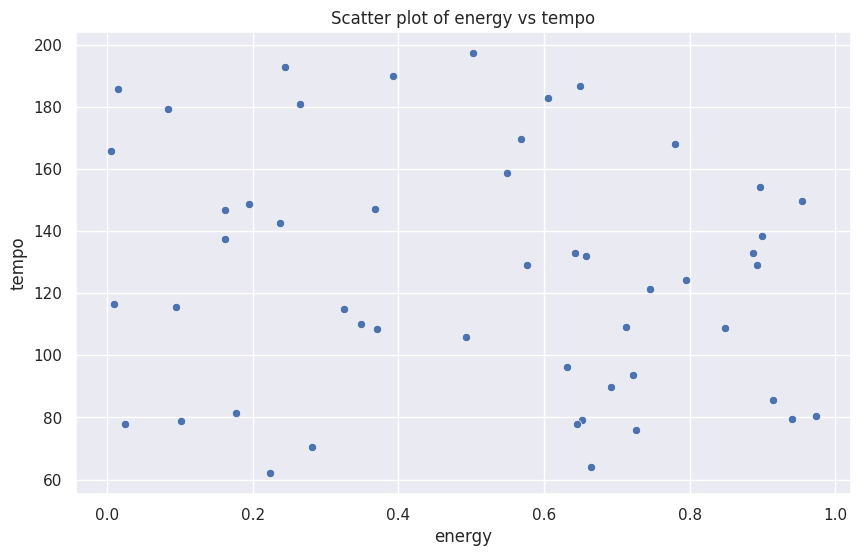

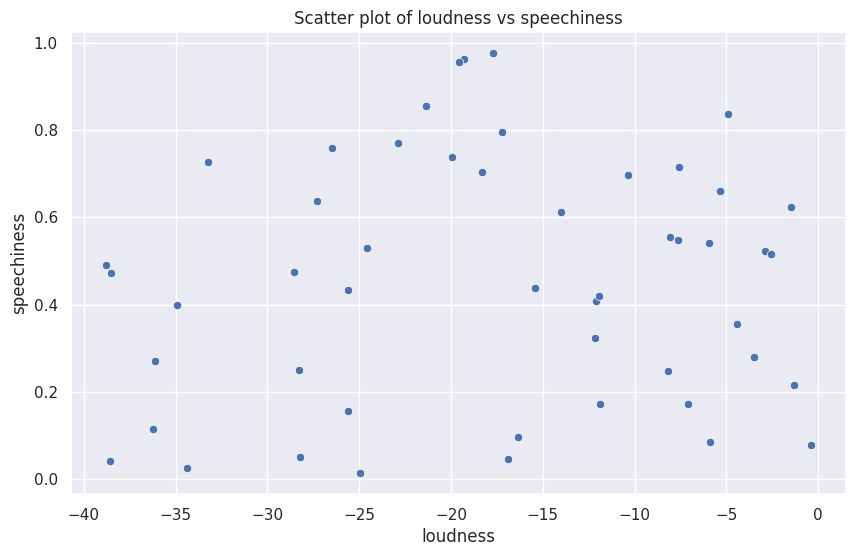

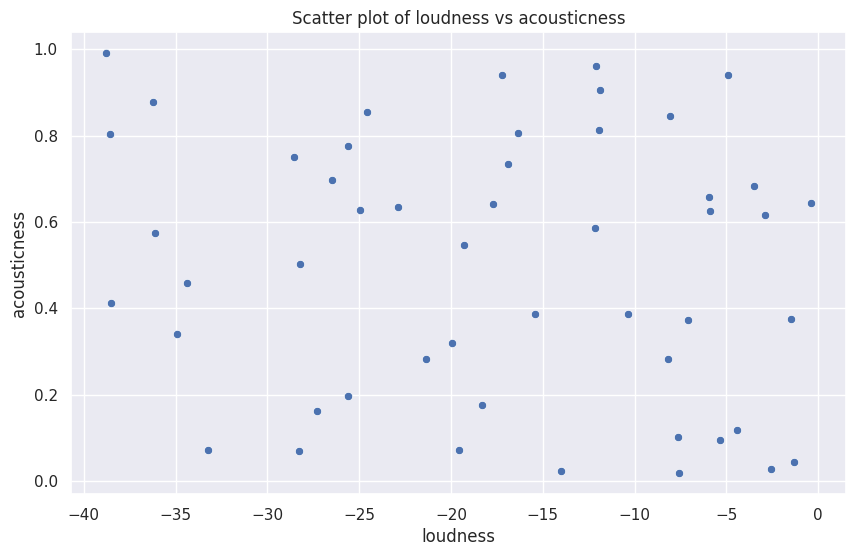

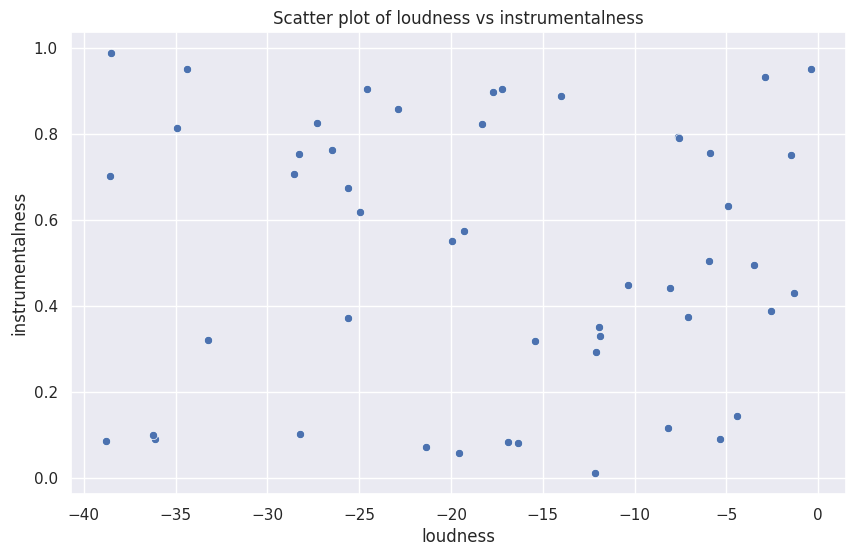

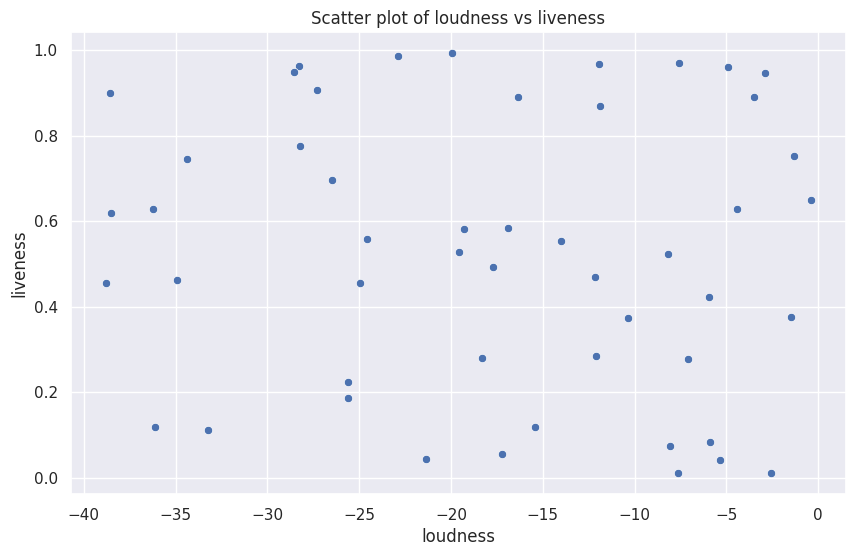

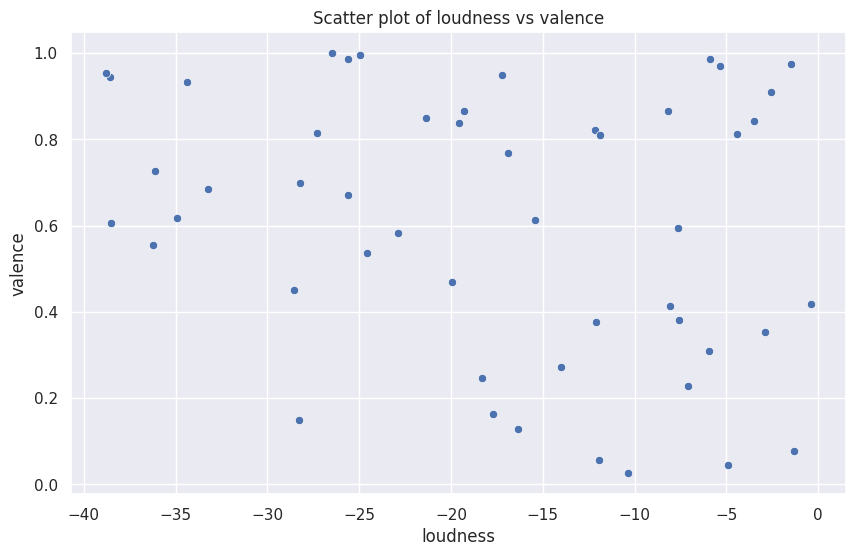

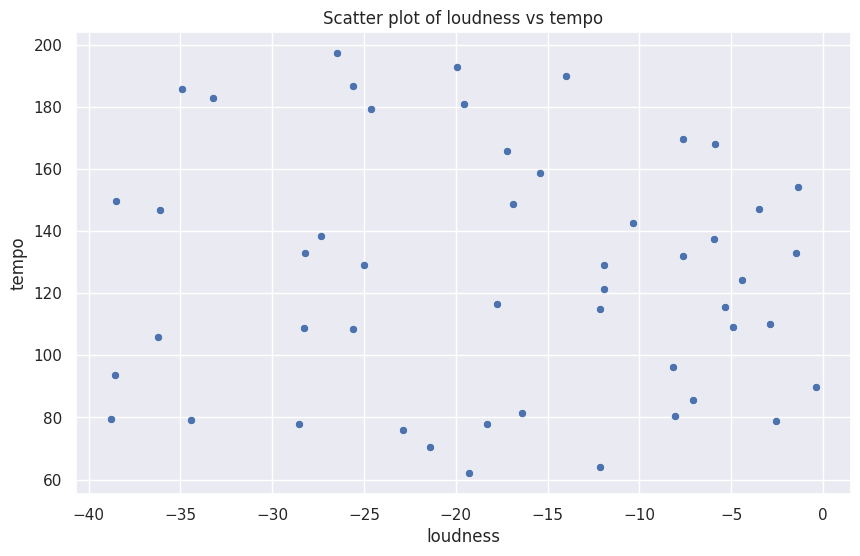

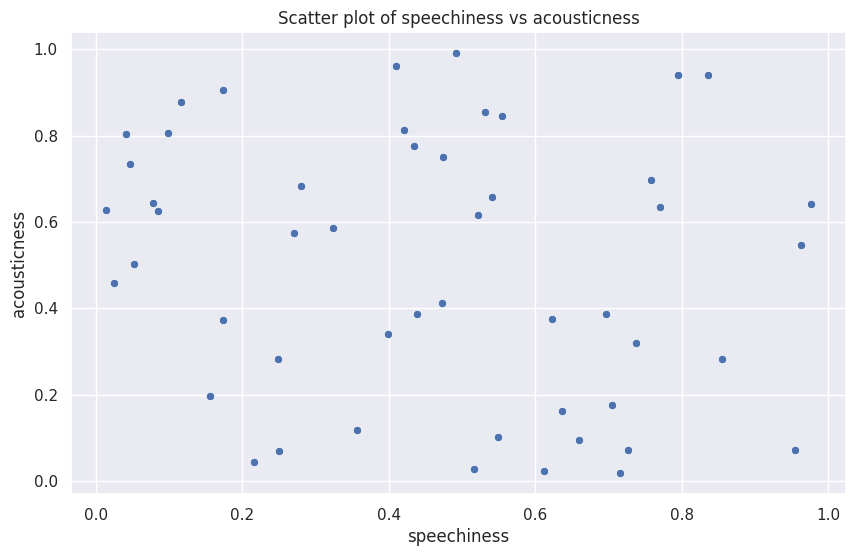

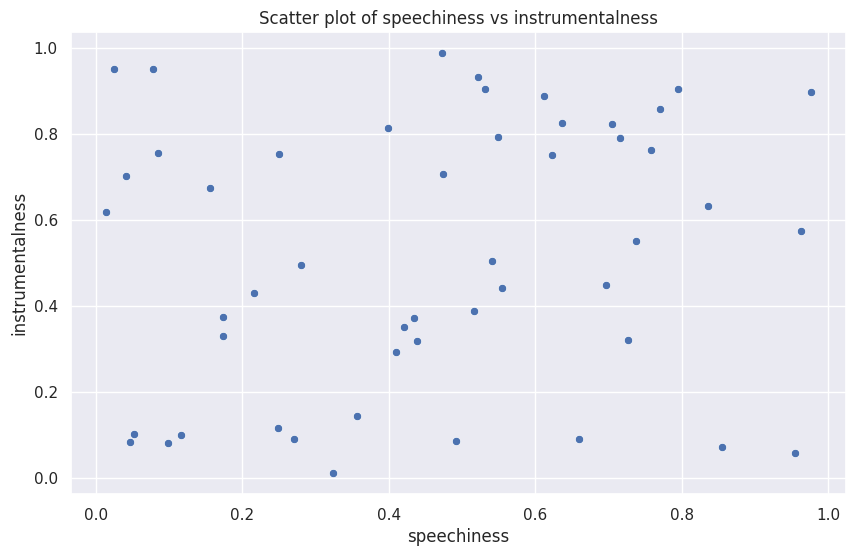

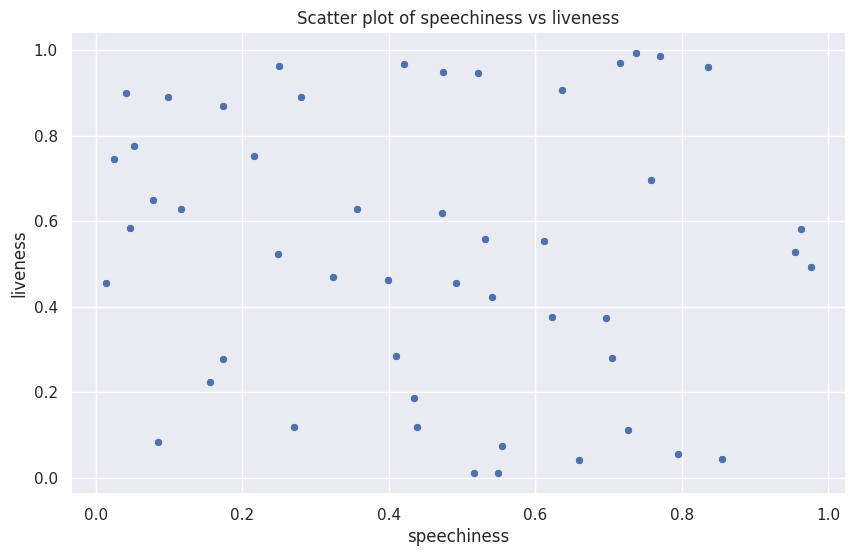

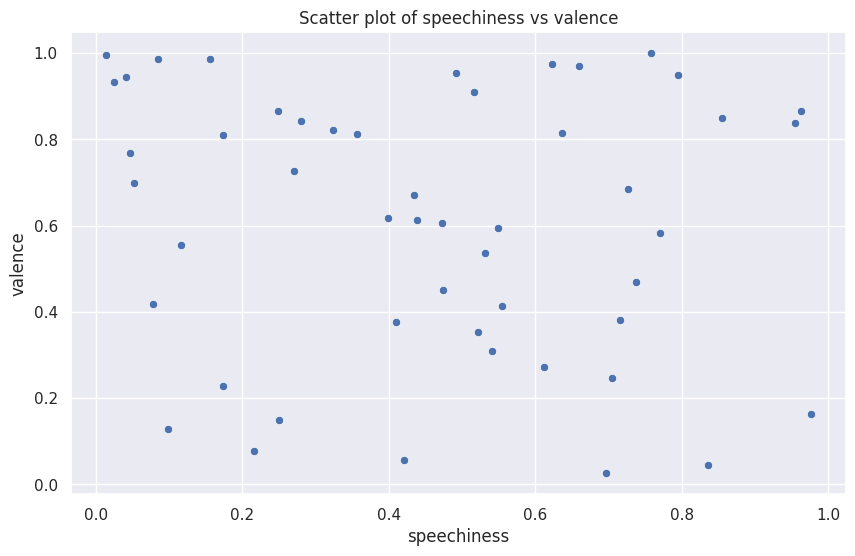

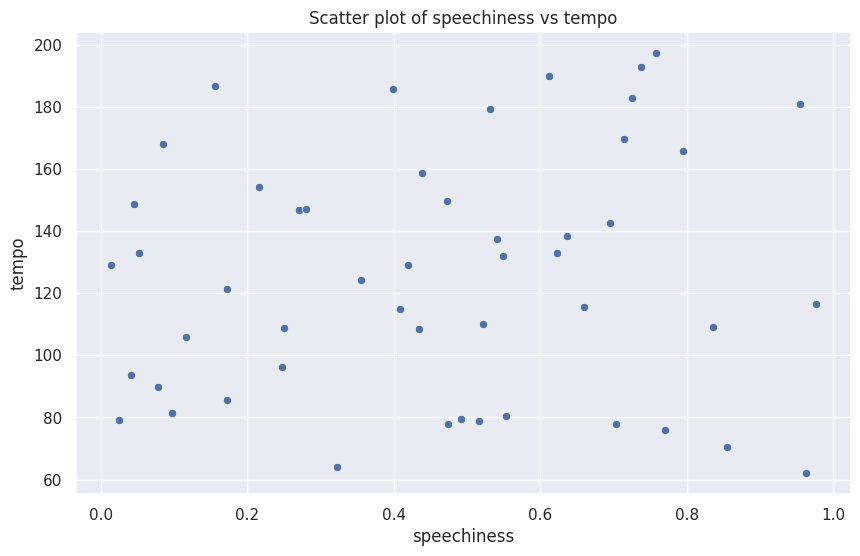

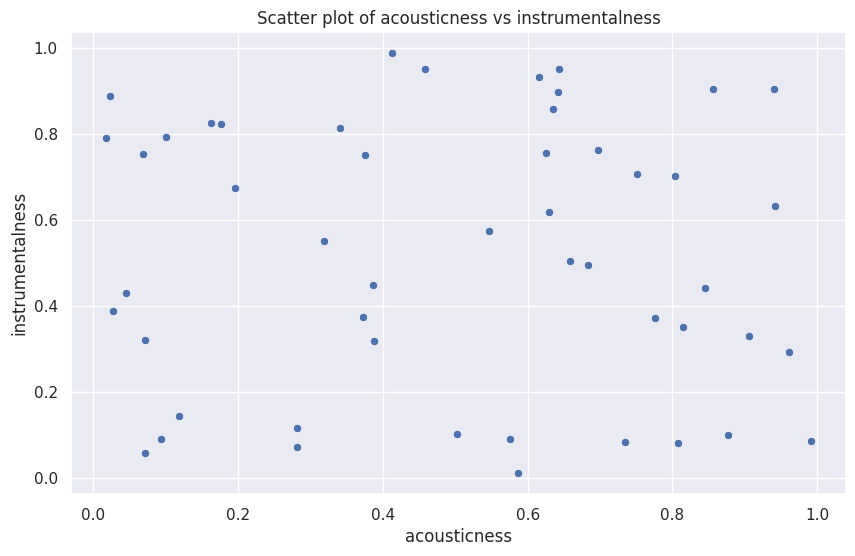

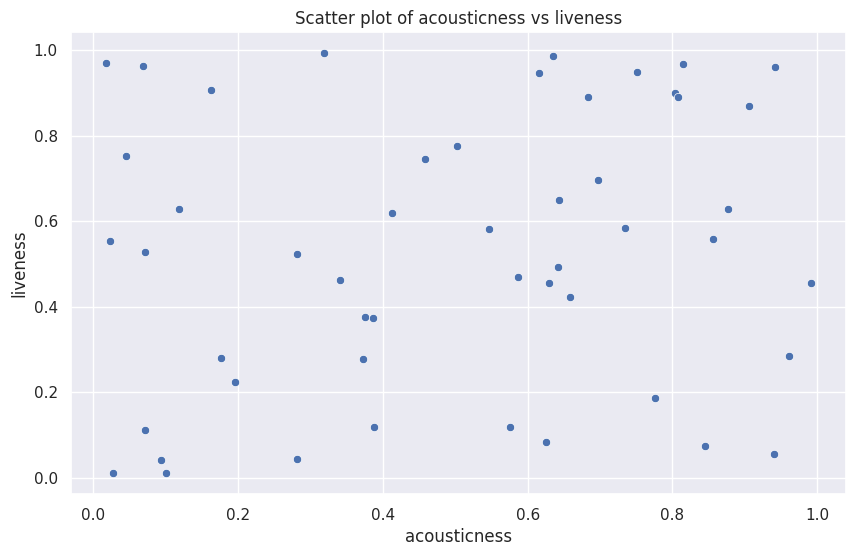

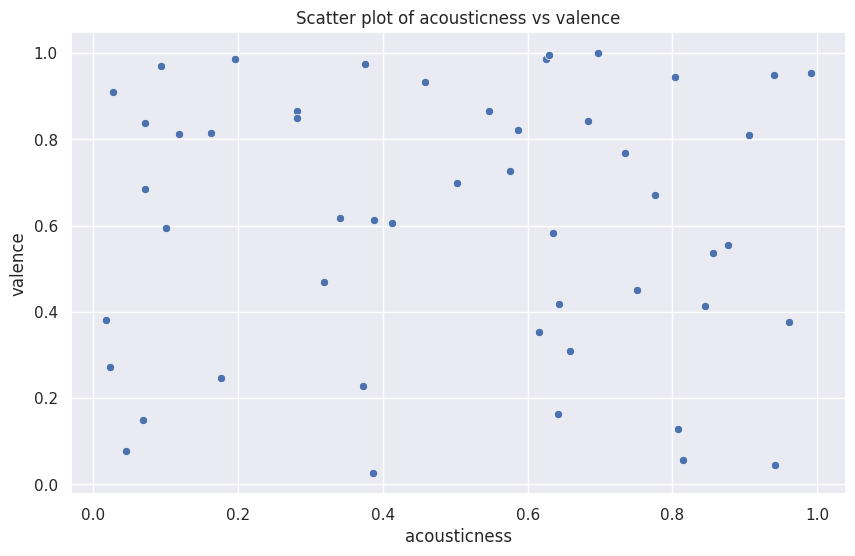

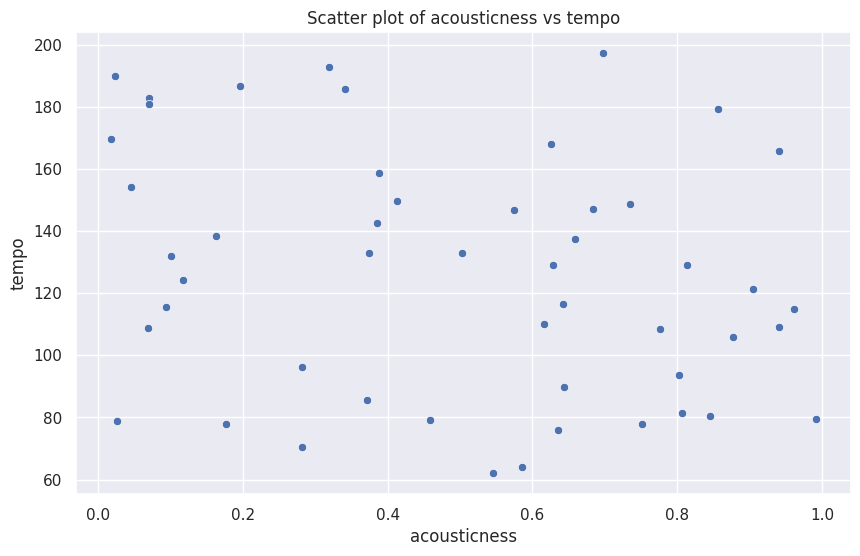

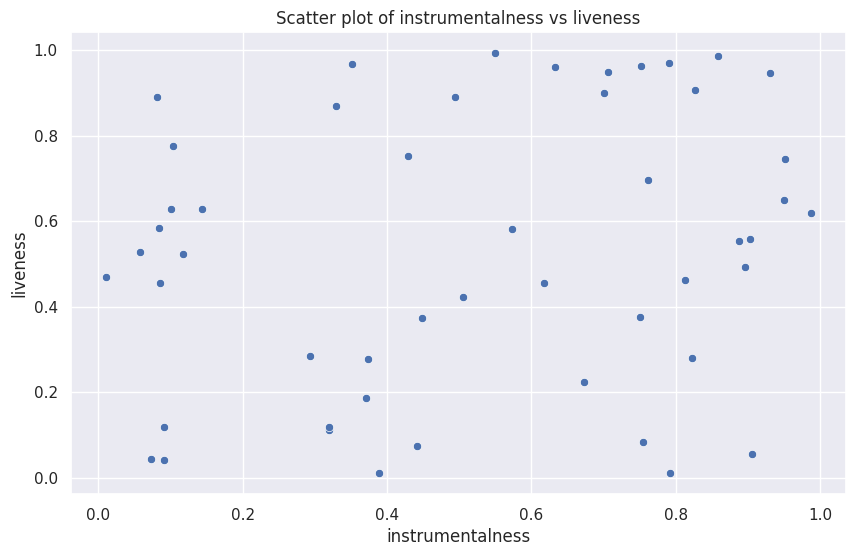

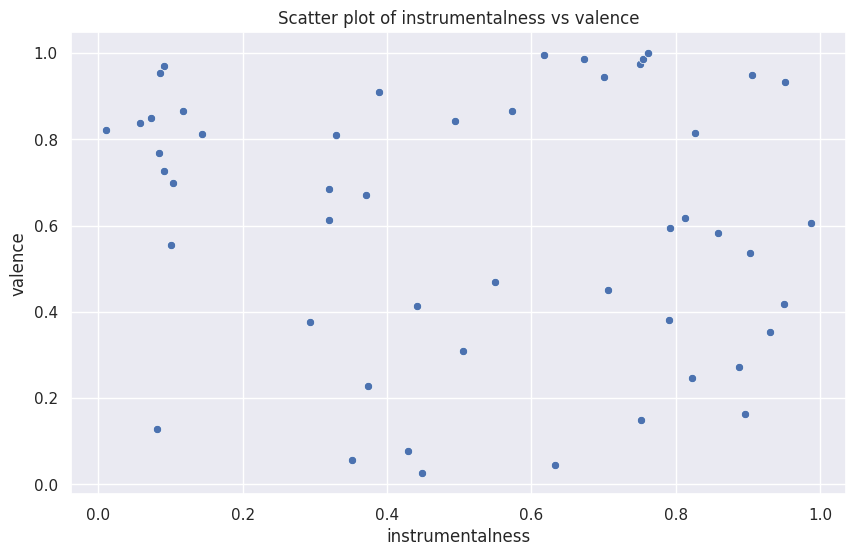

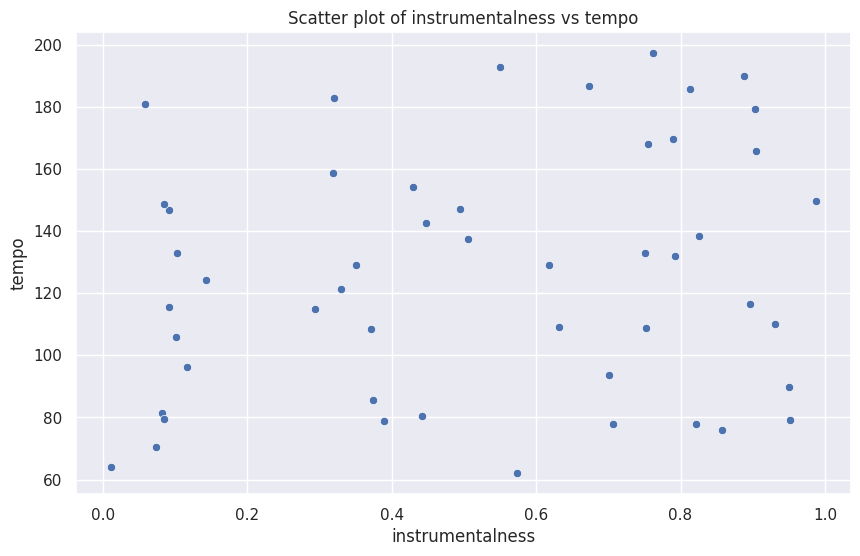

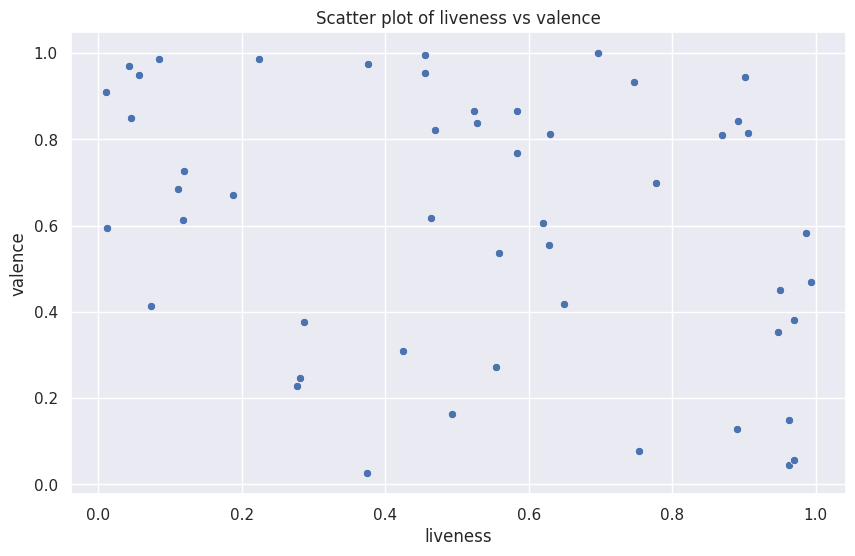

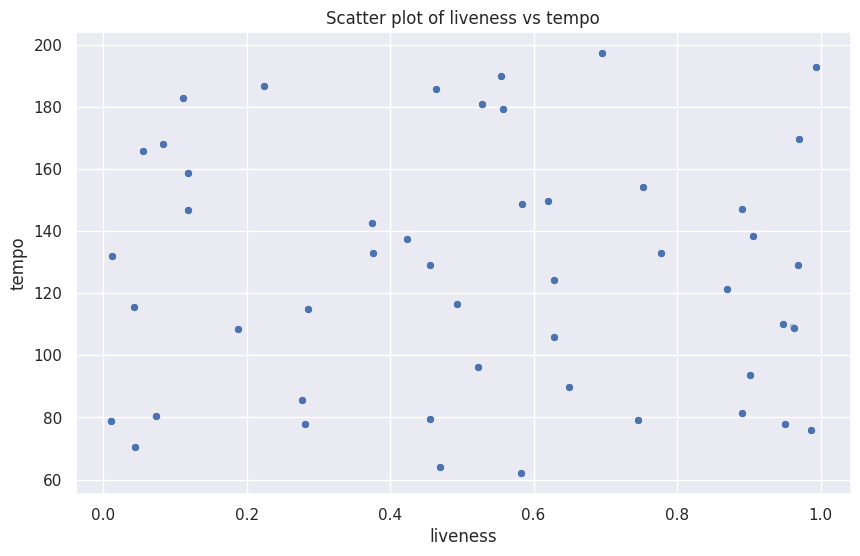

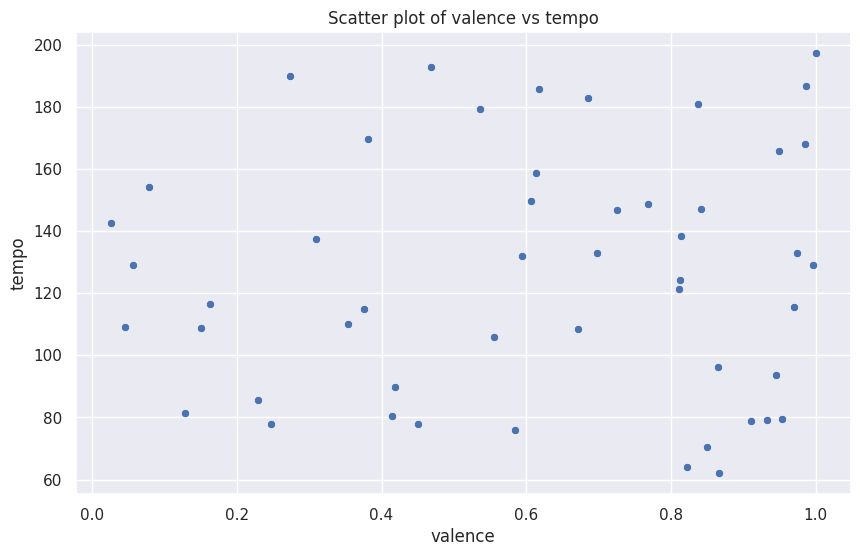

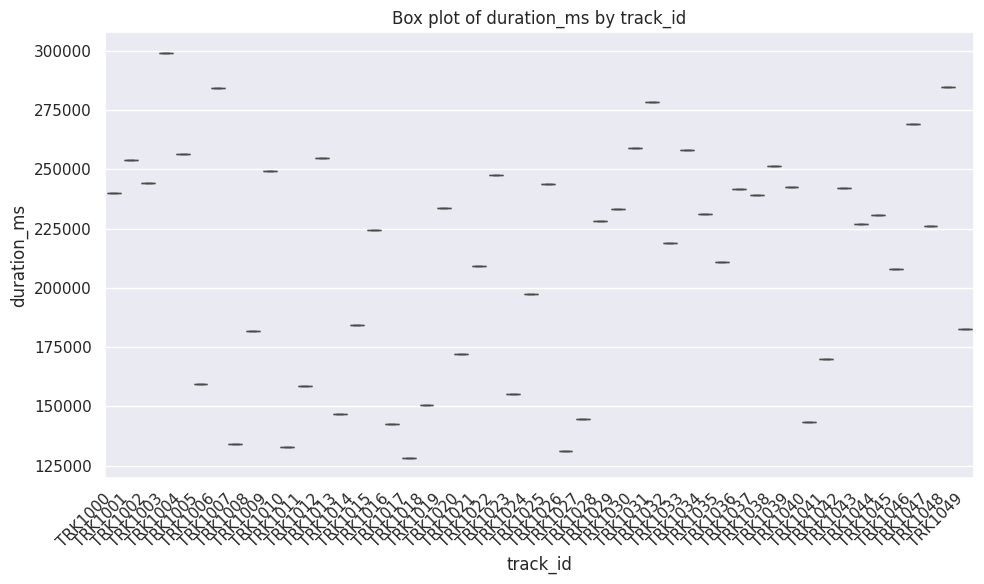

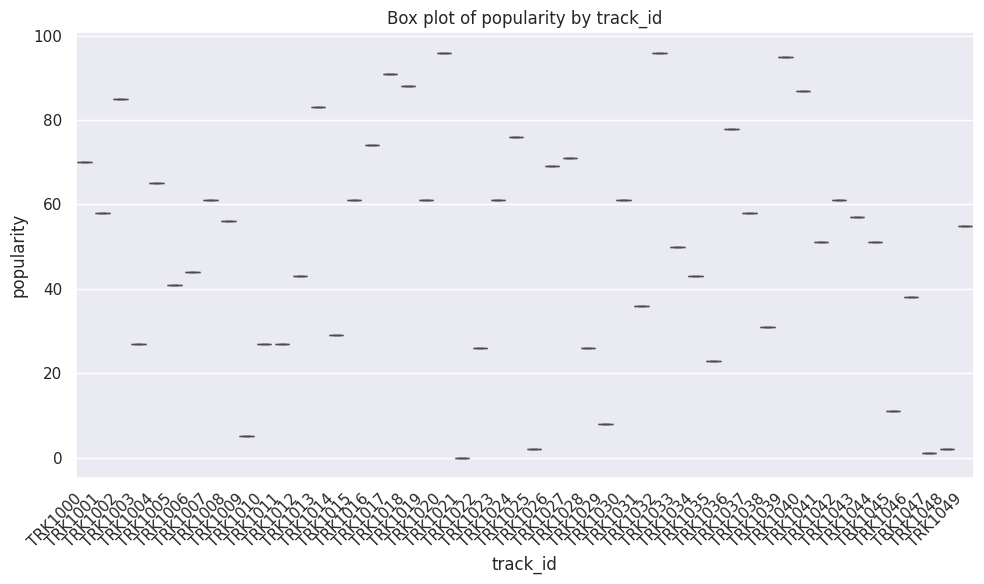

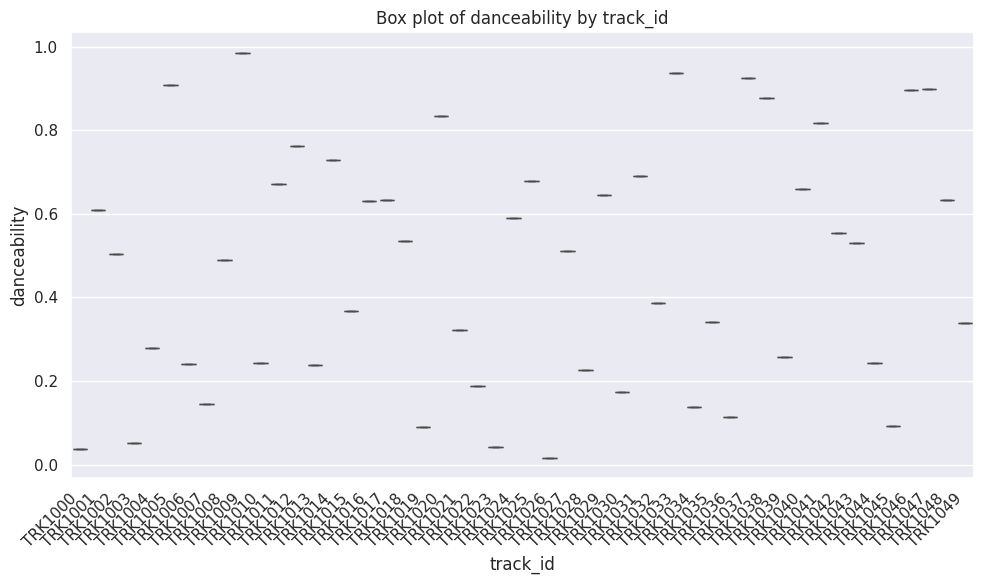

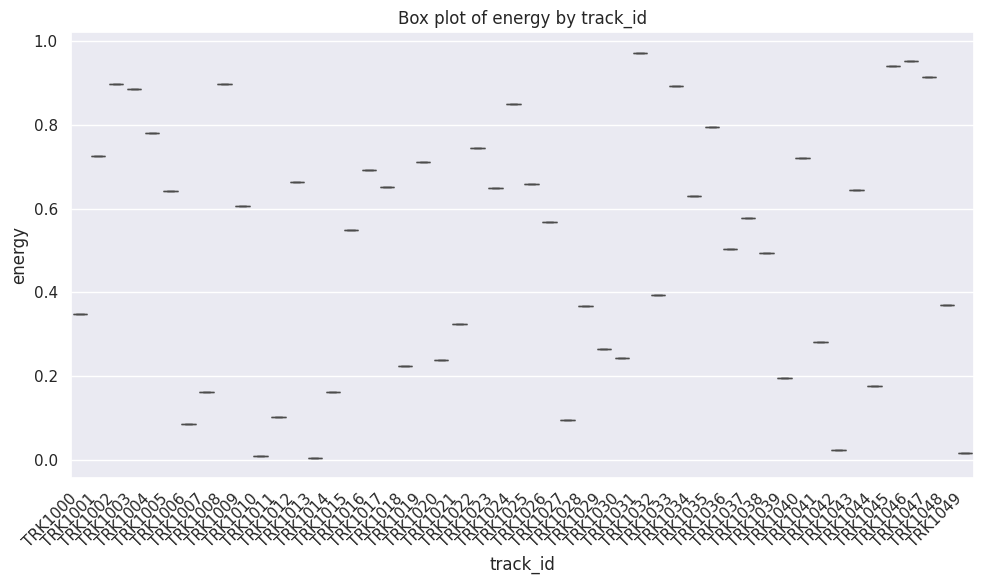

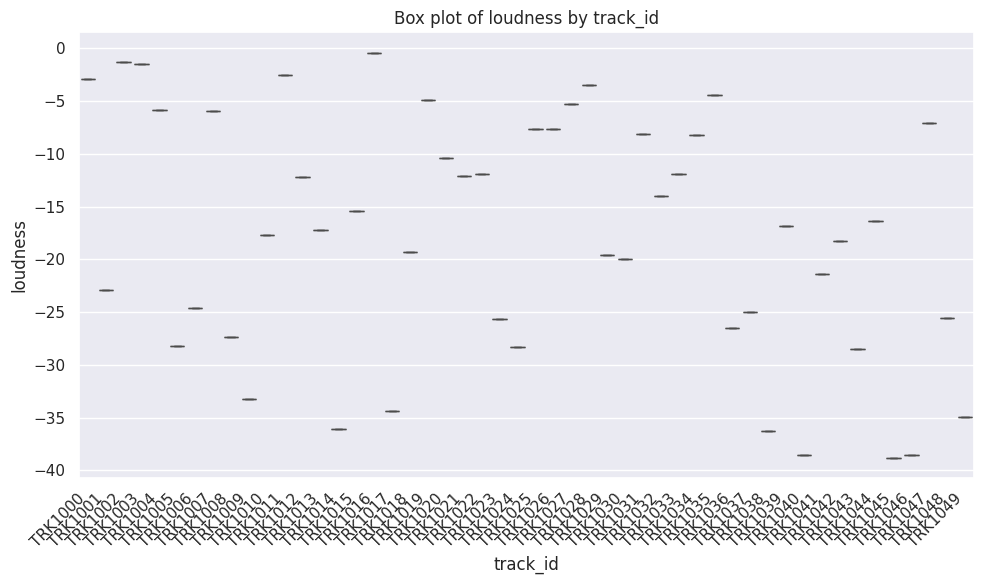

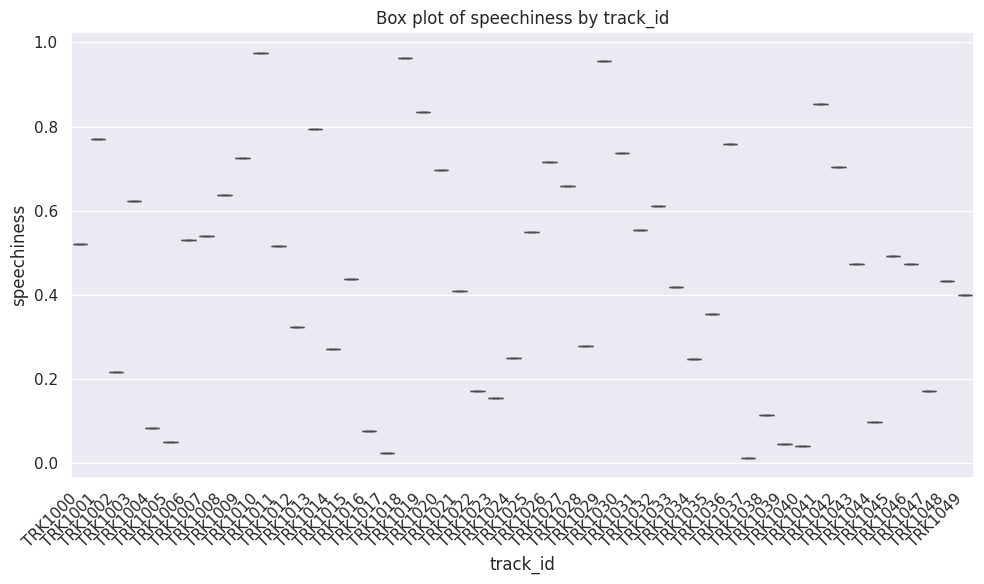

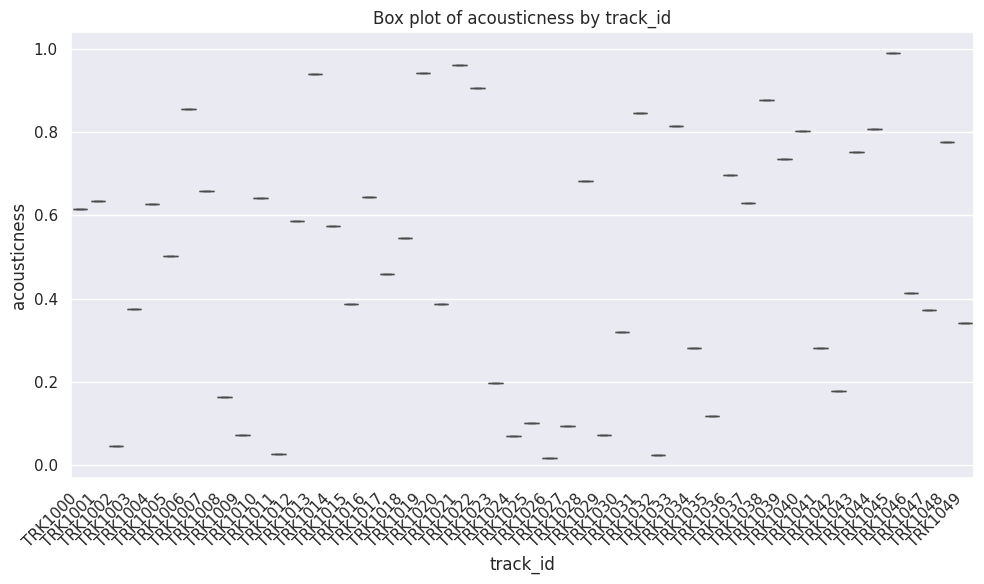

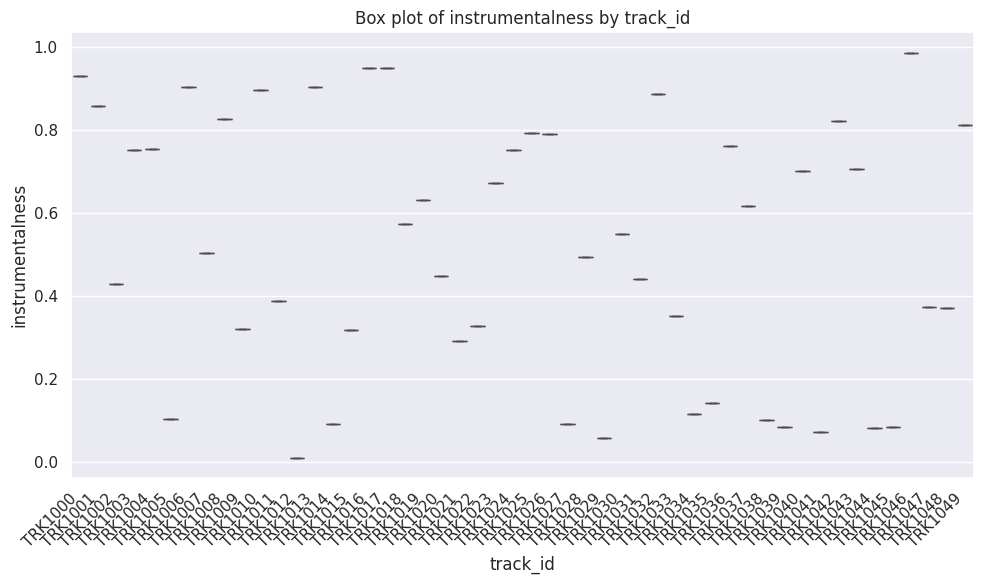

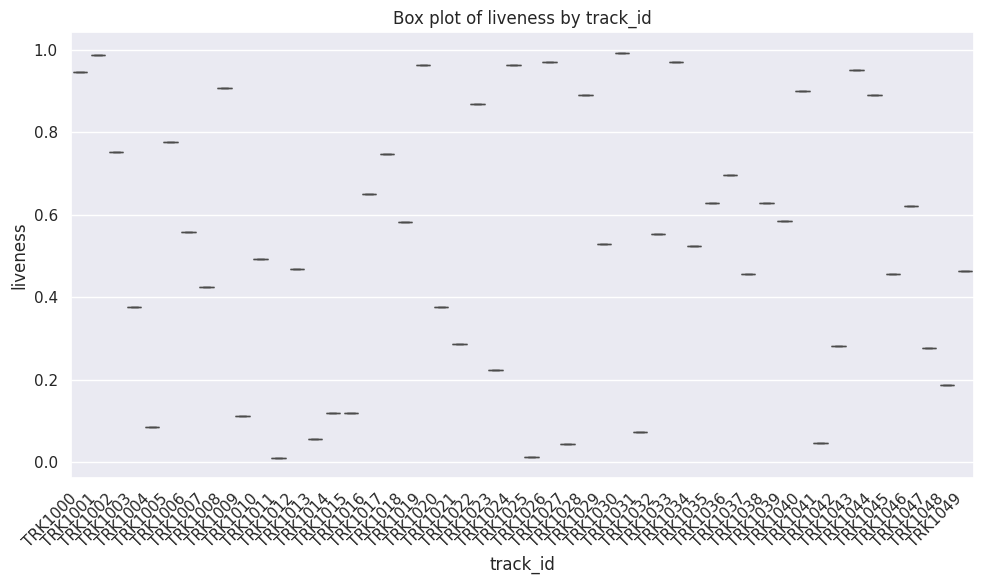

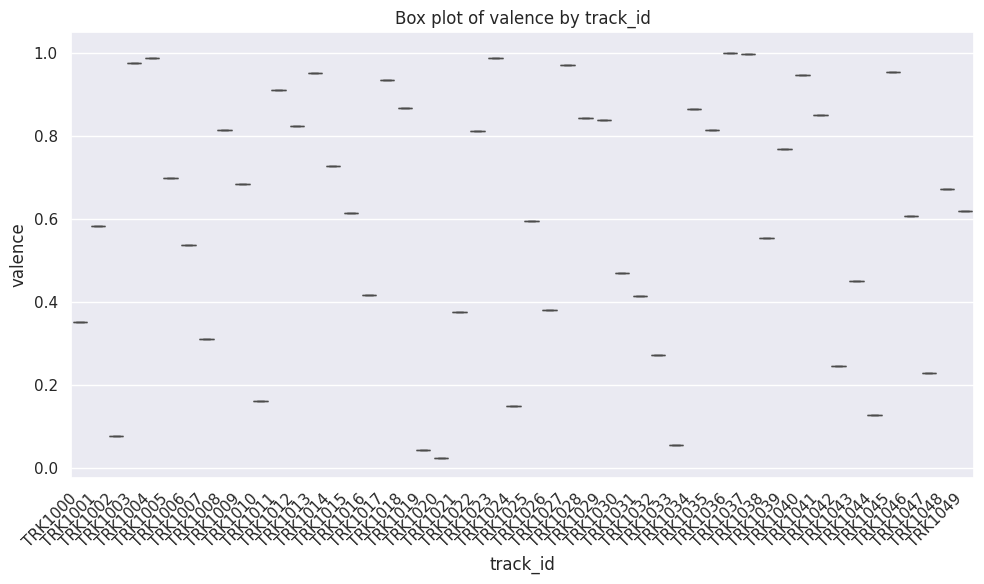

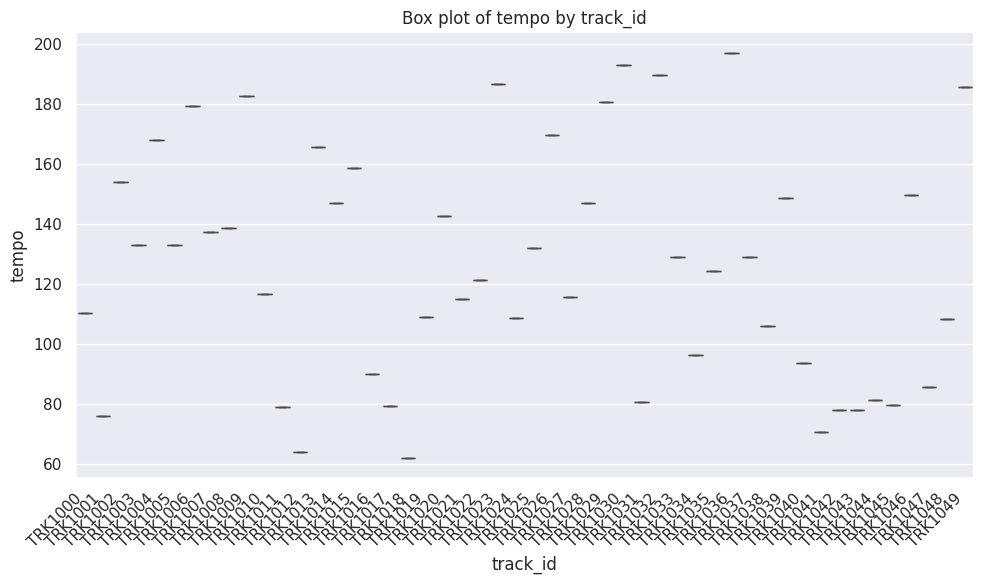

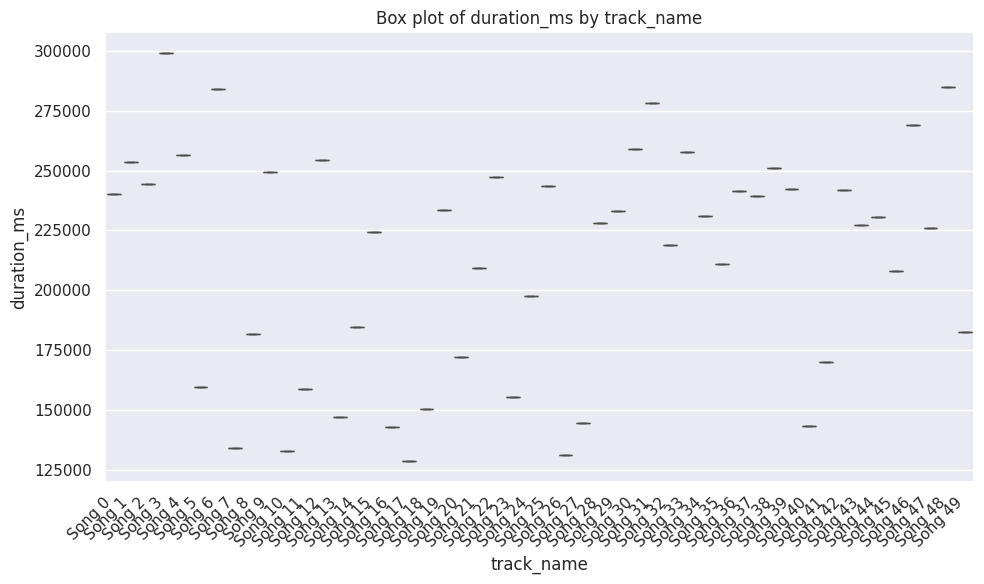

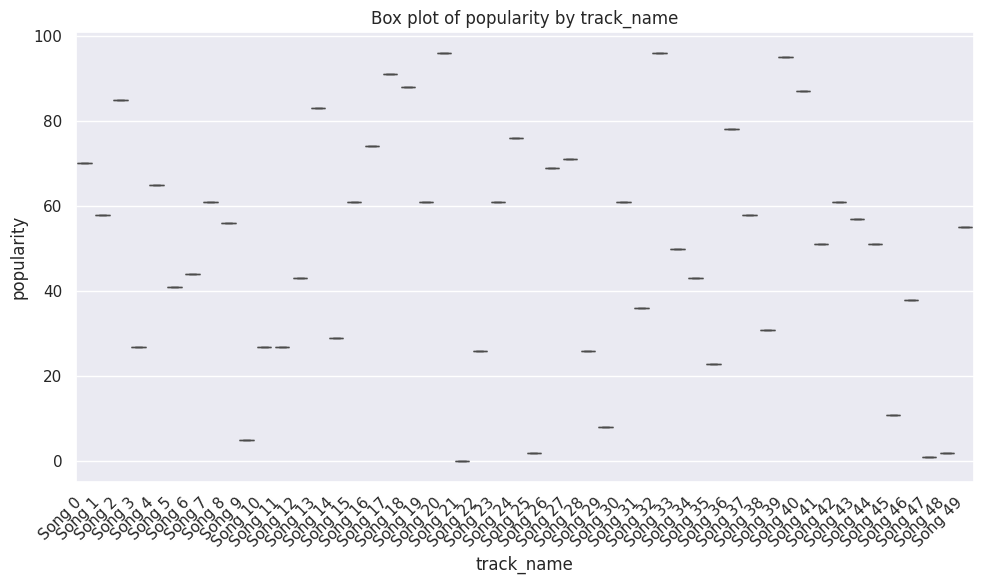

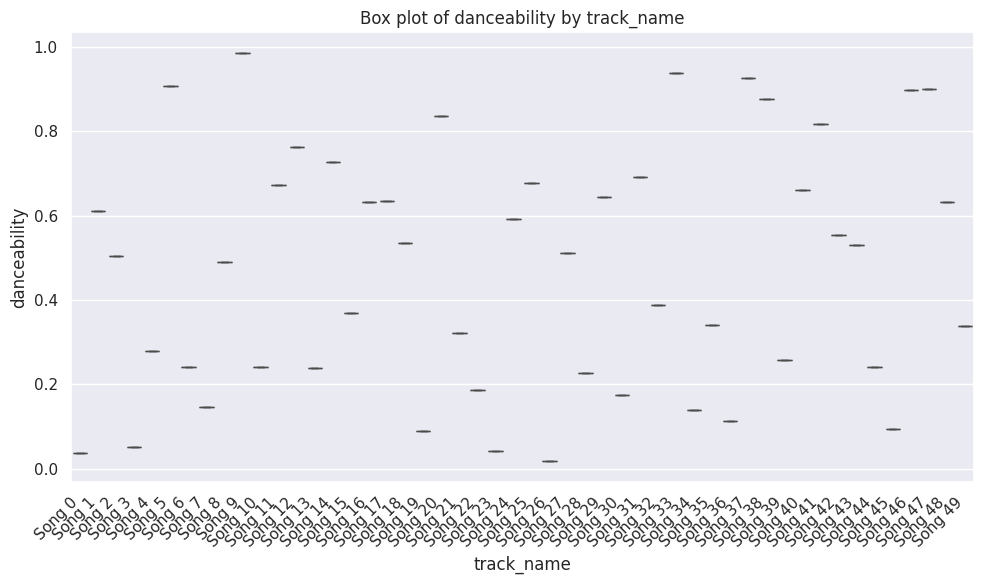

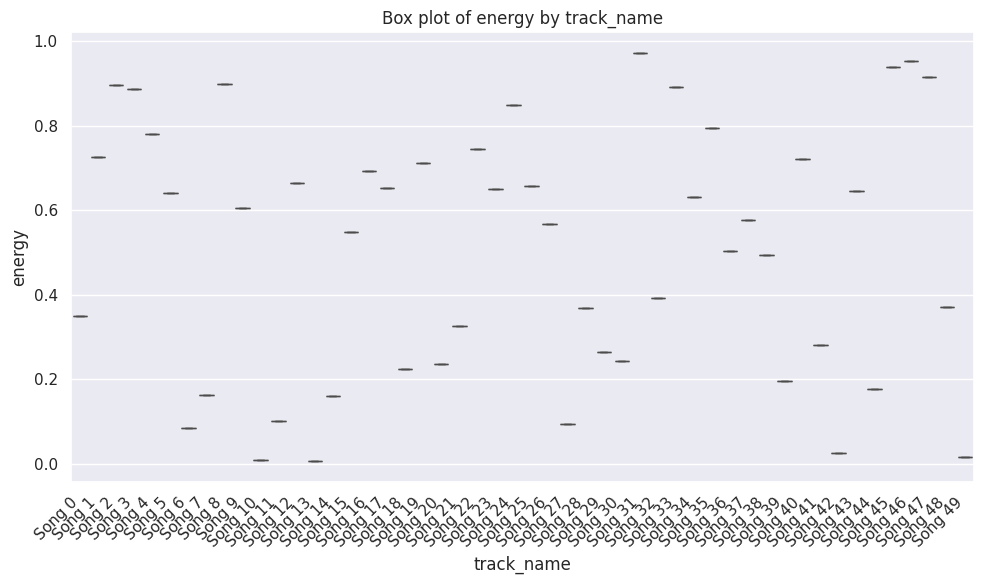

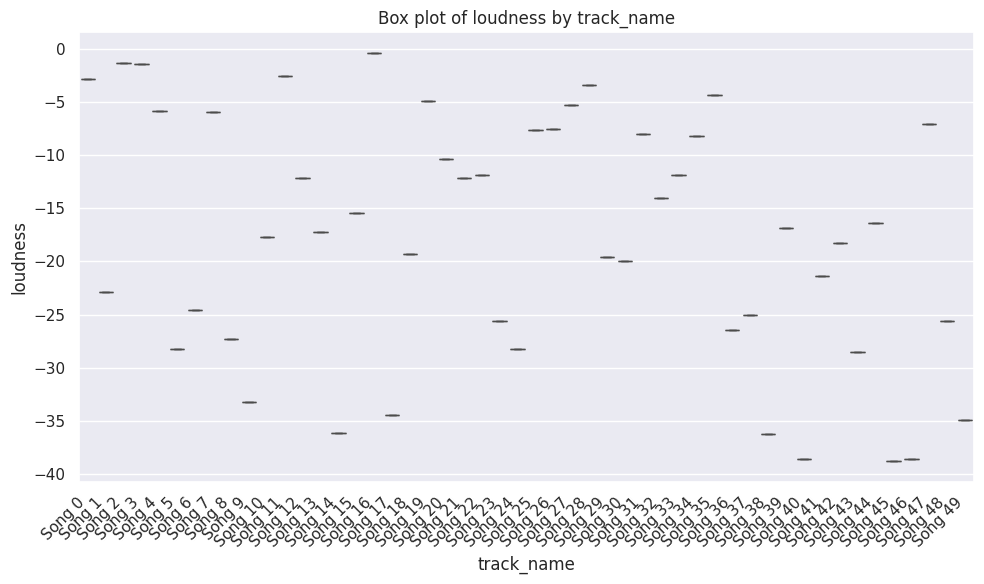

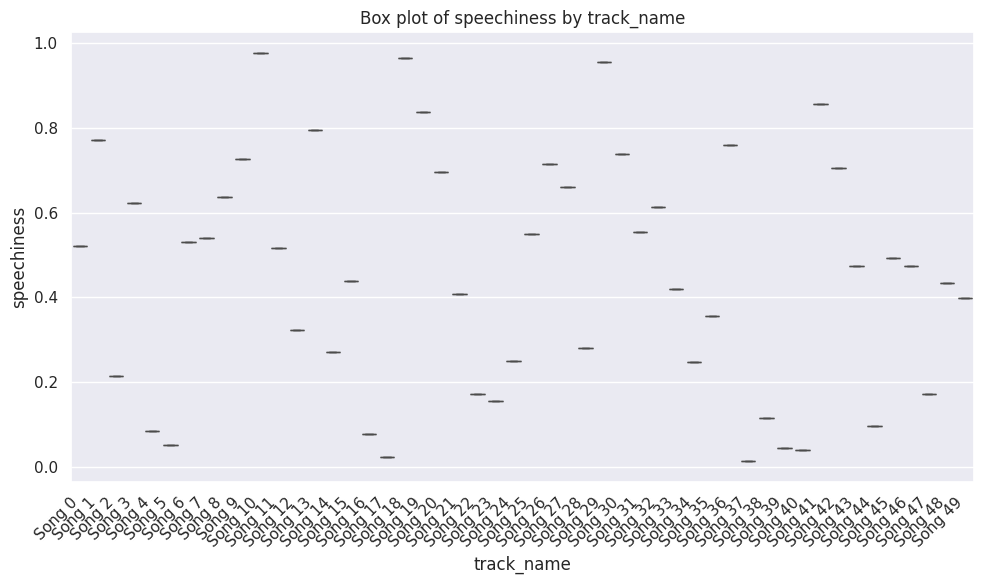

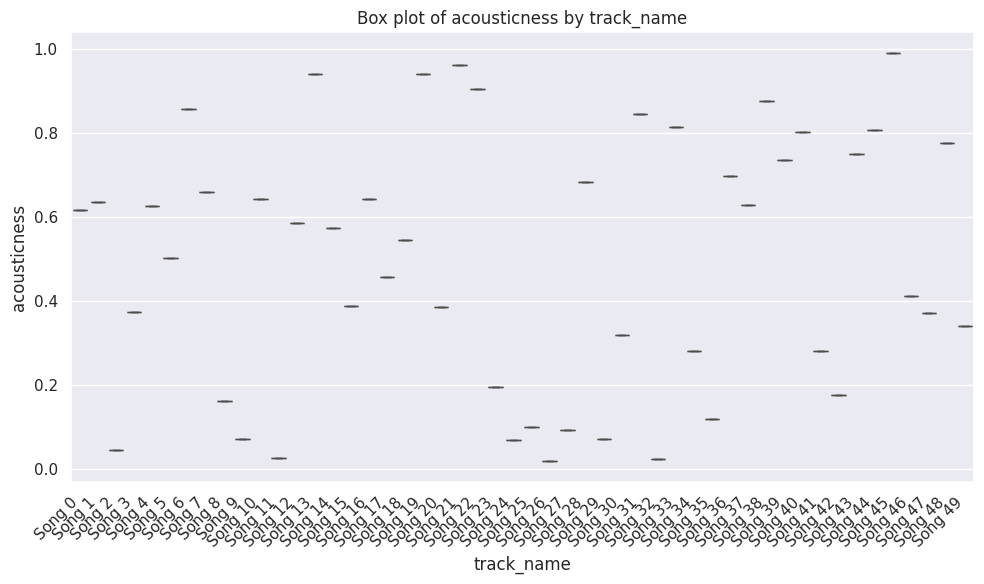

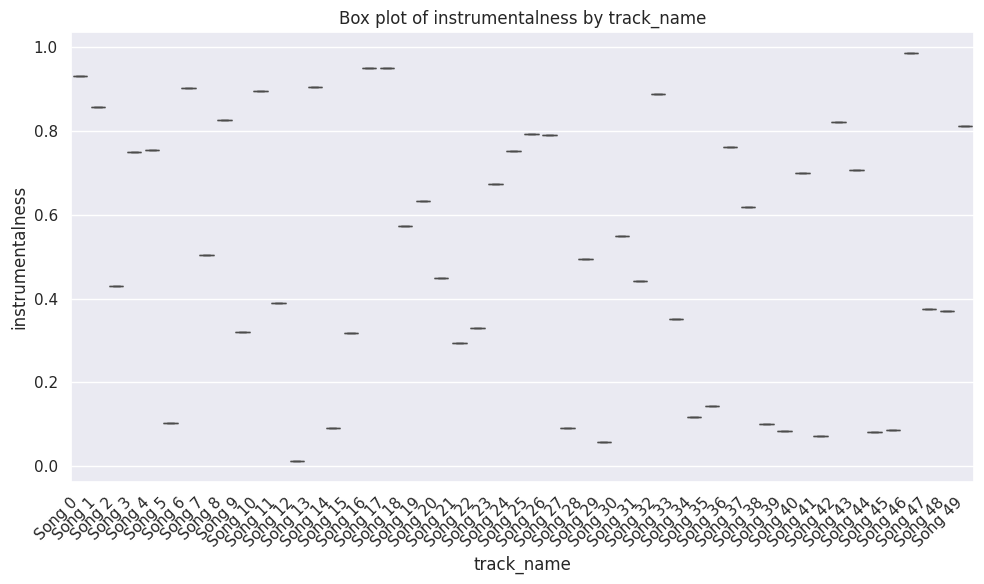

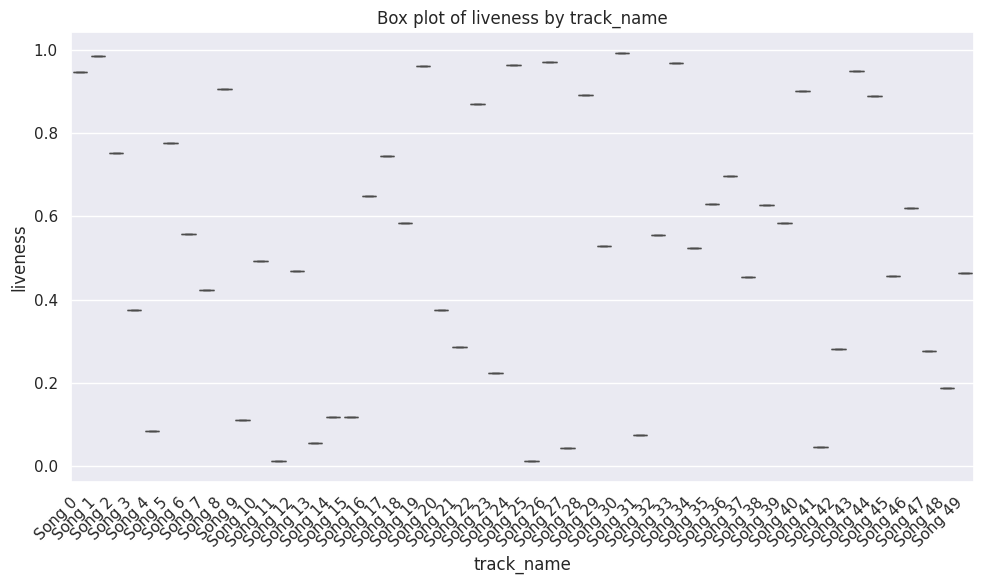

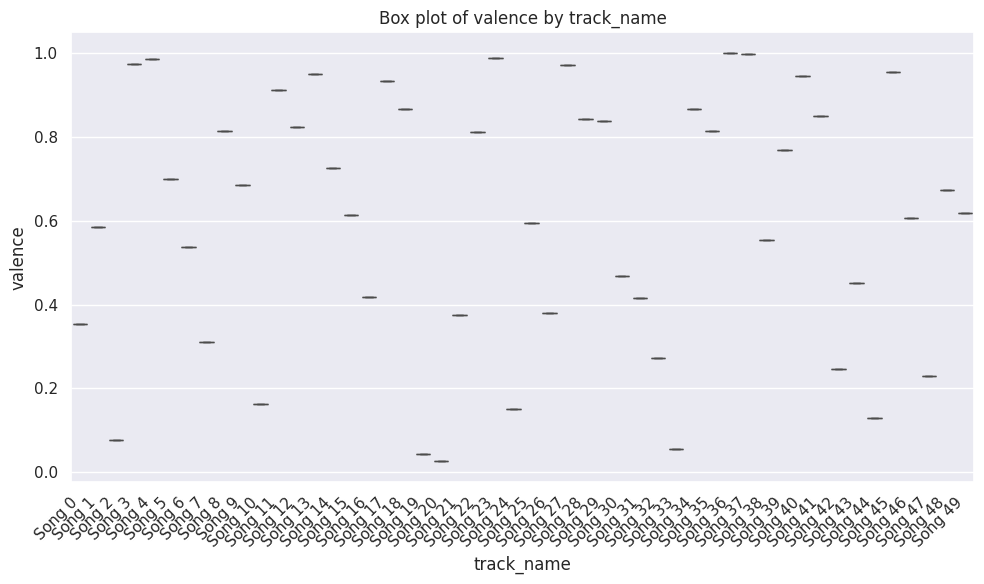

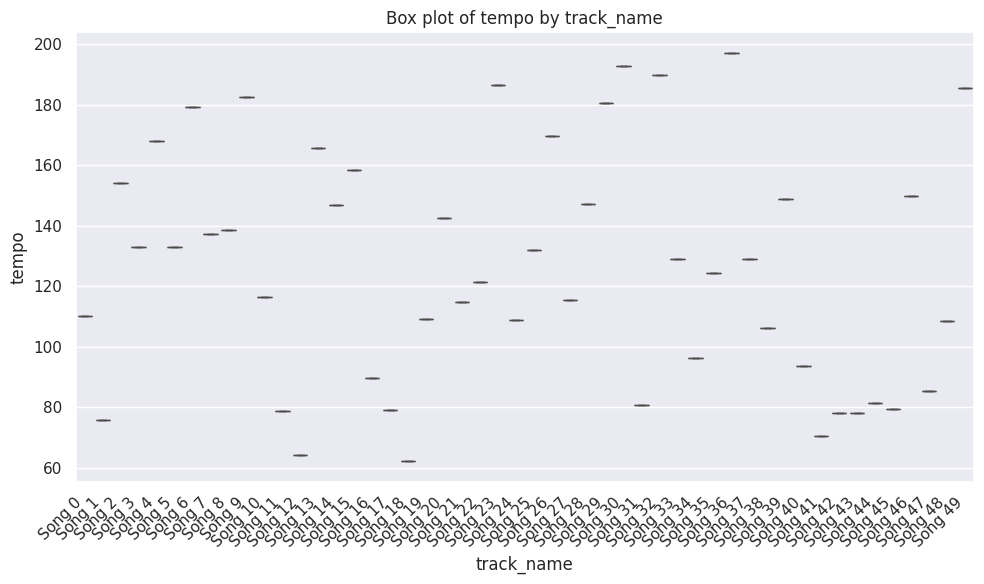

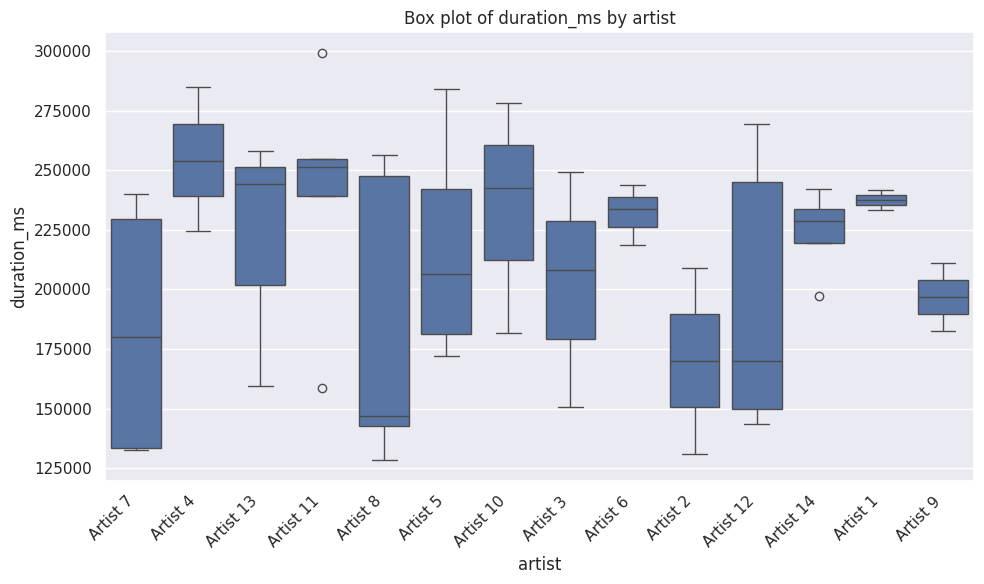

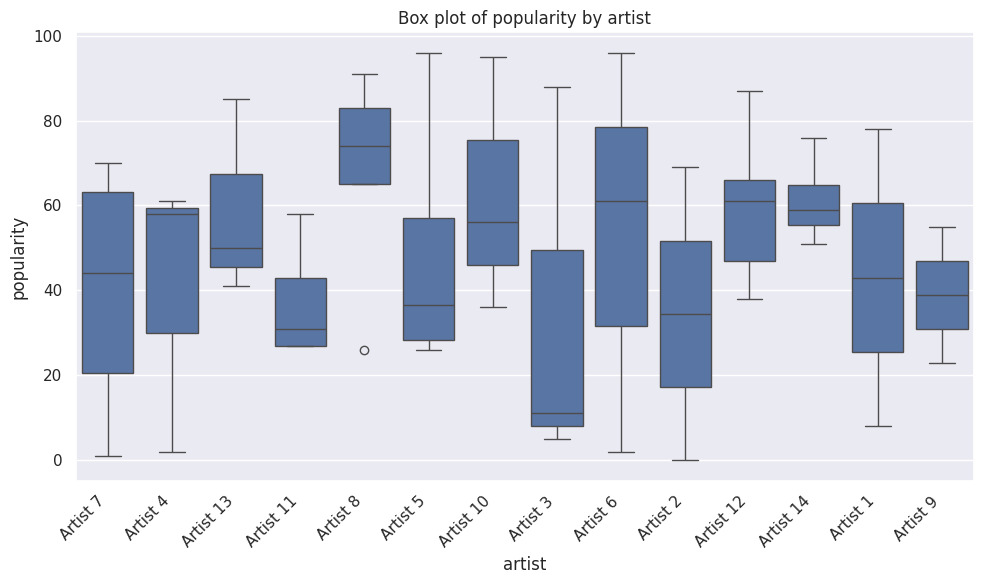

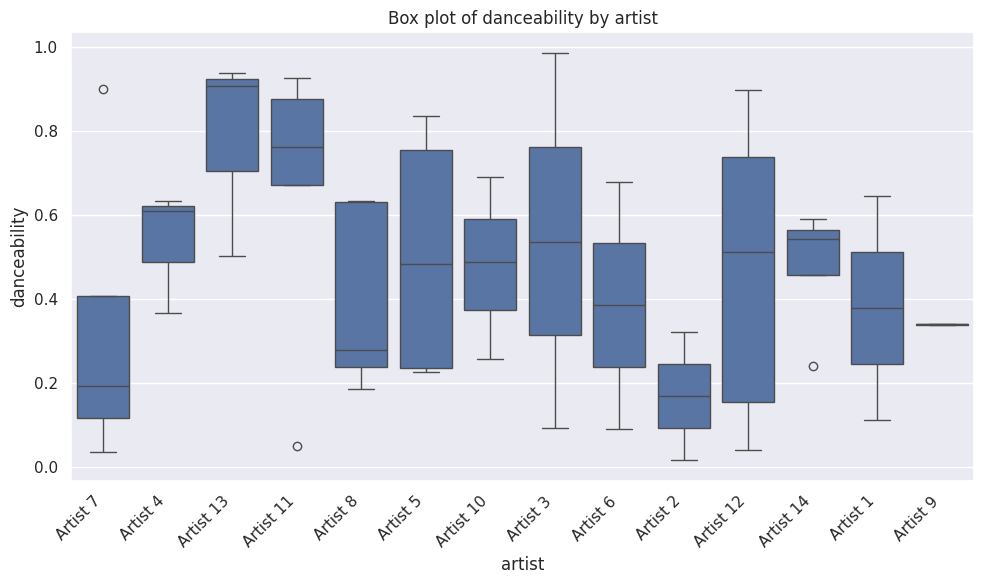

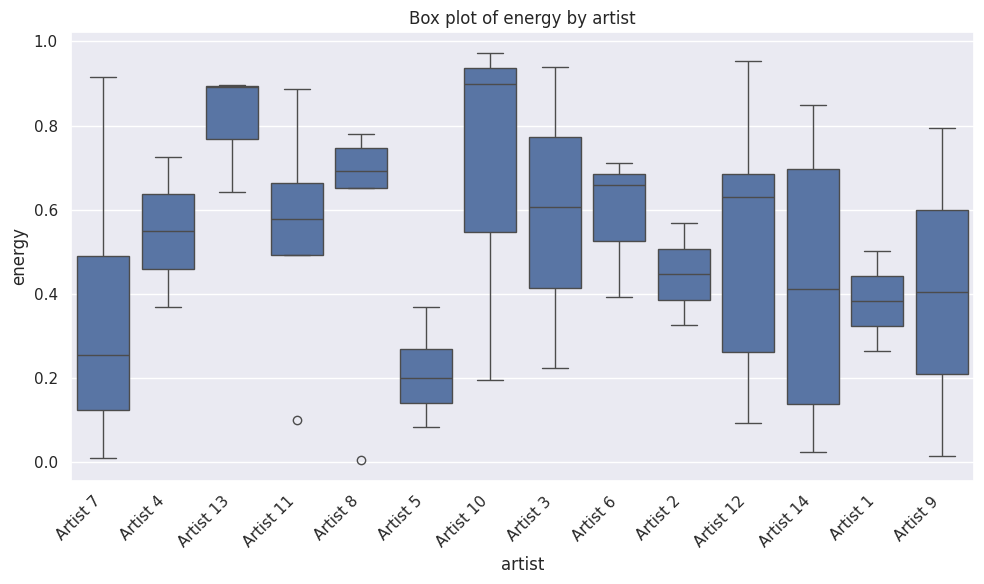

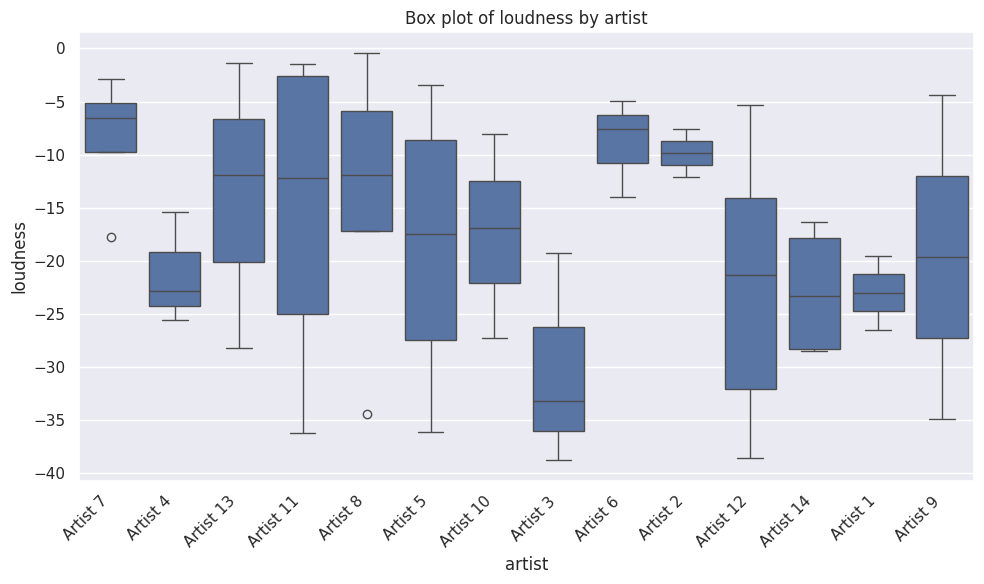

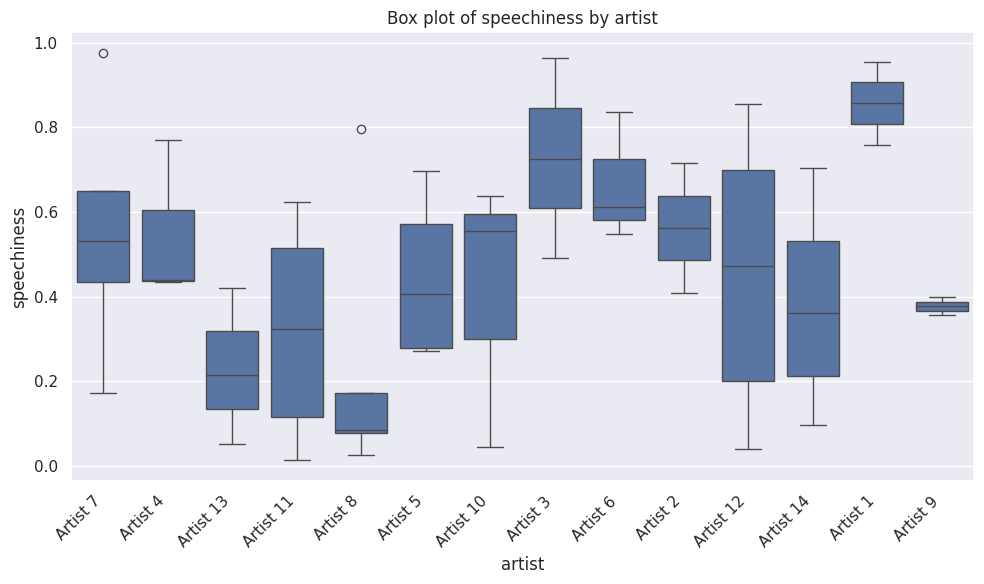

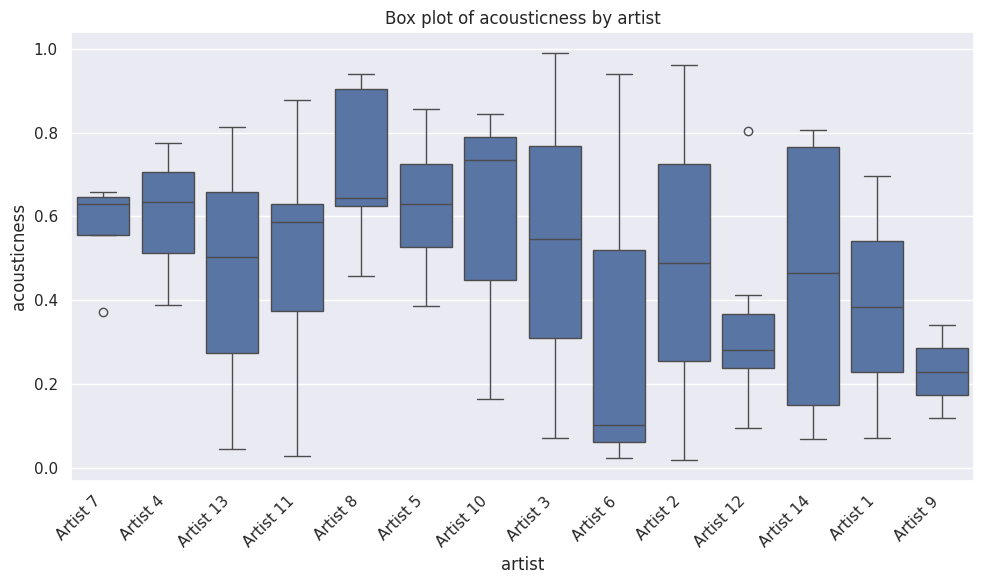

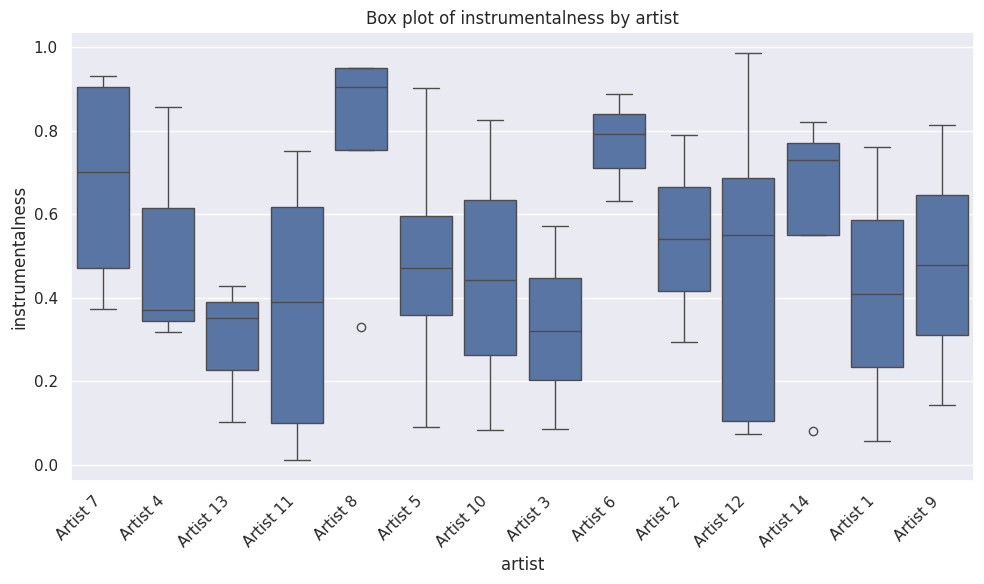

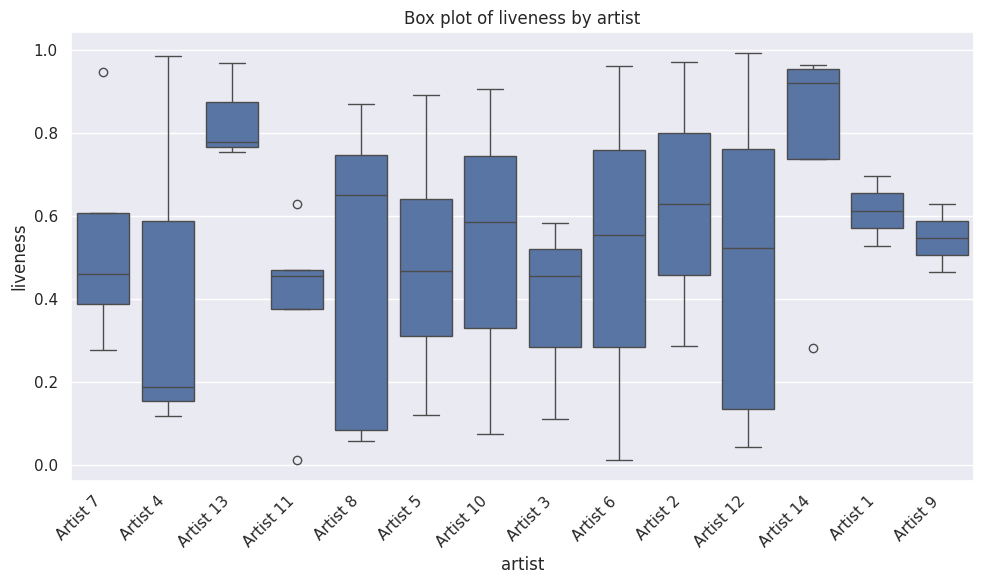

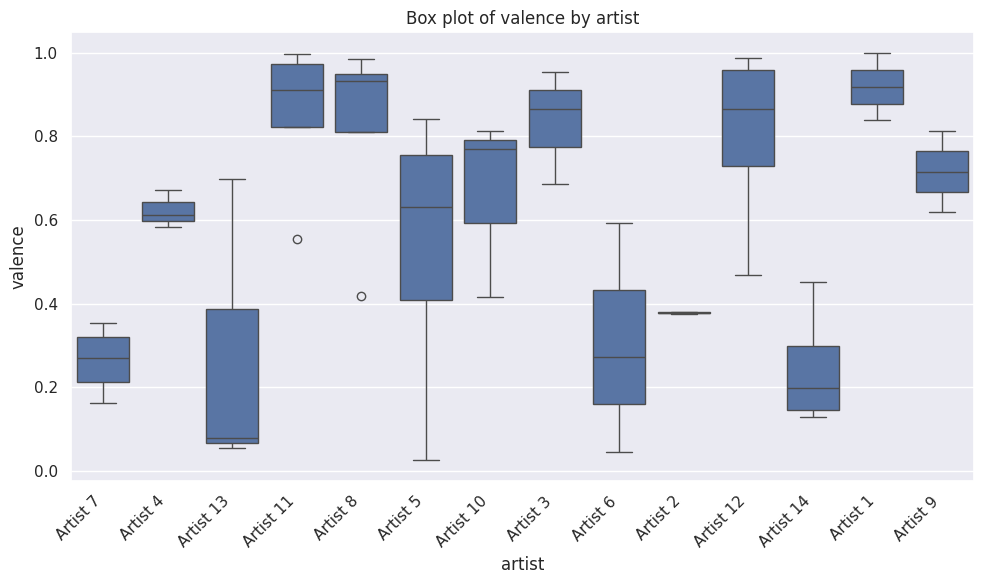

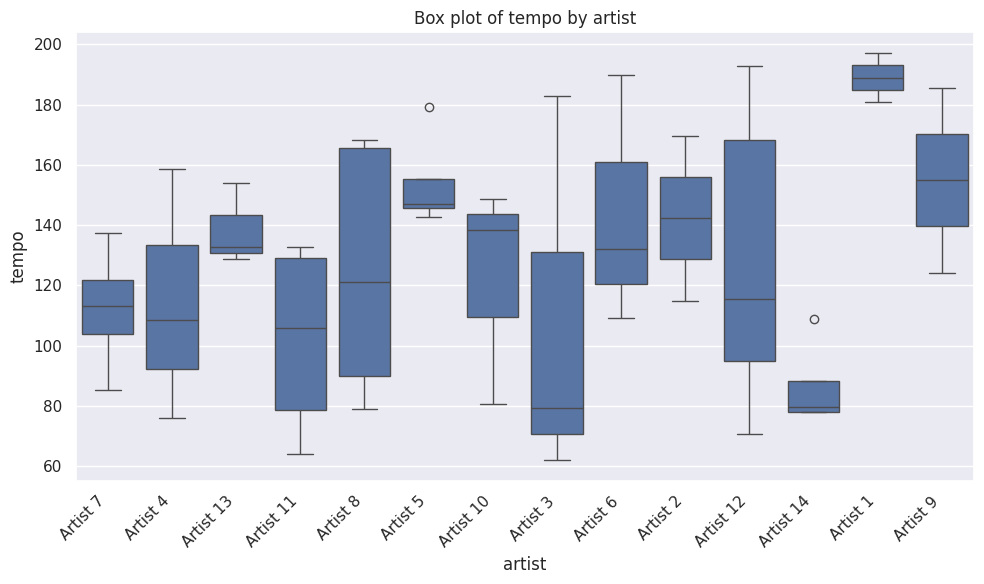

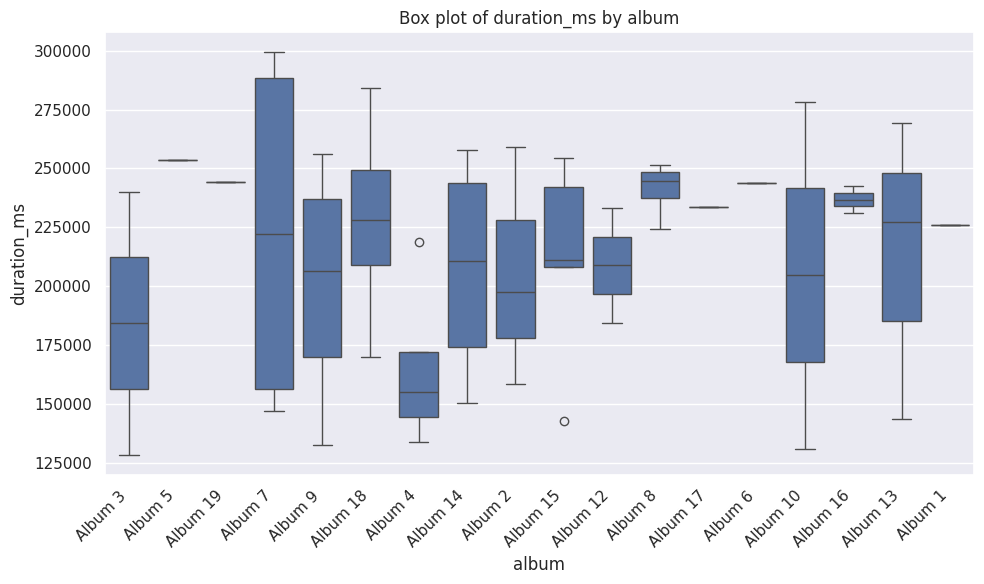

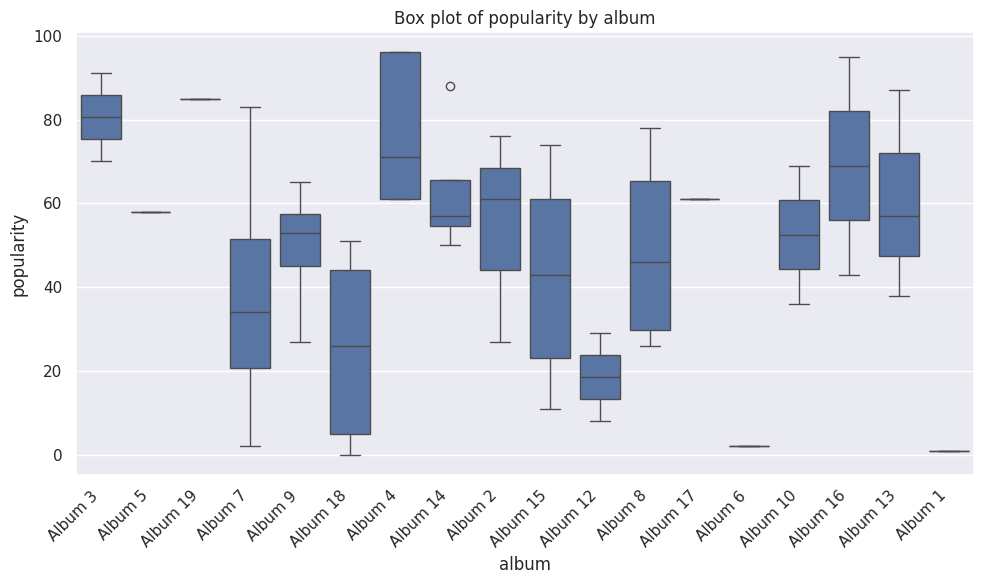

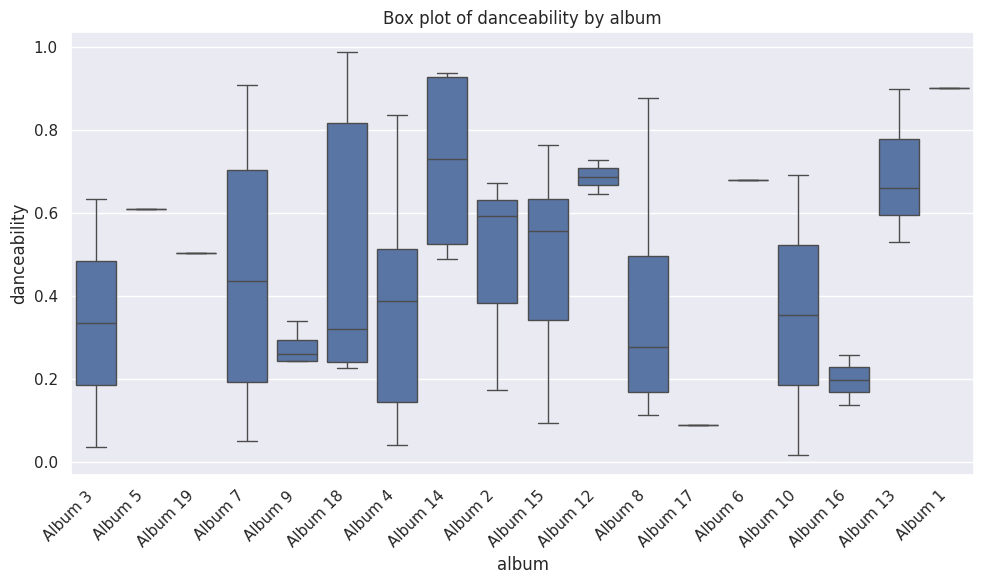

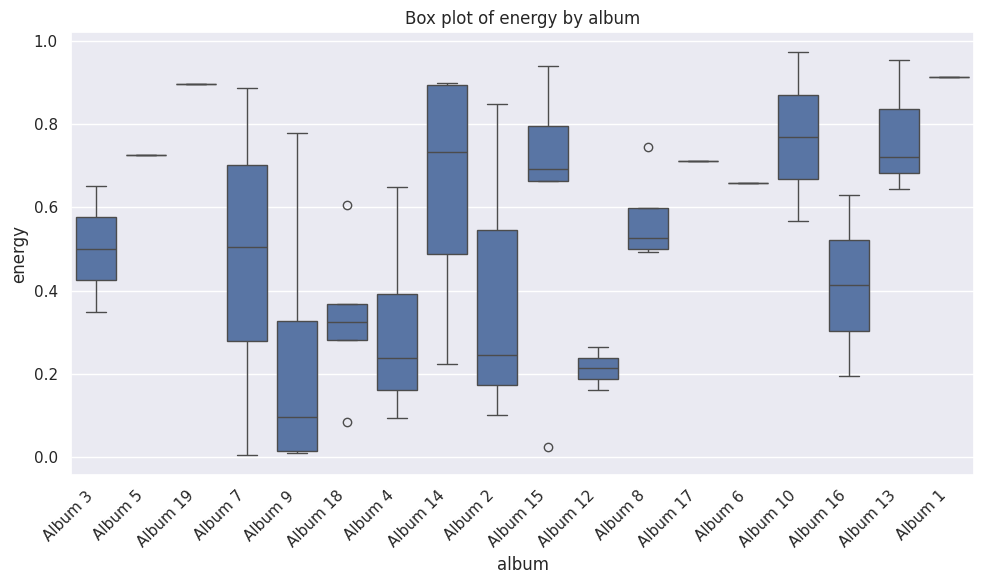

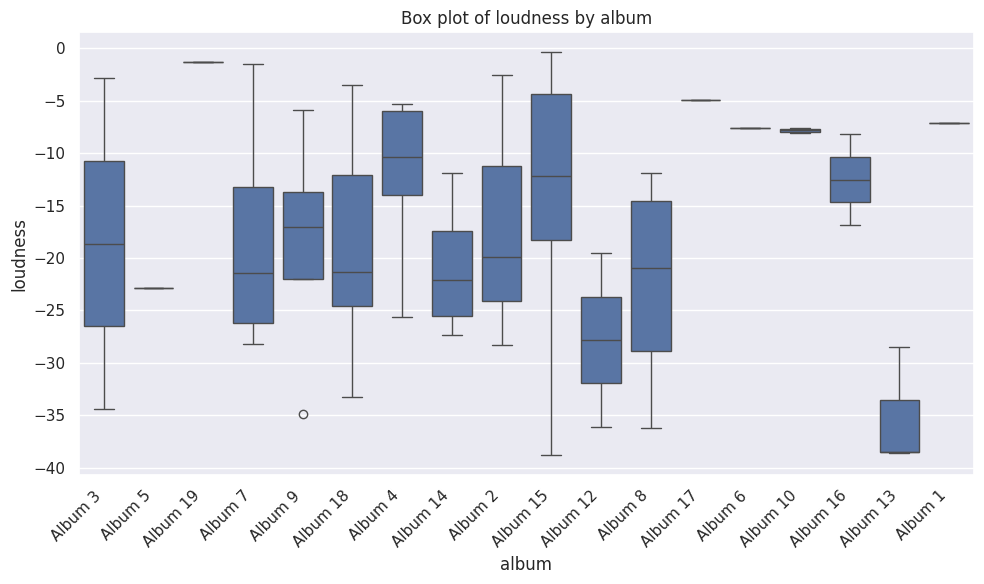

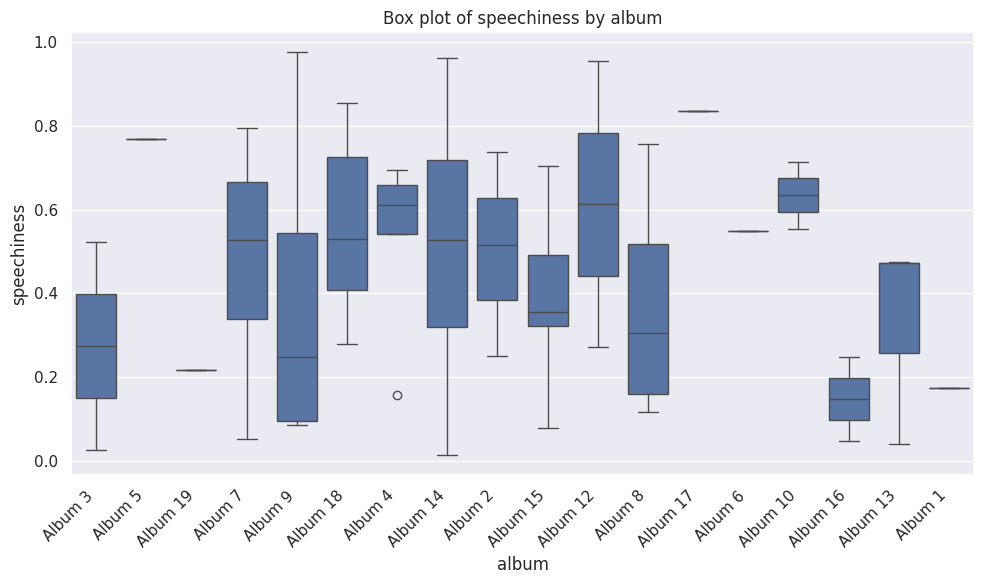

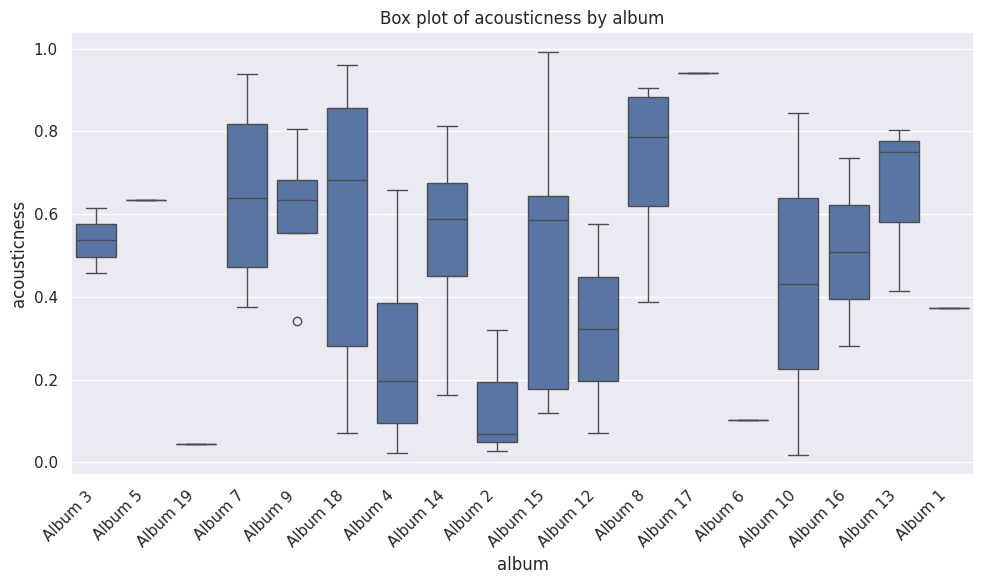

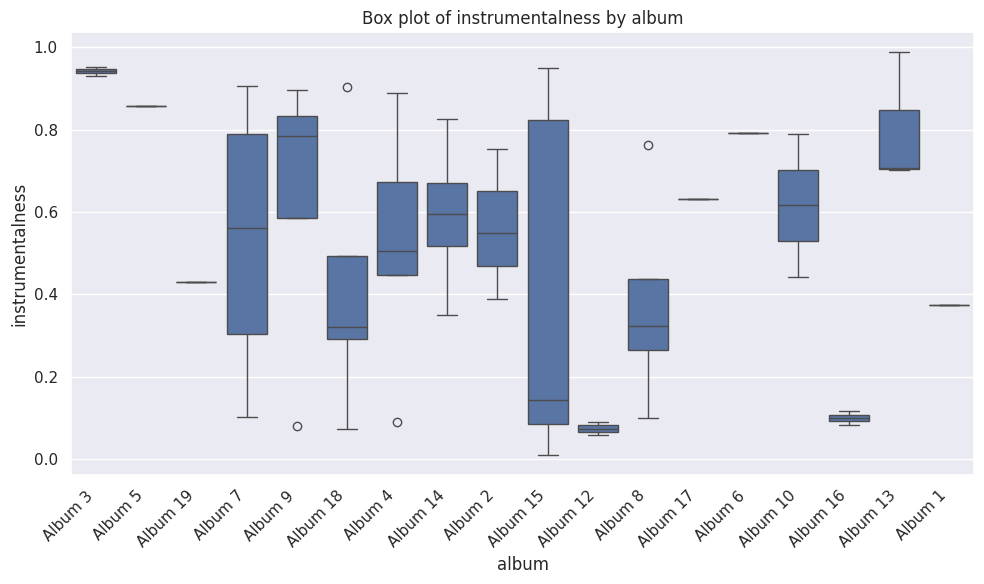

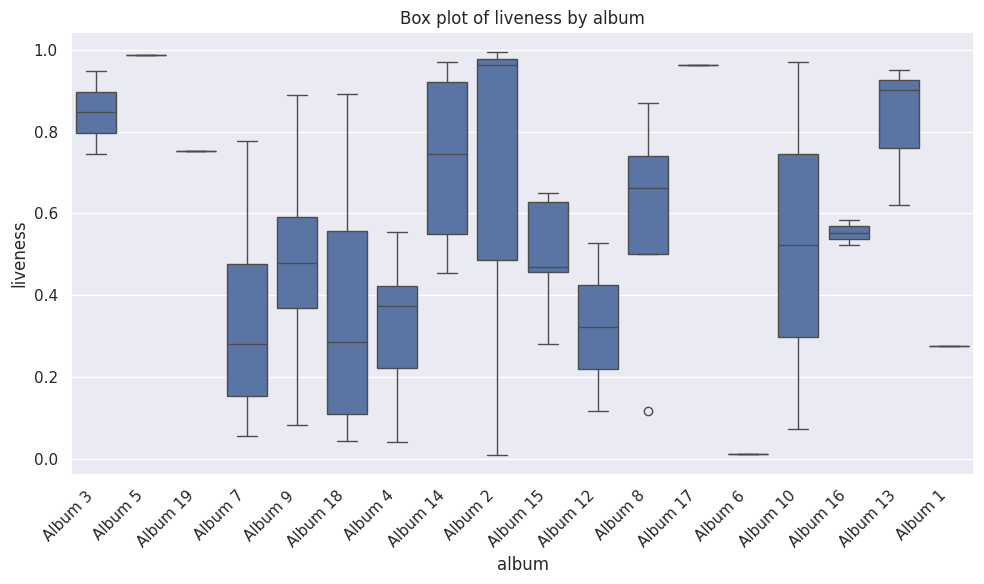

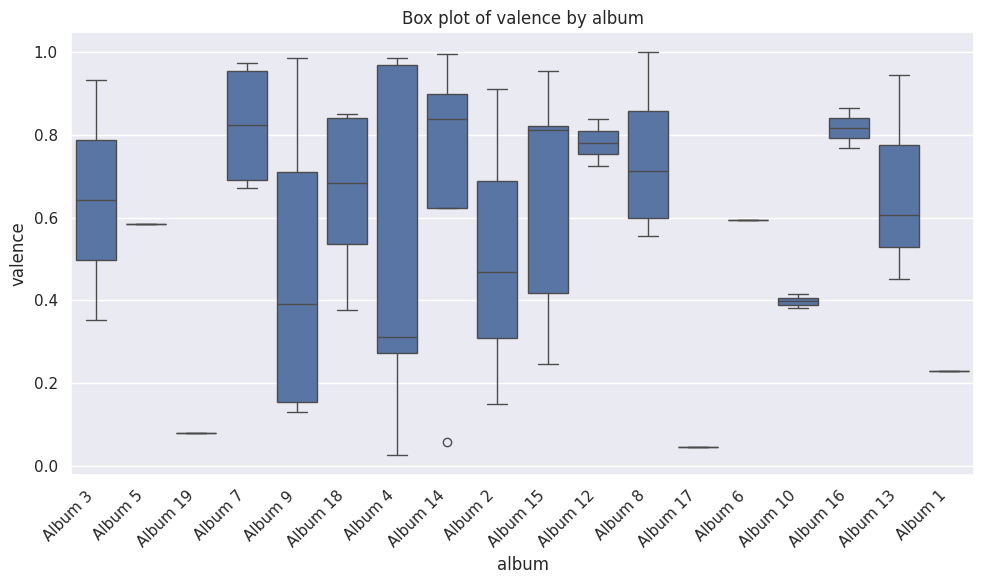

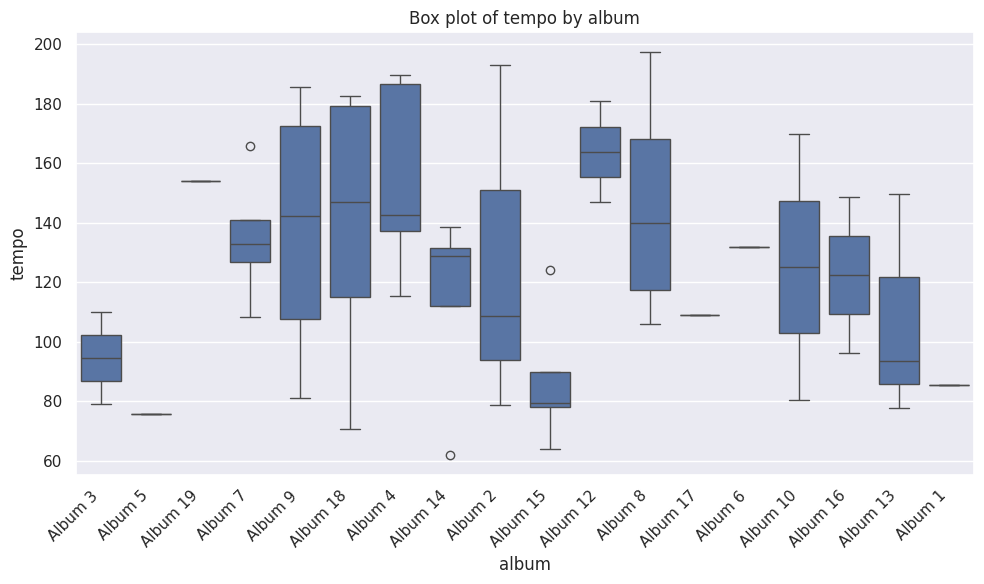

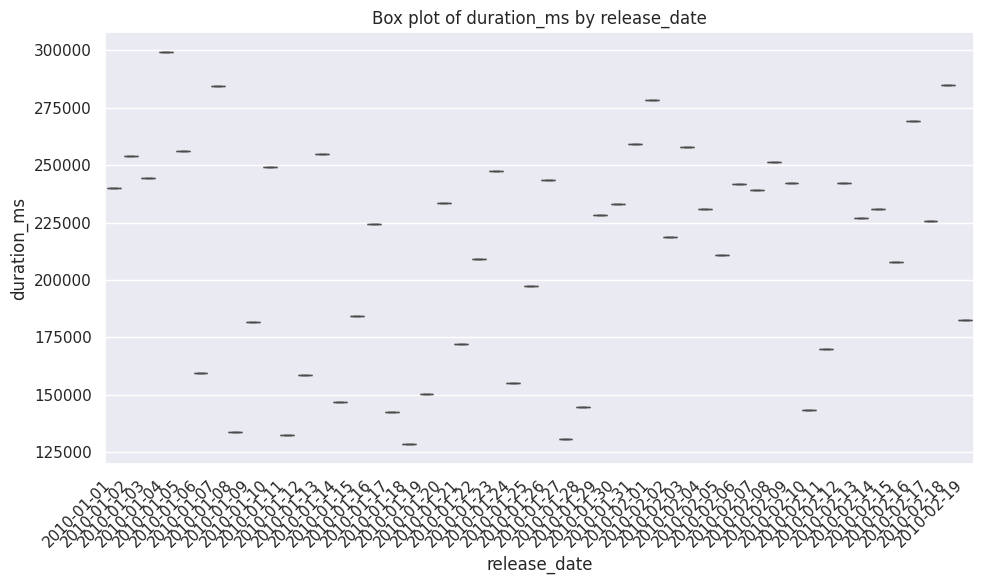

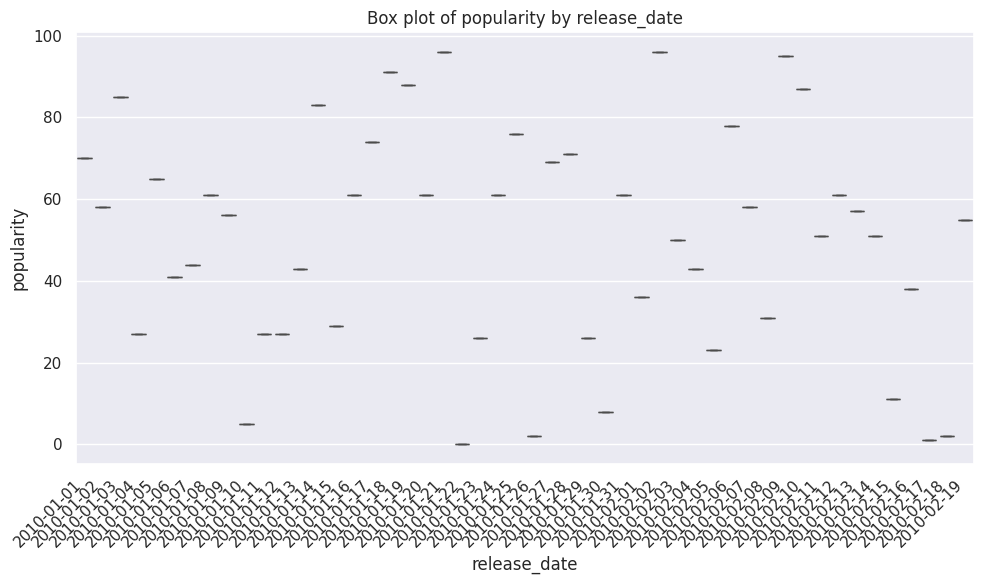

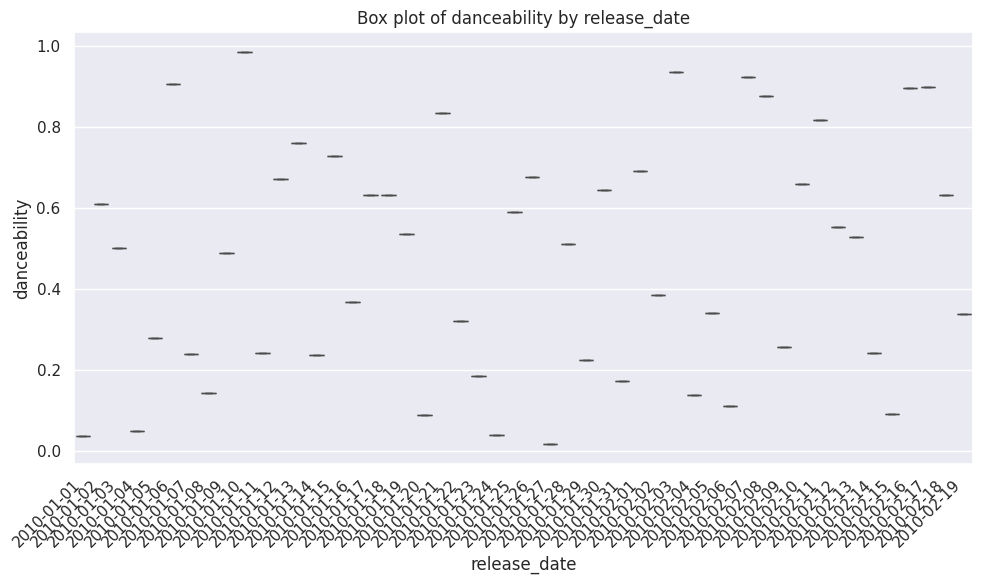

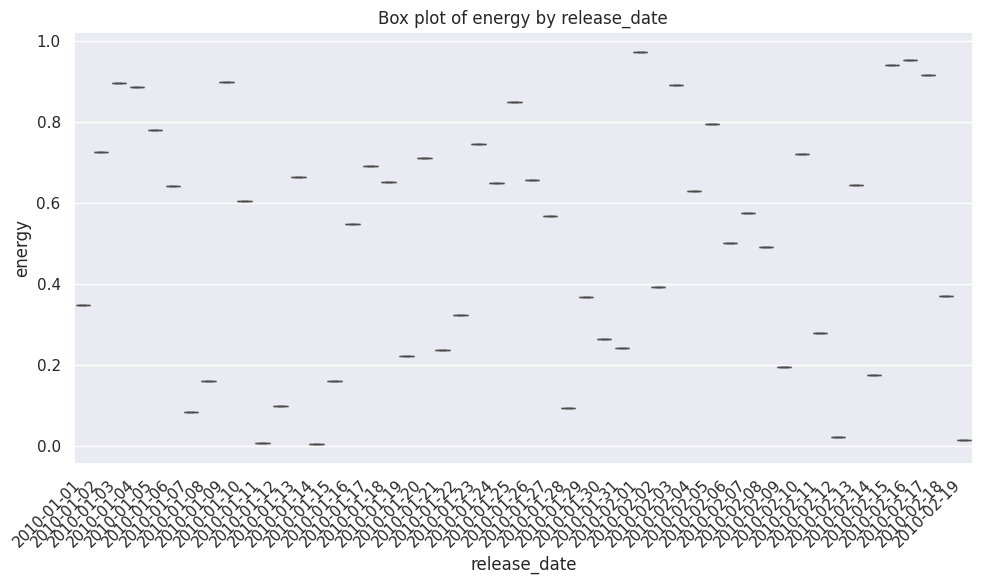

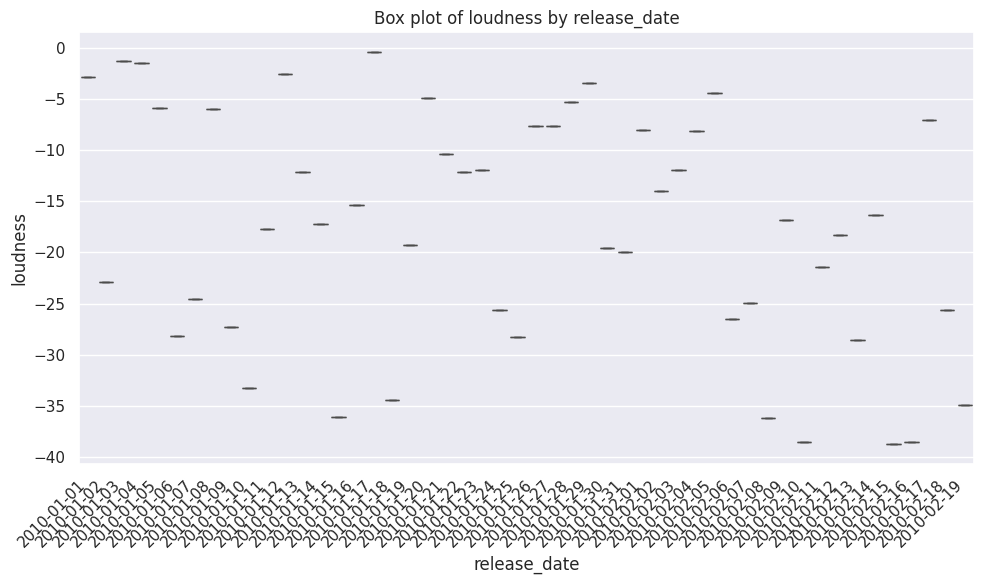

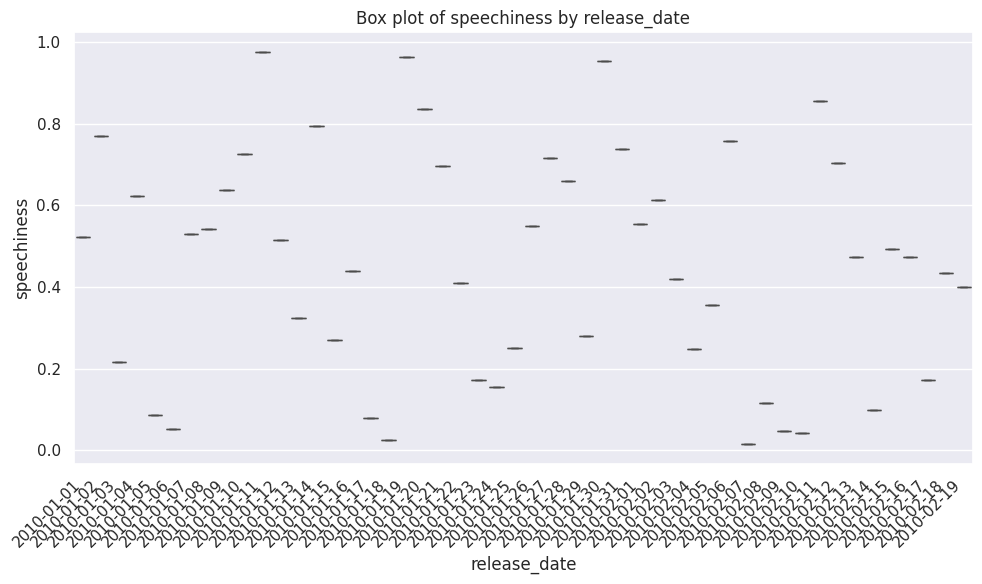

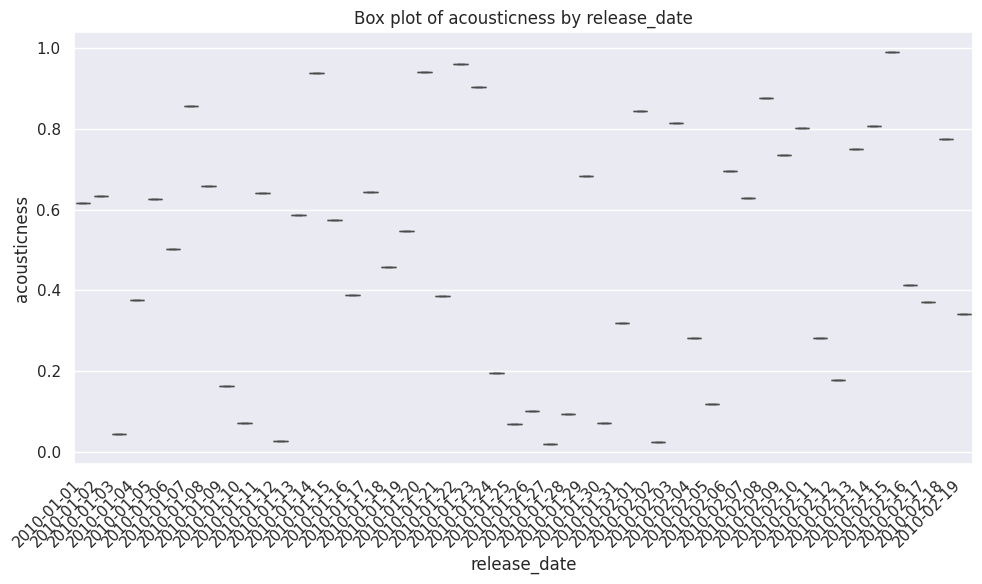

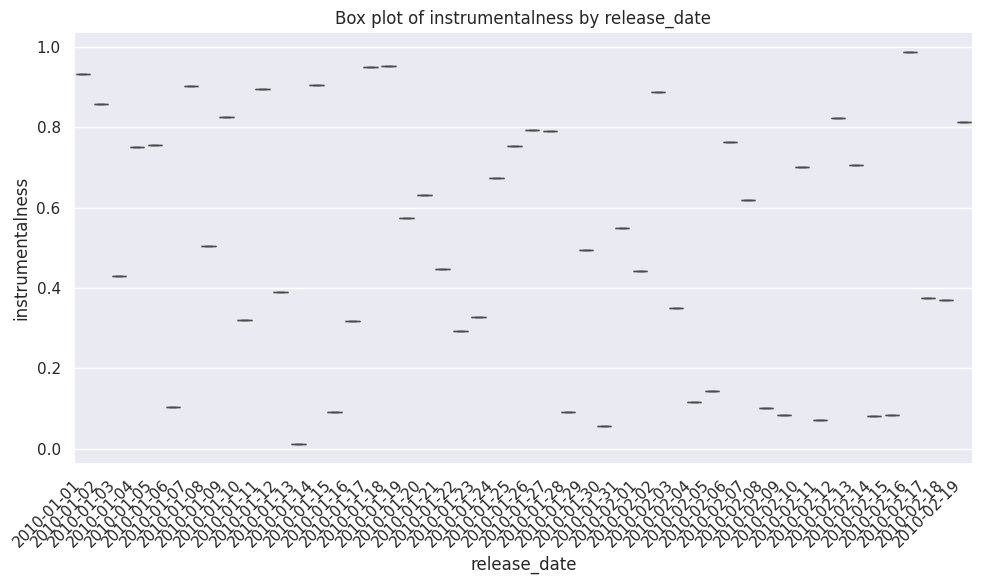

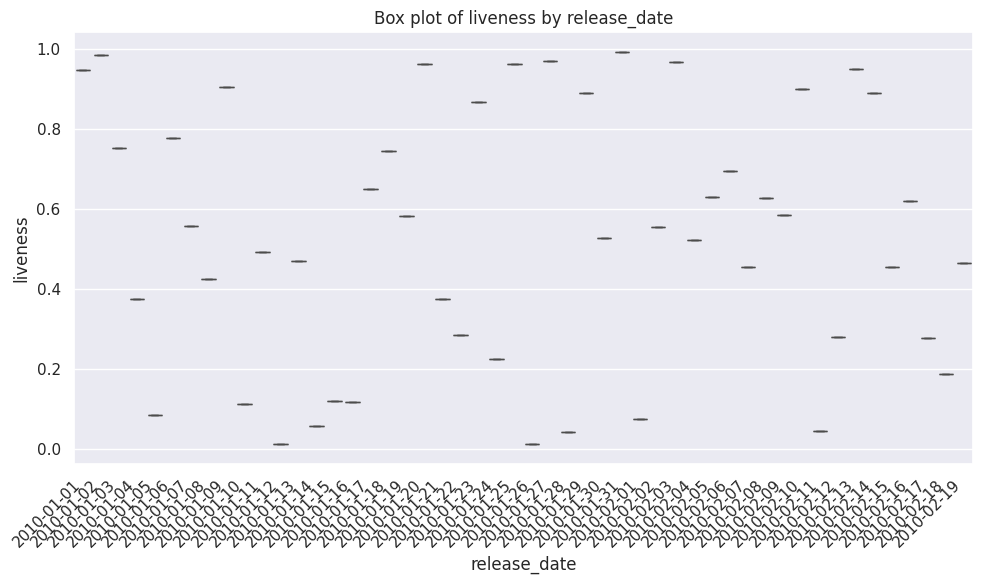

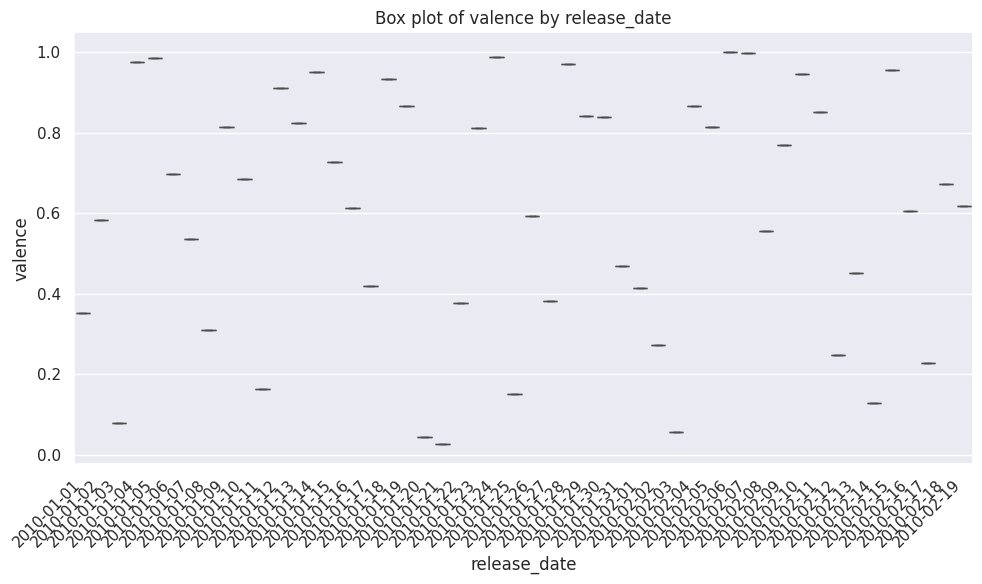

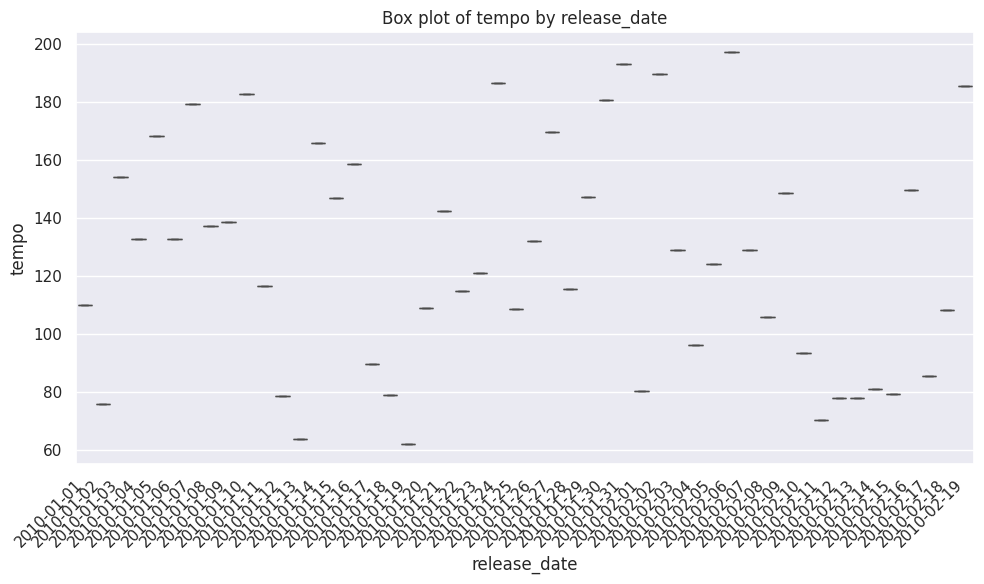

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

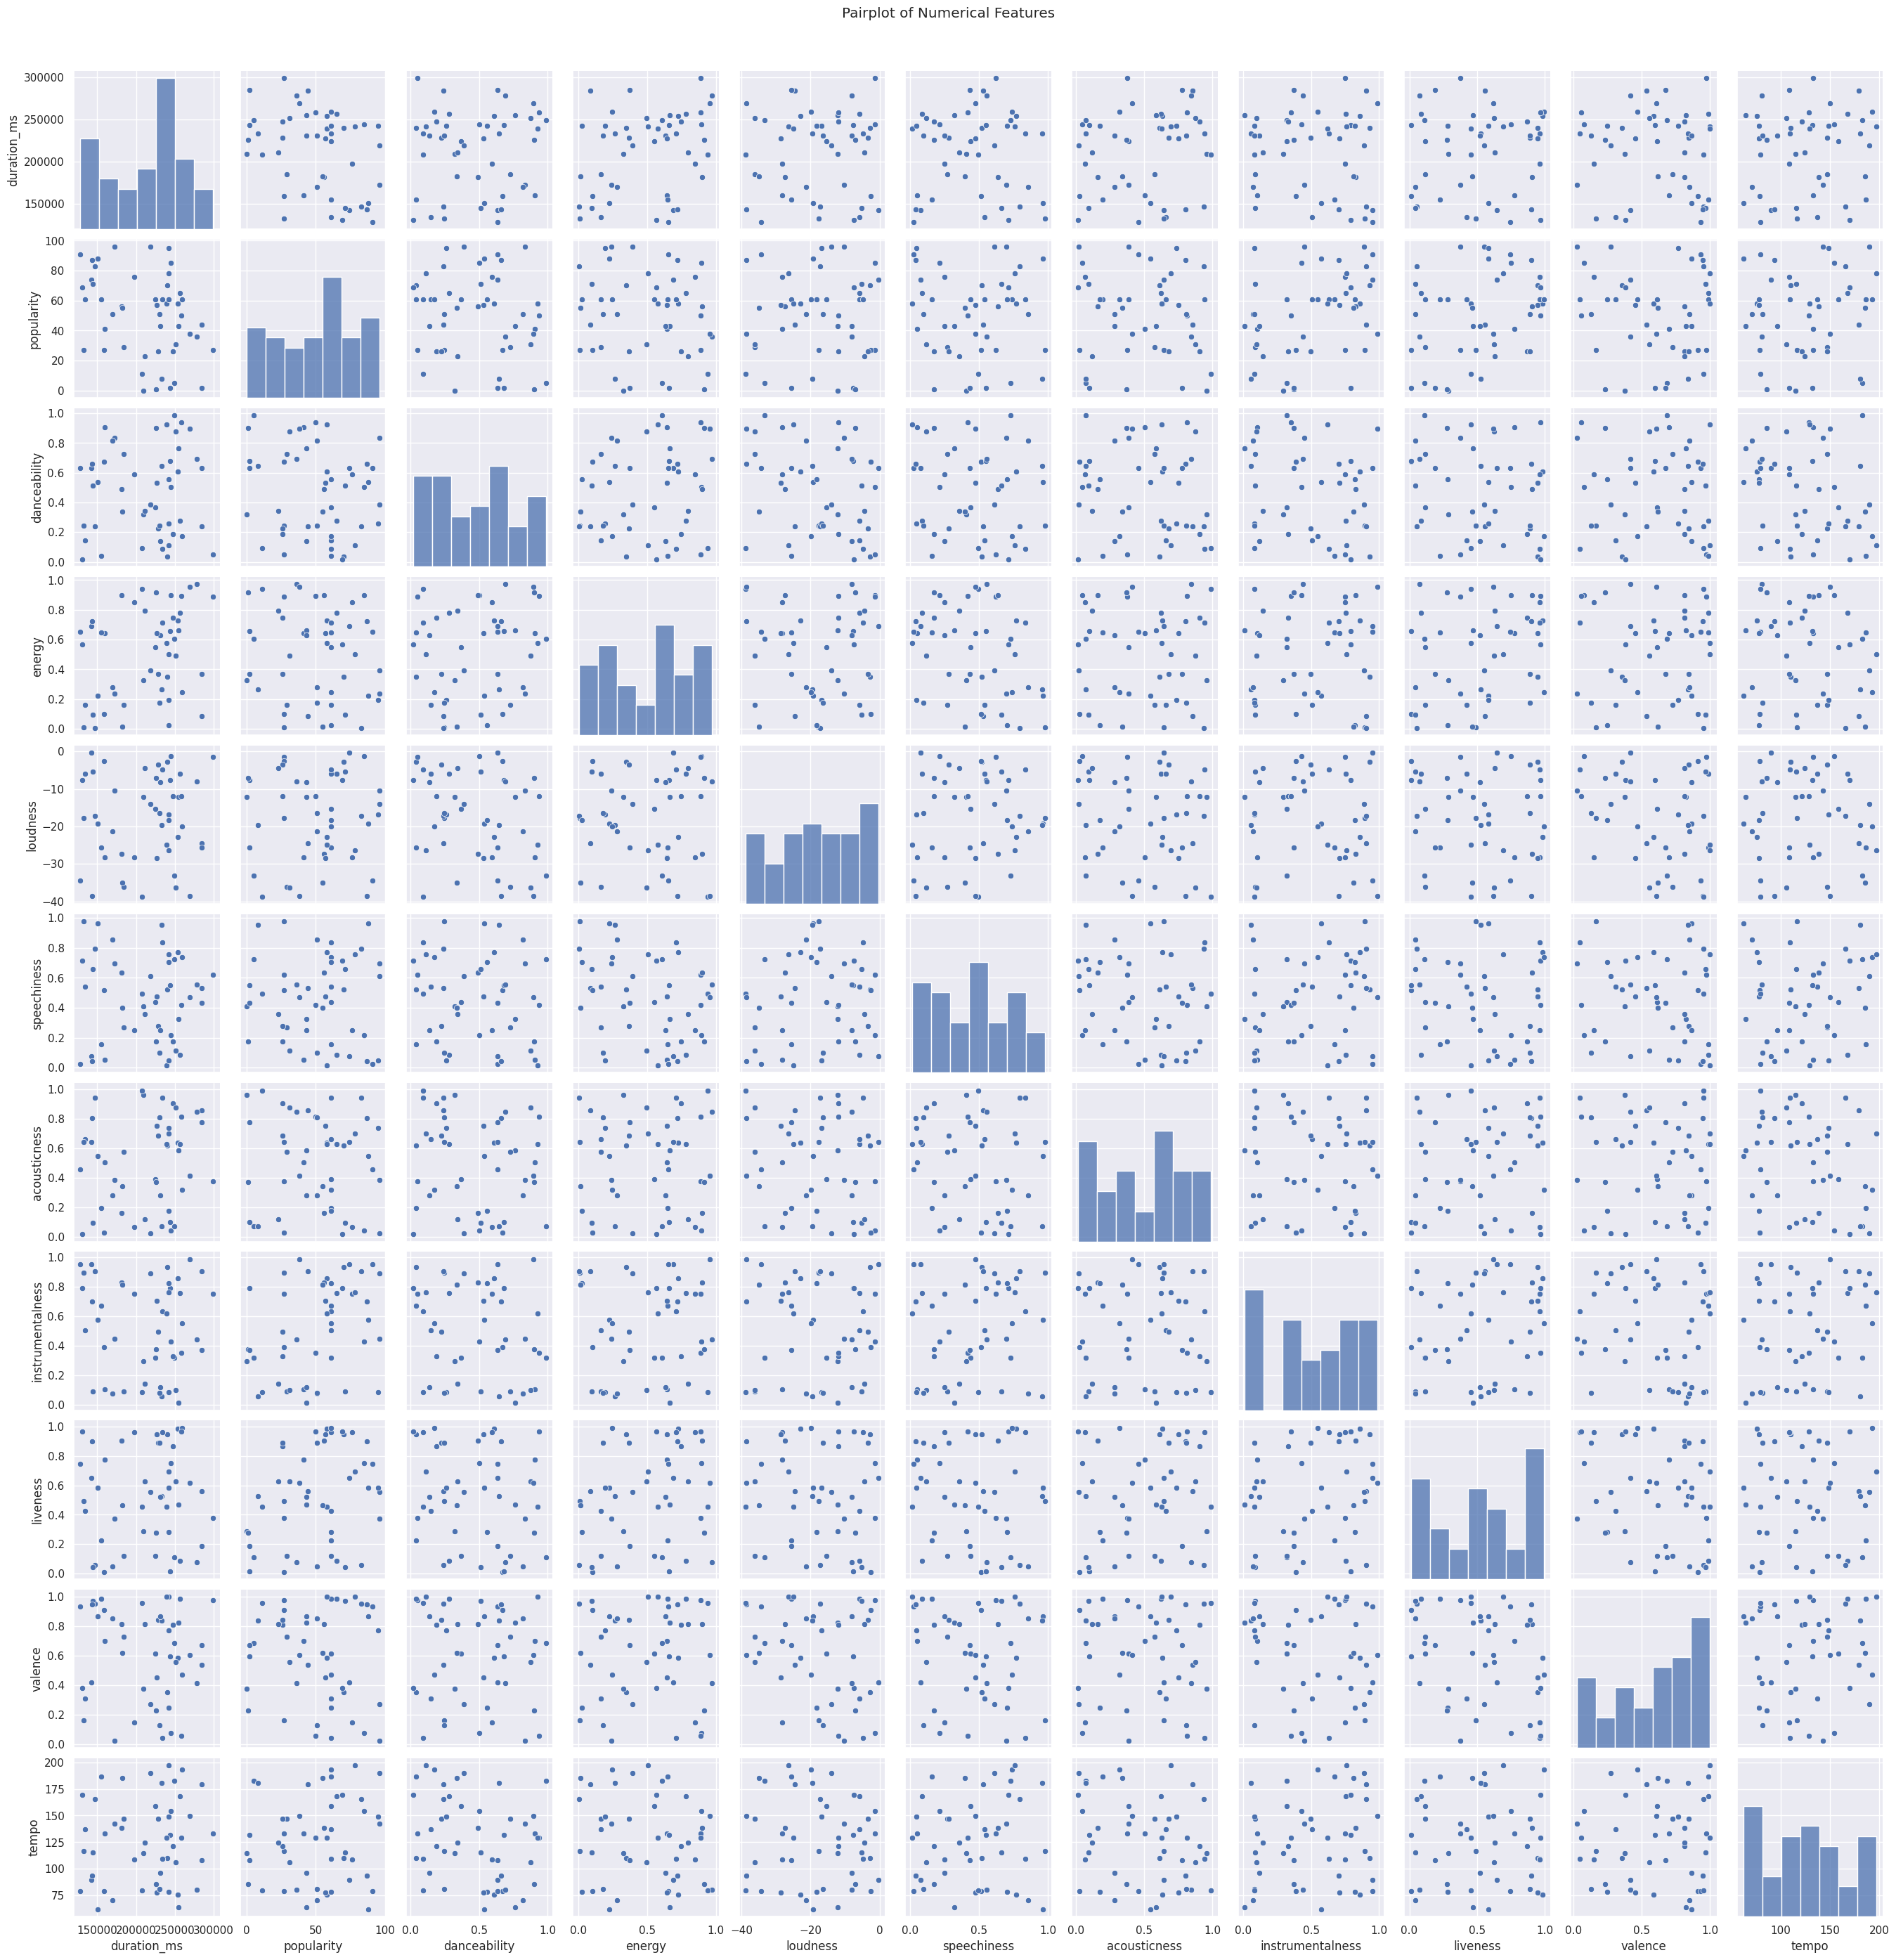

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

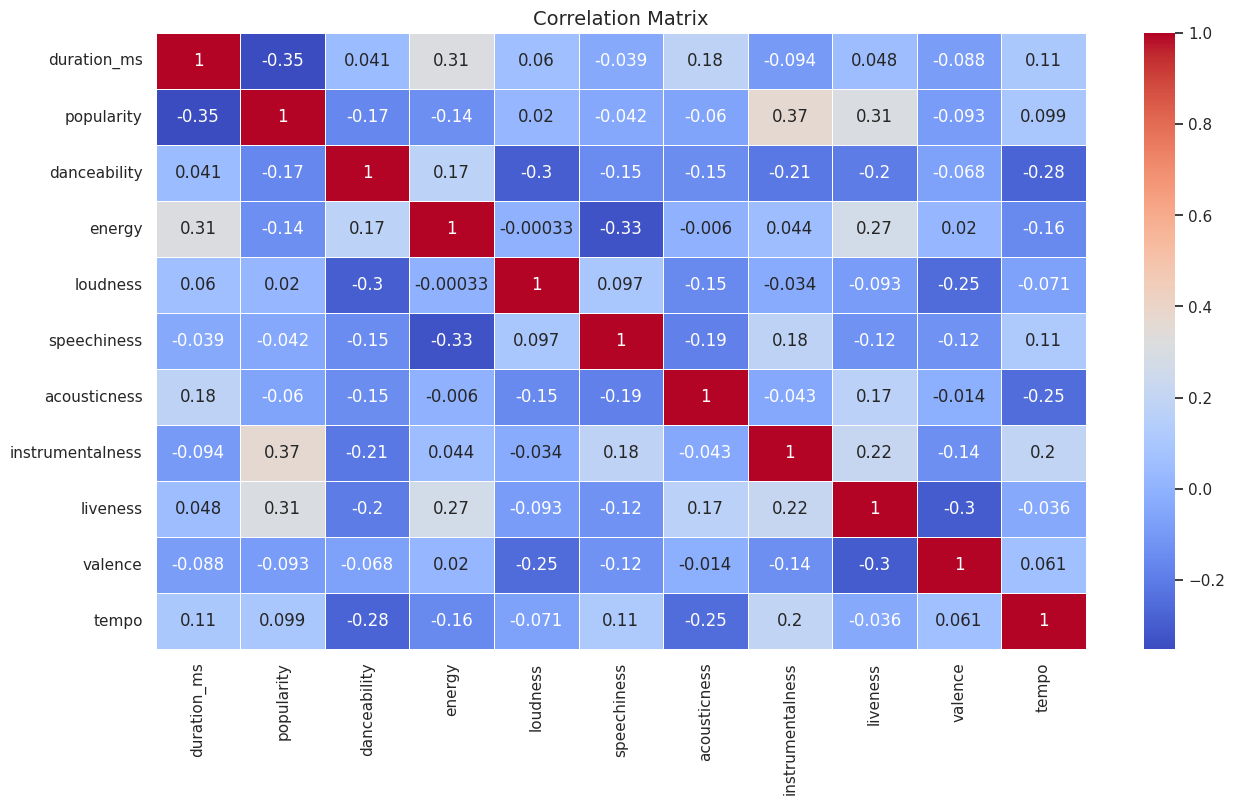

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You